# 0. Load Data

## 0.1 Load Data

In [ ]:
"""Load Data
Structure:
    1. Imports, Variables, Functions
    2. Load Data
"""

# 1. Imports, Variables, Functions
# imports
import pandas as pd, numpy as np, os, sys
import anndata as ad
import logging
from typing import *
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.metrics import confusion_matrix, classification_report
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
from src.utils import io 
logging.basicConfig(level=logging.INFO)

# variables
run_dir = os.path.join("..","..","outputs","run-25-09-13-18") 
embedding_type = "pt"
assert embedding_type in ["ft", "pt", "raw"]
if embedding_type == "ft":
    output_dir = os.path.join(run_dir, "outputs")
elif embedding_type == "pt":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")
elif embedding_type == "raw":
    run_name = run_dir.split("/")[-1]
    output_dir = os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "outputs")

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# functions

# 2. Load Data
(
    # split,
    predictions_test,
    labels_test,
    results_test,
    all_outputs_test,
    predictions_valid,
    labels_valid,
    results_valid,
    all_outputs_valid,
    predictions_train,
    labels_train,
    results_train,
    all_outputs_train,
    adata_orig,
    id2type,
    train_indices,
    valid_indices,
) = io.load_run_output(run_dir)

# load json

with open(os.path.join(run_dir, "parameters.json"), "r") as f:
    parameters = json.load(f)

for k, v in parameters.items():
    print(f"{k}: {v}")

Nº of loaded variables 16
data_path: /aloy/home/ddalton/projects/scGPT_playground/data/pp_data-25-09-12-01/data.h5ad
max_seq_len: 3501
batch_size: 16
gene_presence_pct: 0.9
benchmark_data: False
split_type: stratified
val_split_type: rand_stratified
n_splits: 10
n_tested_splits: 10
epochs: 50
gene_filtering: top_presence
sample_presence_pct: 0.3
MLM: False
CLS: False
CLS_multilabel: True
DAB: False
ADV: False
CCE: False
ecs_thres: 0.0
dab_weight: 0.0
use_fast_transformer: True
output_attentions: False
INPUT_BATCH_LABELS: False
do_combat: False
ontology: do
scgpt_pp: norm_log1p
description: no control loss
library: RNA-Seq
use_controls: True


In [2]:
import importlib

importlib.reload(ut)
importlib.reload(vz)

split_idx = 0

# load all adata
adata_test =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_test_{split_idx+1}.h5ad"), backed="r"
)
adata_test.obs.reset_index(drop=True, inplace=True)  
adata_valid =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_valid_{split_idx+1}.h5ad"), backed="r"
)
adata_valid.obs.reset_index(drop=True, inplace=True)  
adata_train =  ad.read_h5ad(
    os.path.join(run_dir, f"adata_train_{split_idx+1}.h5ad"), backed="r"
)
adata_train.obs.reset_index(drop=True, inplace=True)  

## 0.2 Load DO Pairs

In [3]:
"""0.2 Load Disease Ontology Pairs
Load pairs of related and unrelated diseases from the Disease Ontology.
Structure:
    1. Imports, Variables, Functions
    2. Load Disease Pairs

"""
# 1. Imports, Variables, Functions
# imports


# variables

# functions


# 2. Load Disease Pairs

# Get disease IDs
d_ids = list(adata_train.obs["doid_id"].unique())

# load Disease Ontology Lin Similarity amongst pairs!
do_df_ic = ut.load_df_do_pairs()
print(f"Loaded universe of disease pairs: {do_df_ic.shape[0]}") 

# Load IC based similarity 
do_graph = ut.load_do_graph()
doid_to_term = {
    node: data["name"] for node, data in do_graph.nodes(data=True) if "name" in data
}


# get top 1% & 5% of values
ic_thr = np.quantile(do_df_ic["lin"].values, 0.95)
print(f"IC Threshold: {ic_thr:.3f}\tNº of pairss {len(do_df_ic.query('lin>@ic_thr'))}")

ic_thr_99 = np.quantile(do_df_ic["lin"].values, 0.99)
print(f"IC Threshold 99%: {ic_thr_99:.3f}\tNº of pairs {len(do_df_ic.query('lin>@ic_thr_99'))}")



Loaded universe of disease pairs: 70442515
IC Threshold: 0.396	Nº of pairss 3518554
IC Threshold 99%: 0.543	Nº of pairs 704215


In [4]:

# Filter pairs
do_df_ic_query = do_df_ic.query("do1 in @d_ids and do2 in @d_ids")
print("Nº of pairs in dataset:", do_df_ic_query.shape)

do_df_ic_query = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr}")
print("Nº of significant pairs in dataset (top 5% IC):", do_df_ic_query.shape)

do_df_ic_query_99 = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin > {ic_thr_99}")
print("Nº of significant pairs in dataset (top 1% IC):", do_df_ic_query_99.shape)

do_df_negative_ic = do_df_ic.query(f"do1 in @d_ids and do2 in @d_ids and lin <= {ic_thr}")
print("Nº of negative pairs in dataset (outside 5%):", do_df_negative_ic.shape)

Nº of pairs in dataset: (7503, 8)
Nº of significant pairs in dataset (top 5% IC): (917, 8)
Nº of significant pairs in dataset (top 1% IC): (354, 8)
Nº of negative pairs in dataset (outside 5%): (6586, 8)


## Quality Control

In [5]:
epoch_loss = pickle.load(open(os.path.join(run_dir, "metrics_epochs.pkl"), "rb"))

In [6]:
epoch_loss.keys()

dict_keys(['split_1'])

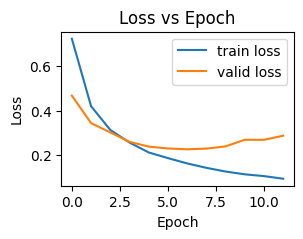

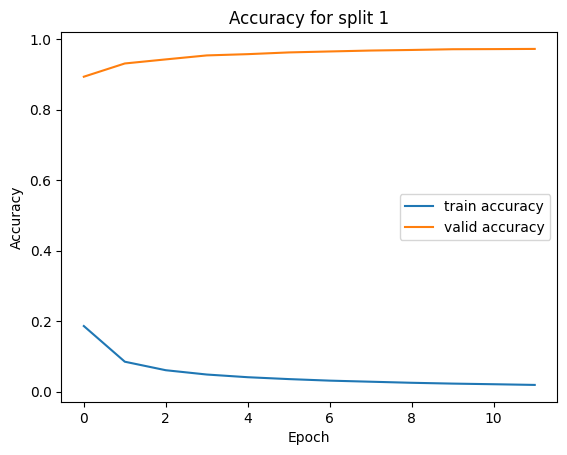

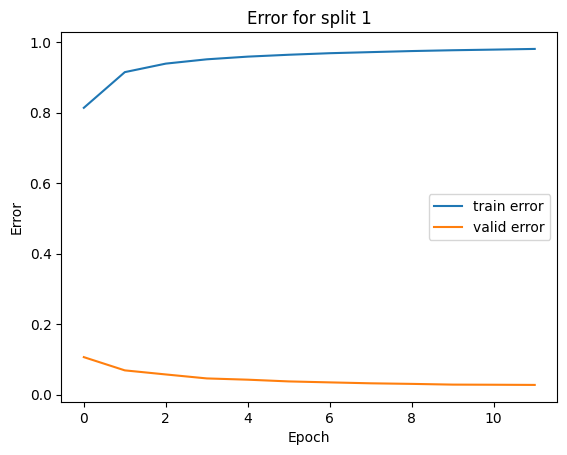

In [7]:
def plot_loss(epoch_loss: dict, split: int = 2):
    plt.figure(figsize=(3, 2))
    t_loss = epoch_loss[f"split_{split}"]["train_loss"]
    v_loss = epoch_loss[f"split_{split}"]["valid_loss"]
    plt.plot(t_loss, label="train loss")
    plt.plot(v_loss, label="valid loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Loss vs Epoch")
    plt.legend()
    plt.savefig(os.path.join(output_dir,f"loss_{split}.png"), dpi=150, bbox_inches='tight')
    plt.show()

plot_loss(epoch_loss, split=1)


def plot_accuracy(epoch_loss: dict, split: int = 2):
    t_acc = epoch_loss[f"split_{split}"]["train_acc"]
    v_acc = epoch_loss[f"split_{split}"]["valid_acc"]
    plt.plot(t_acc, label="train accuracy")
    plt.plot(v_acc, label="valid accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy for split {split}")
    plt.legend()
    plt.show()

plot_accuracy(epoch_loss, split=1)


def plot_err(epoch_loss: dict, split: int = 2):
    t_err = epoch_loss[f"split_{split}"]["train_err"]
    v_err = epoch_loss[f"split_{split}"]["valid_err"]
    plt.plot(t_err, label="train error")
    plt.plot(v_err, label="valid error")
    plt.xlabel("Epoch")
    plt.ylabel("Error")
    plt.title(f"Error for split {split}")
    plt.legend()
    plt.show()
    
plot_err(epoch_loss, split=1)

In [8]:
data = list()

for i in range(0, len(results_test)):
    data.append(
        {
            "accuracy": results_test[i]["test/accuracy"],
            "precision": results_test[i]["test/precision"],
            "recall": results_test[i]["test/recall"],
            "macro_f1": results_test[i]["test/macro_f1"],
            "type": "test",
        }
    )
    data.append(
        {
            "accuracy": results_valid[i]["test/accuracy"],
            "precision": results_valid[i]["test/precision"],
            "recall": results_valid[i]["test/recall"],
            "macro_f1": results_valid[i]["test/macro_f1"],
            "type": "validation",
        }
    )
    data.append(
        {
            "accuracy": results_train[i]["test/accuracy"],
            "precision": results_train[i]["test/precision"],
            "recall": results_train[i]["test/recall"],
            "macro_f1": results_train[i]["test/macro_f1"],
            "type": "train",
        }
    )

df_performance = pd.DataFrame(data)

if len(results_test) == 1:
    # Grouping the dataframe by 'Type' and computing the mean for each metric
    df_grouped_mean = df_performance.groupby("type").mean()

    # Computing the standard deviation for each metric
    df_grouped_std = df_performance.groupby("type").std()

    # Merging the mean and std into a single dataframe with the format "mean ± std"
    df_performance_summary = df_grouped_mean.astype(str)

    # Formatting the mean and std to display only 3 decimal places
    df_performance_summary = df_grouped_mean.round(3).astype(str)


else:
    # Grouping the dataframe by 'Type' and computing the mean for each metric
    df_grouped_mean = df_performance.groupby("type").mean()

    # Computing the standard deviation for each metric
    df_grouped_std = df_performance.groupby("type").std()

    # Merging the mean and std into a single dataframe with the format "mean ± std"
    df_performance_summary = (
        df_grouped_mean.astype(str) + " ± " + df_grouped_std.astype(str)
    )

    # Formatting the mean and std to display only 3 decimal places
    df_performance_summary = (
        df_grouped_mean.round(3).astype(str) + " ± " + df_grouped_std.round(3).astype(str)
    )




df_performance_summary

,accuracy,precision,recall,macro_f1
type,,,,
test,0.191,0.317,0.389,0.328
train,0.559,0.632,0.91,0.735
validation,0.525,0.598,0.878,0.701


<Axes: ylabel='macro_f1'>

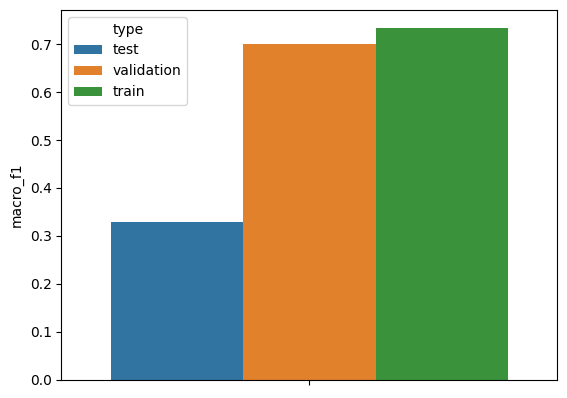

In [9]:
sns.barplot(data=df_performance, hue="type", y="macro_f1")



# 1. Compute Similarity

In [52]:
"""Here we will evaluate the Embeddings
Analyze how well the embeddings capture same disease as well as related diseases
"""

# 1. Imports, Variables, Functions
# imports
from typing import *
from scipy.spatial.distance import cdist
import itertools
import obonet
import networkx as nx
import sys
sys.path.append(os.path.join("..", ".."))
from src.utils import utils as ut
from src.utils import viz as vz
import logging
import os
# variable


# functions

# 2. Load Data

# load scGPT embeddings
# if embedding_type == "ft":
#     embeddings_test = vz.merge_embeddings(all_outputs_test[split_idx])
#     embeddings_valid = vz.merge_embeddings(all_outputs_valid[split_idx])
#     embeddings_train = vz.merge_embeddings(all_outputs_train[split_idx])
# elif embedding_type == "pt":
#     embeddings_test = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "test-pt_embeddings.npy"))
#     embeddings_valid = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "valid-pt_embeddings.npy"))
#     embeddings_train = np.load(os.path.join("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/",run_name, "train-pt_embeddings.npy"))
# elif embedding_type == "raw":
#     embeddings_test = adata_test.X
#     embeddings_valid = adata_valid.X
#     embeddings_train = adata_train.X
import pickle
embeddings_test = pickle.load(open("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/run-25-09-13-18/test-pt_embed_adata.pkl", "rb"))
embeddings_test = embeddings_test.obsm["X_scGPT"]

embeddings_train = pickle.load(open("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/run-25-09-13-18/train-pt_embed_adata.pkl", "rb"))
embeddings_train = embeddings_train.obsm["X_scGPT"]

embeddings_valid = pickle.load(open("/aloy/scratch/ddalton/projects/scGPT_playground/outputs/run-25-09-13-18/valid-pt_embed_adata.pkl", "rb"))
embeddings_valid = embeddings_valid.obsm["X_scGPT"]



# compute cosine similarity between all embeddings
c_matrix_train = 1 - cdist(embeddings_train, embeddings_train, "cosine")
c_matrix_valid = 1 - cdist(embeddings_valid, embeddings_valid, "cosine")
c_matrix_test = 1 - cdist(embeddings_test, embeddings_test, "cosine")

# compute cosine similarity between sets
c_matrix_test_vs_train = 1 - cdist(embeddings_test, embeddings_train, "cosine")
c_matrix_valid_vs_train = 1 - cdist(embeddings_valid, embeddings_train, "cosine")

# 2. Benchmark Disease vs Control Similarity

In [53]:
import importlib
importlib.reload(vz)

df_train = adata_train.obs.copy()
df_test = adata_test.obs.copy()
df_valid = adata_valid.obs.copy()

df_all = pd.concat([df_train, df_valid, df_test], axis=0)
df_all = df_all.query("doid_id != 'Control'")

dsaid_2_dis = dict(zip(df_all["dsaid"], df_all["doid_id"]))

In [54]:
"""2. Benchmark Disease vs Control Similarity

Structure:
    1. Imports, Variables, Functions
    2. Get Similarity
    3. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports
from tqdm import tqdm
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# variables


# functions
# 2. Get Similarity
# define sets of related & unrelated 
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# train set
# same disease pairs
(tr_s_same_same,tr_s_same_diff,tr_s_ctrl_same, tr_s_ctrl_diff), (tr_w_same_same, tr_w_same_diff, tr_w_ctrl_same, tr_w_ctrl_diff) = vz.get_same_disease_sim(adata_train.obs, c_matrix_train)

# get unrelated pairs
tr_s_unr = vz.get_unrelated_pairs(
    adata_train.obs,
    do_df_ic_query,
    c_matrix_train,
    n_samples=10000,
    seed=42,
)

# validation set
(vl_s_same_diff, vl_s_ctrl_diff), ( vl_w_same_diff, vl_w_ctrl_diff) = vz.get_same_dis_similarity_splits(adata_valid, adata_train, c_matrix_valid_vs_train,dsaid_2_dis)
vl_s_unr,_,_ = vz.get_unrelated_pairs_split_2(adata_valid, adata_train, c_matrix_valid_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)



# test set
(ts_s_same_diff, ts_s_ctrl_diff), ( ts_w_same_diff, ts_w_ctrl_diff) = vz.get_same_dis_similarity_splits(adata_test, adata_train, c_matrix_test_vs_train,dsaid_2_dis)
ts_s_unr,_,_ =vz.get_unrelated_pairs_split_2(adata_test, adata_train, c_matrix_test_vs_train, df_unrelated, dsaid_2_dis,sample_size=10000, include_control=True)




Processing same disease pairs: 100%|██████████| 124/124 [00:11<00:00, 11.21it/s]


124 diseases in dataset


7626it [00:20, 370.65it/s]


130783999 unrelated pairs found
10000
Selected 10000 unrelated pairs
Sampled pairs: 10000


100%|██████████| 6586/6586 [02:59<00:00, 36.74it/s] 


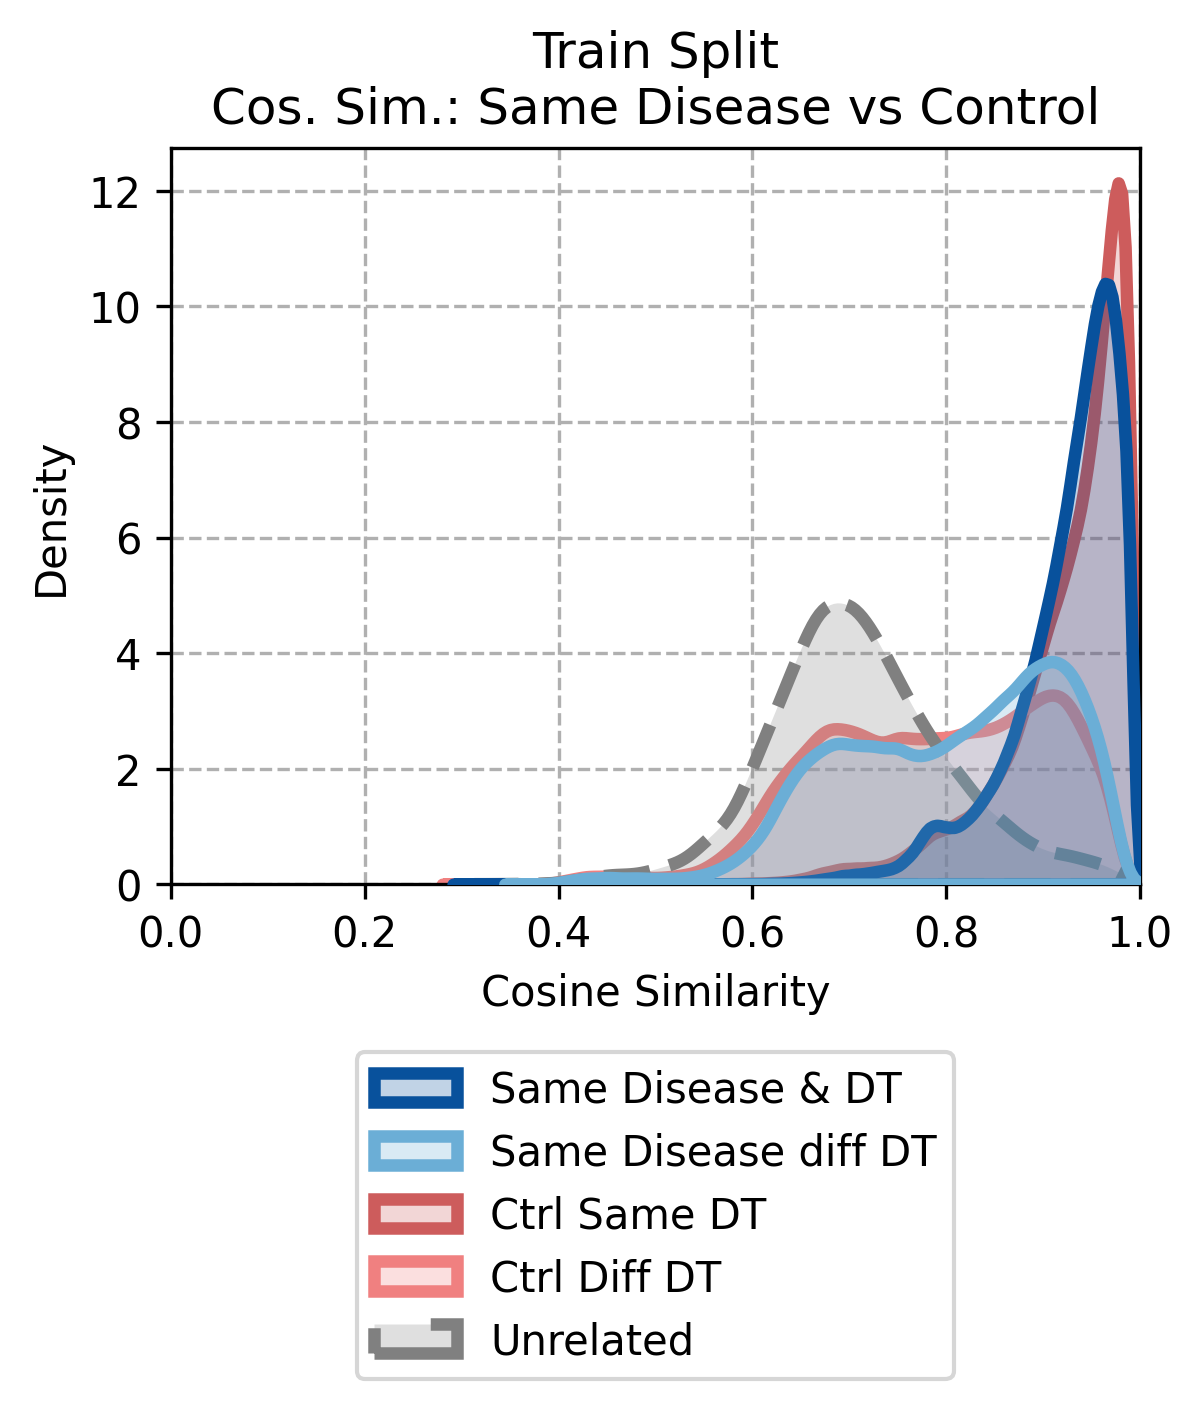

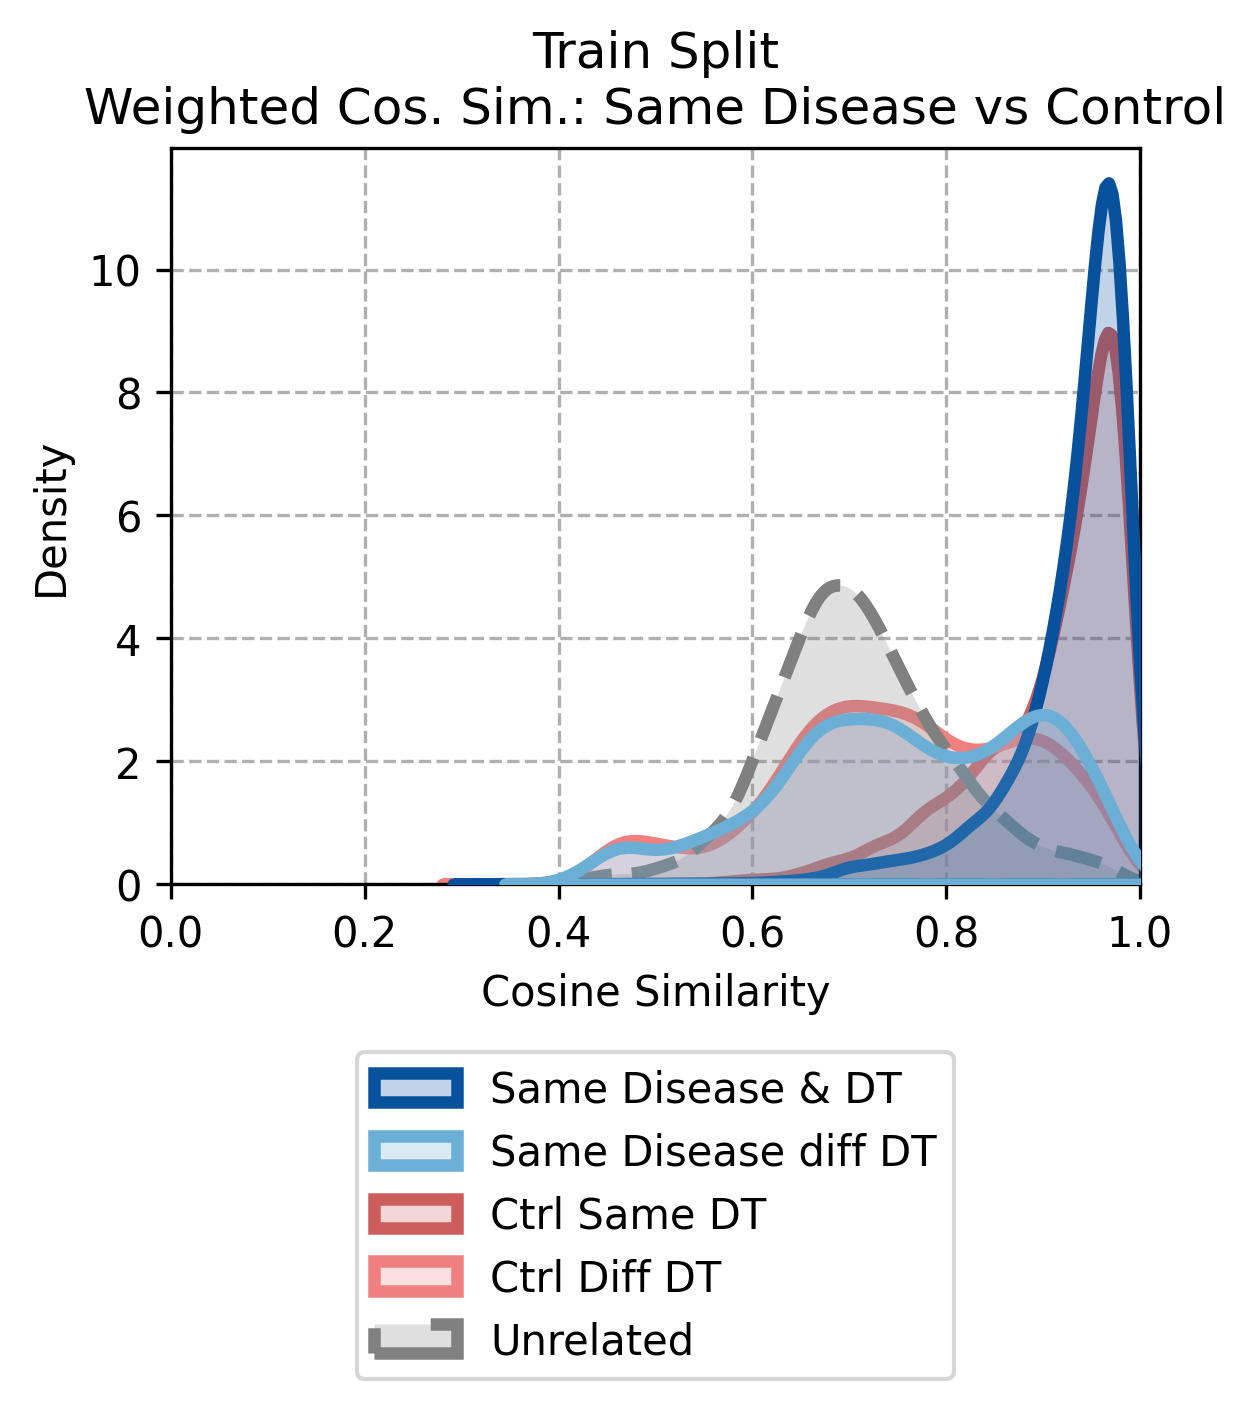

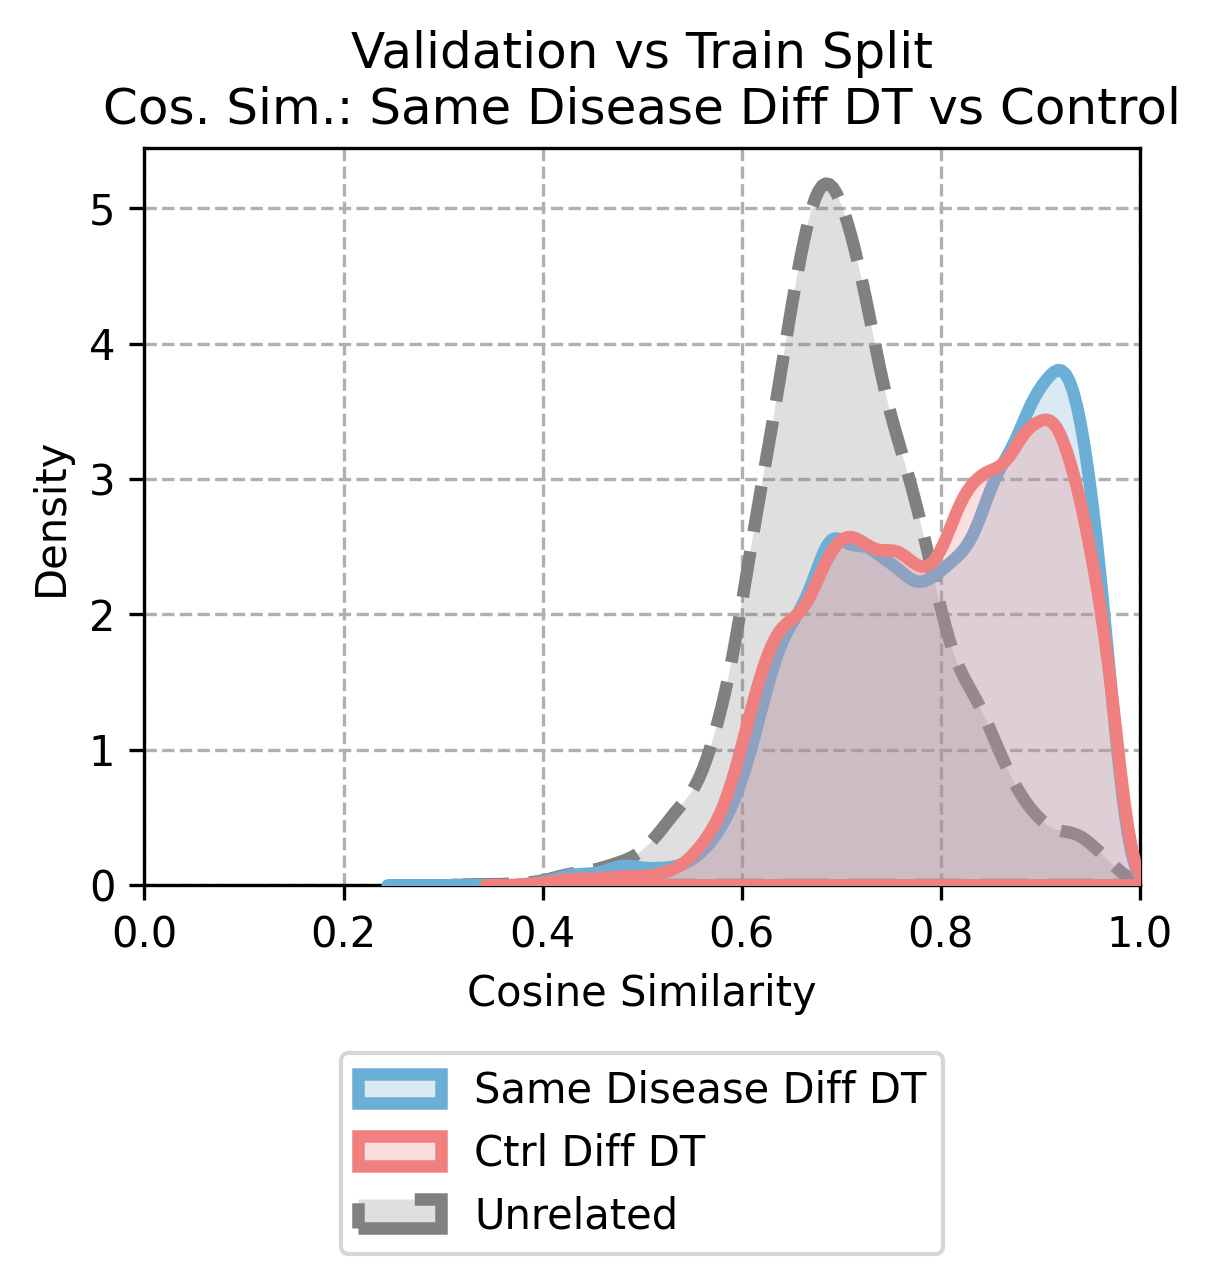

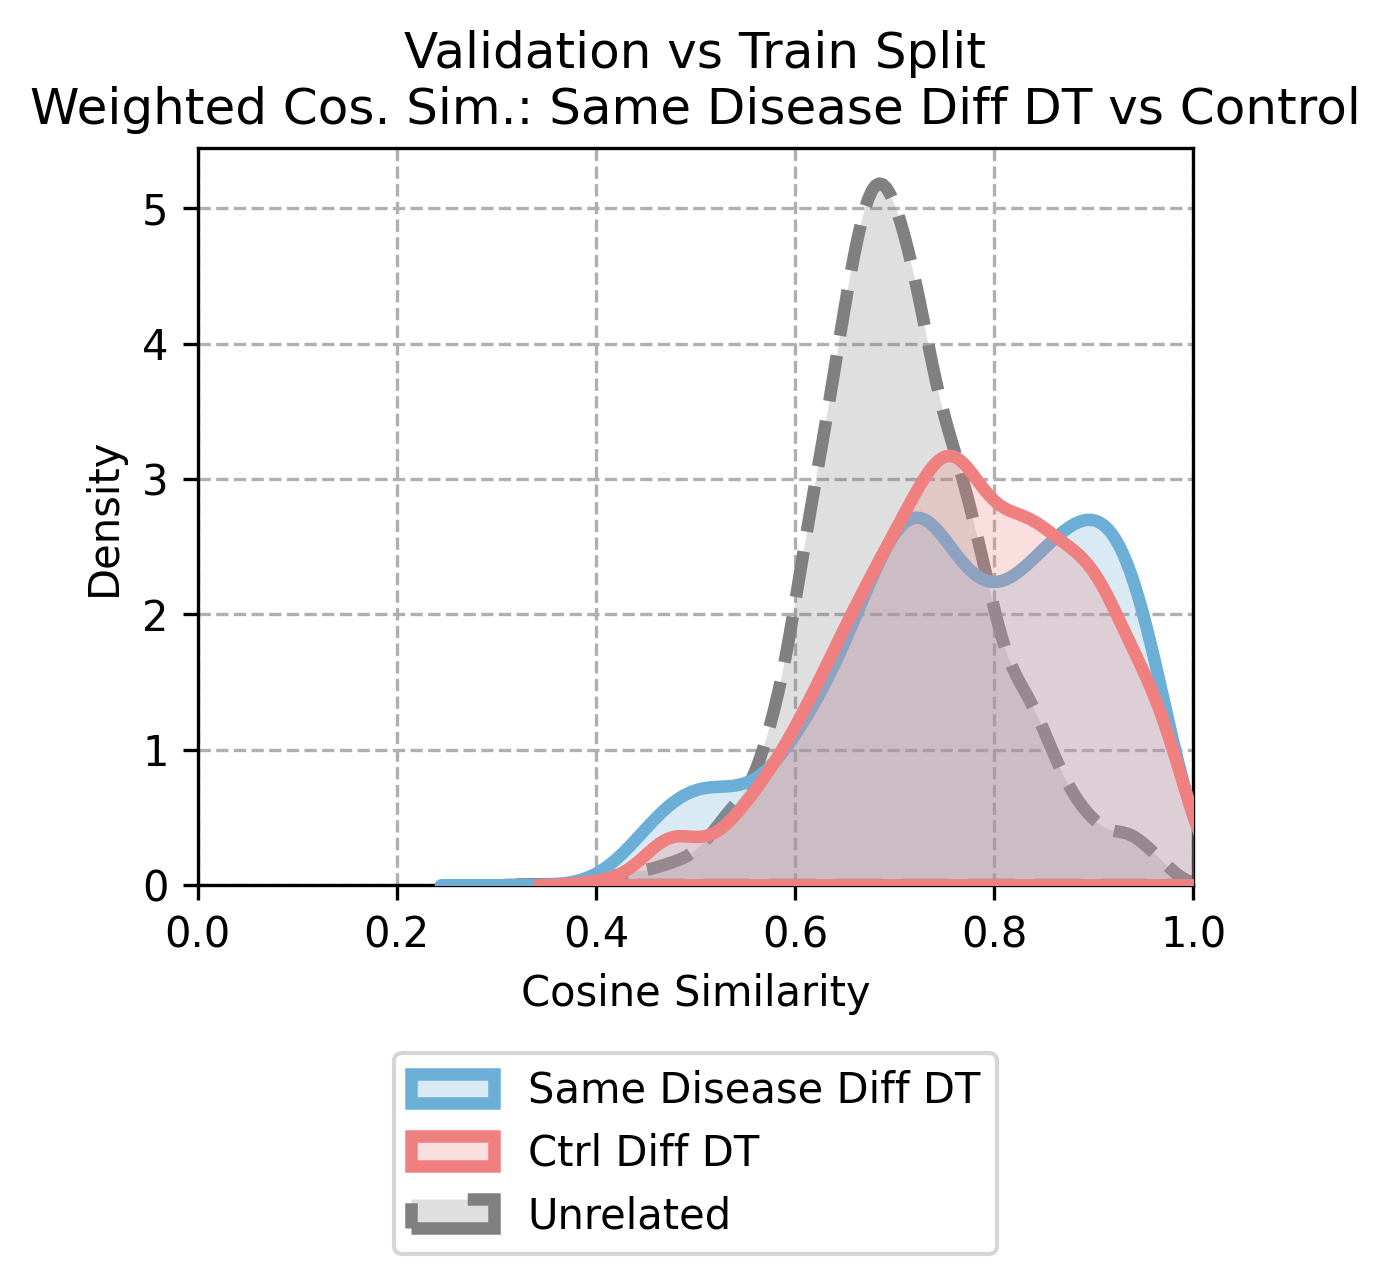

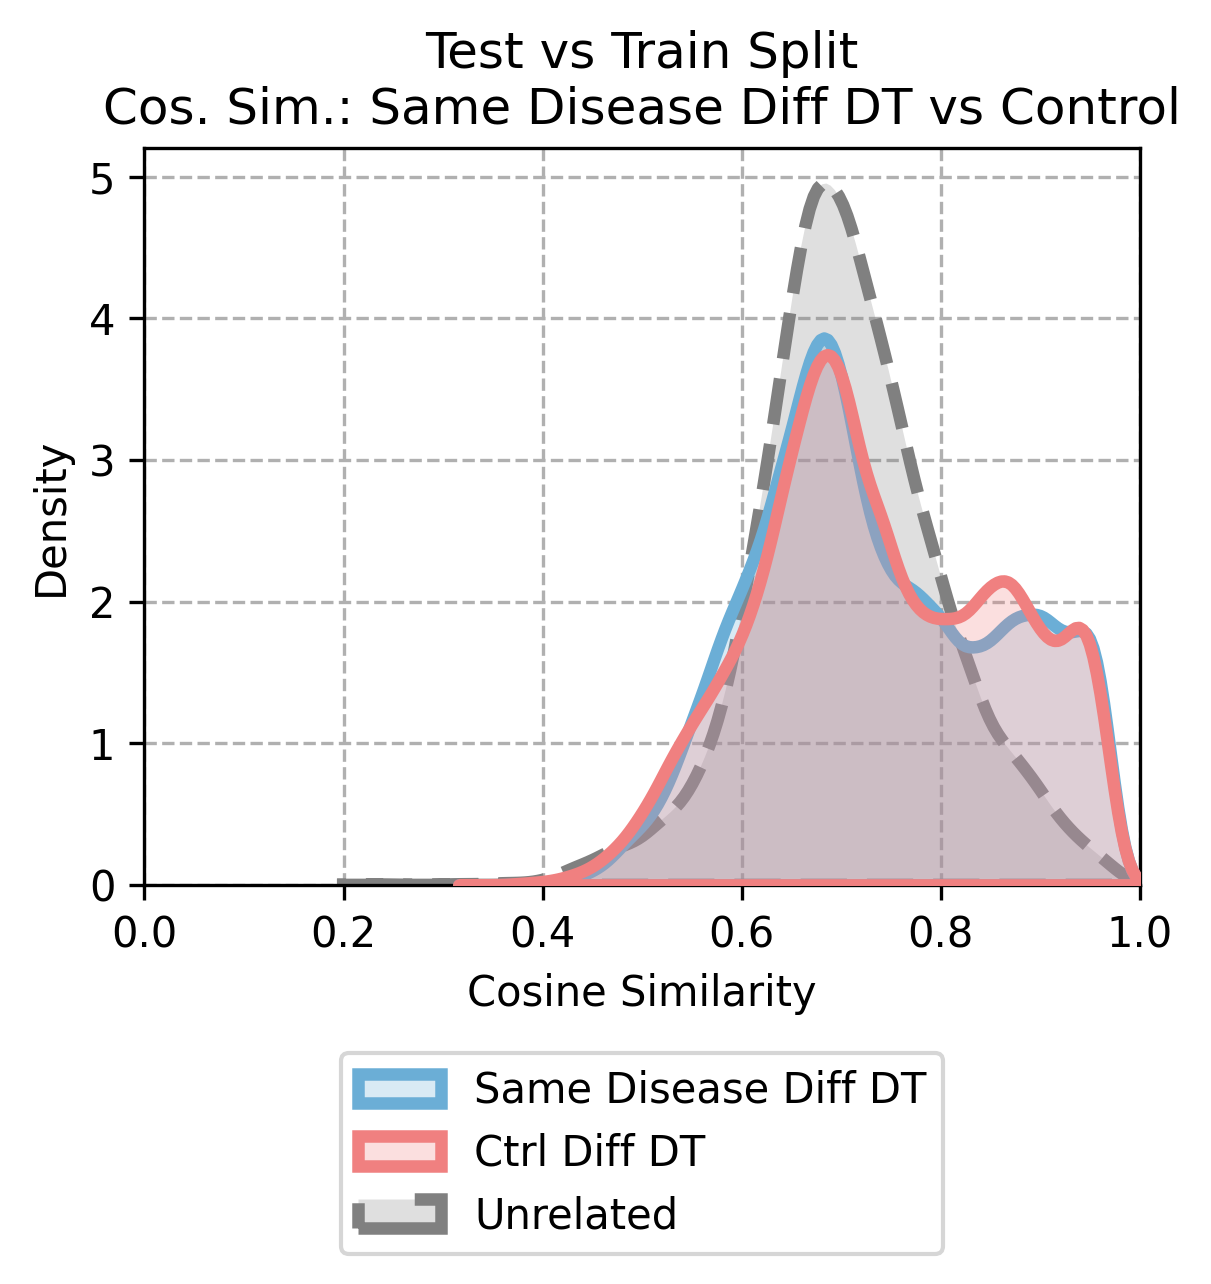

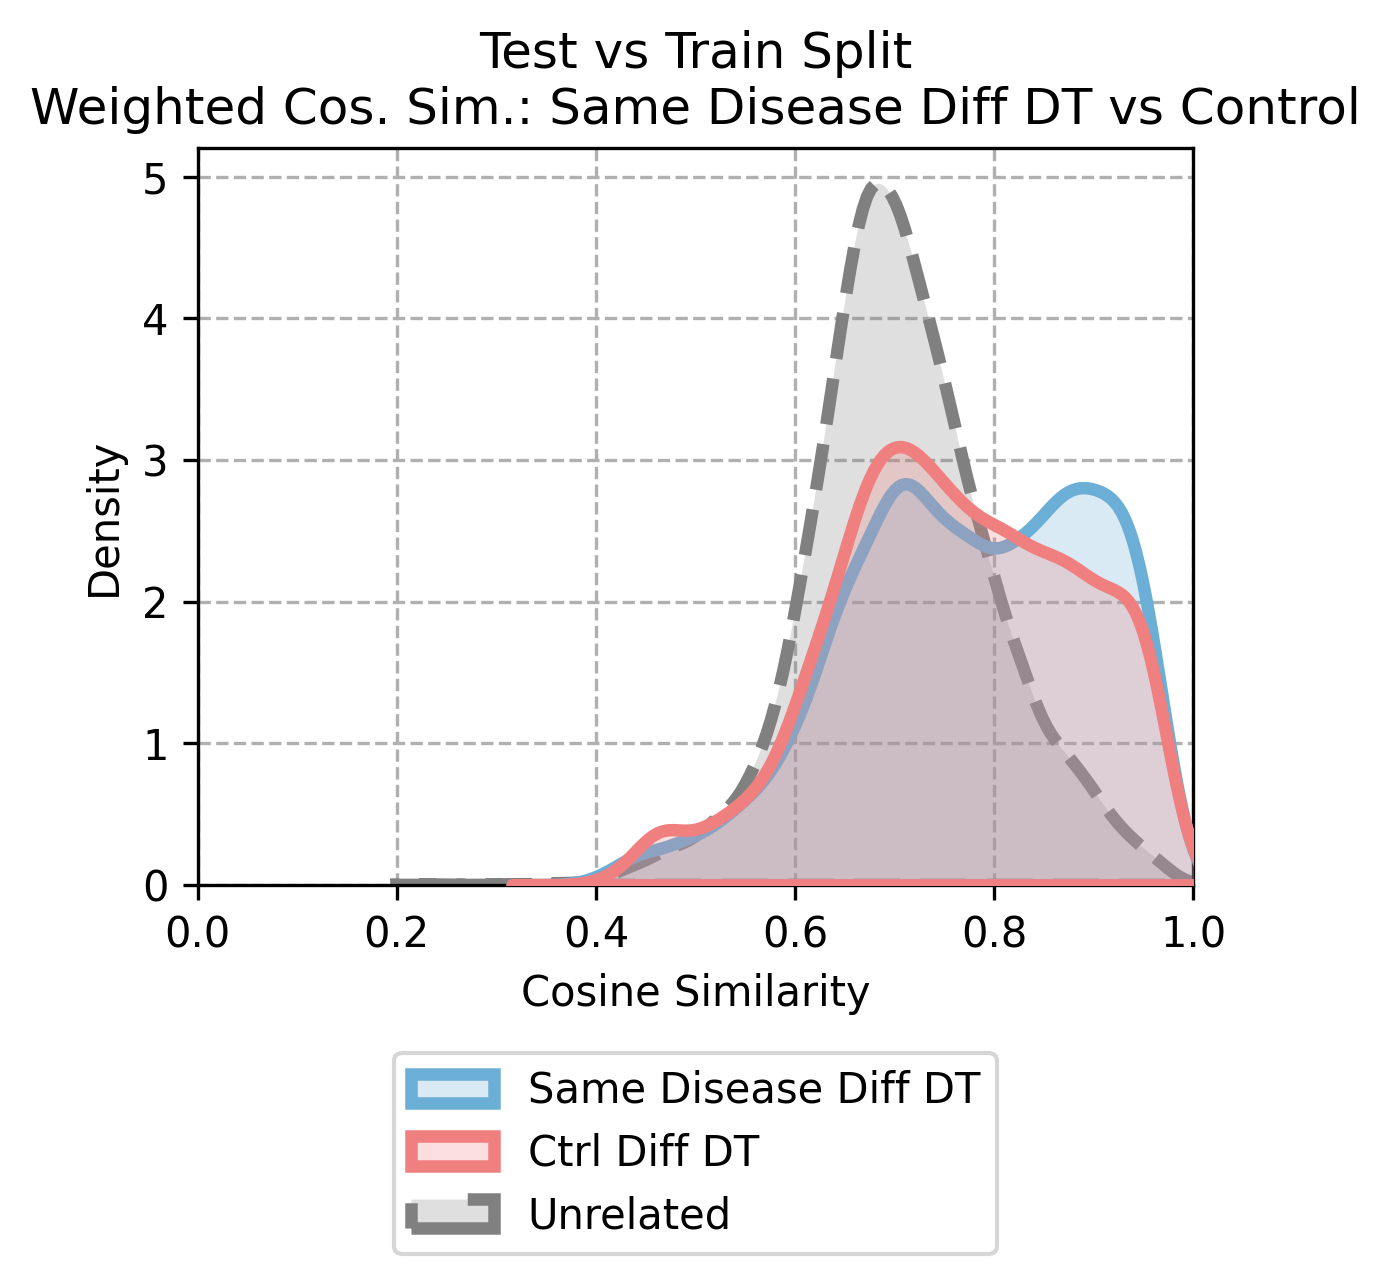

In [55]:
# 3. Plot Similarity
dpi_val = 300
# train
# unweighted
vz.plot_kde([tr_s_same_same, tr_s_same_diff, tr_s_ctrl_same, tr_s_ctrl_diff, tr_s_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Train Split\nCos. Sim.: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],dpi=dpi_val,
             weights=None, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_train_dis_id.png"))

# weighted
vz.plot_kde([tr_s_same_same, tr_s_same_diff, tr_s_ctrl_same, tr_s_ctrl_diff, tr_s_unr], 
            ["Same Disease & DT", "Same Disease diff DT", "Ctrl Same DT", "Ctrl Diff DT", "Unrelated"], 
            title="Train Split\nWeighted Cos. Sim.: Same Disease vs Control", 
            colors=["#08519c","#6baed6", "indianred", "lightcoral", "gray"],
             weights=[tr_w_same_same, tr_w_same_diff, tr_w_ctrl_same, tr_w_ctrl_diff, None],output_dir=os.path.join(output_dir, f"{embedding_type}-kde_train_dis_id_w.png"),dpi=dpi_val)




# validation set
# unweighted
vz.plot_kde([vl_s_same_diff, vl_s_ctrl_diff, vl_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Validation vs Train Split\nCos. Sim.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],dpi=dpi_val,
             weights=None, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_val_dis_id.png"))

# weighted
vz.plot_kde([vl_s_same_diff, vl_s_ctrl_diff, vl_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Validation vs Train Split\nWeighted Cos. Sim.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],
             weights=[vl_w_same_diff, vl_w_ctrl_diff, None],dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_val_dis_id_w.png"))


# test set
# unweighted
vz.plot_kde([ts_s_same_diff, ts_s_ctrl_diff, ts_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Test vs Train Split\nCos. Sim.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],dpi=dpi_val,
             weights=None, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_test_dis_id.png"))

# weighted
vz.plot_kde([ts_s_same_diff, ts_s_ctrl_diff, ts_s_unr], 
            ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
            title="Test vs Train Split\nWeighted Cos. Sim.: Same Disease Diff DT vs Control", 
            colors=["#6baed6", "lightcoral", "gray"],
             weights=[ts_w_same_diff, ts_w_ctrl_diff, None],dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_test_dis_id_w.png"))


## 2.2 stratified by disease category

In [56]:
from typing import *
from anndata import AnnData as Anndata

def return_composition_top_k(same, related, unrelated, k=100):
    # concatenate all values with labels
    values = np.concatenate([same, related, unrelated])
    labels = (["same"] * len(same) +
              ["related"] * len(related) +
              ["unrelated"] * len(unrelated))
    labels = np.array(labels)

    # get indices of top k
    topk_idx = np.argsort(values)[::-1][:k]

    # slice labels of top k
    topk_labels = labels[topk_idx]

    # count each category
    n_same = np.sum(topk_labels == "same")
    n_related = np.sum(topk_labels == "related")
    n_unrelated = np.sum(topk_labels == "unrelated")

    return n_same, n_related, n_unrelated, k

def return_top_k(same, others):
    # concatenate all values with labels
    values = np.concatenate([same, others])

    # sort values
    values = np.sort(values)[::-1]

    # get indices of top k
    all_idxs = np.where(np.isin(values, same))[0]

    return min(all_idxs) + 1  # +1 to convert from 0-based to 1-based rank

def get_perf_per_smp(adata_qry:Anndata, adata_ref:Anndata, df_related:pd.DataFrame, df_unrelated:pd.DataFrame, c_matrix:np.ndarray, doid_to_term:dict)->pd.DataFrame:
    results_per_smp = list()
    for doid_i in tqdm(adata_qry.obs["doid_id"].unique()):
        if doid_i == "Control":
            continue
        # get related & unrelated diseases
        related_i = set(df_related.query(f"do1 == '{doid_i}'")["do2"].values)
        related_i = related_i.union(set(df_related.query(f"do2 == '{doid_i}'")["do1"].values))
        related_i = list(related_i)

        unrelated_i = set(df_unrelated.query(f"do1 == '{doid_i}'")["do2"].values)
        unrelated_i = unrelated_i.union(set(df_unrelated.query(f"do2 == '{doid_i}'")["do1"].values))
        unrelated_i = list(unrelated_i)

        # get idxs
        idx_1 = np.array(adata_qry.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # query disease
        idx_2 = np.array(adata_ref.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # reference disease
        idx_3 = np.array(adata_ref.obs.query(f"(doid_id in @related_i)").index).astype(int)  # reference unrelated diseases
        idx_4 = np.array(adata_ref.obs.query(f"(doid_id in @unrelated_i)").index).astype(int)  # reference unrelated diseases
        dsaids = adata_ref.obs.query(f"(doid_id in @unrelated_i)")["dsaid"].unique()
        idx_5 = np.array(adata_ref.obs.query(f"(dsaid in @dsaids)").index).astype(int)  # reference unrelated diseases

        if len(idx_1) == 0:
            print(f"Skipping {doid_i} - {doid_to_term.get(doid_i)} due to lack of pairs")
            print(f"Nº same: {len(idx_1)}\tNº related: {len(idx_2)}\tNº unrelated: {len(idx_3)}")
            continue

        _same_j = list()
        _related_j = list()
        _unrelated_j = list()
        for idx_j in idx_1: # loop through samples 
            idx_pairs_1 = np.array(list(itertools.product([idx_j], idx_2)))
            idx_pairs_2 = np.array(list(itertools.product([idx_j], idx_3)))
            idx_pairs_3 = np.array(list(itertools.product([idx_j], idx_4)))
            _s_same = c_matrix[idx_pairs_1[:, 0], idx_pairs_1[:, 1]]
            
            if len(idx_pairs_2) == 0:
                _s_related = np.array([])
            else:
                _s_related = c_matrix[idx_pairs_2[:, 0], idx_pairs_2[:, 1]]

            if len(idx_pairs_3) == 0:
                _s_unrelated = np.array([])
            else:
                _s_unrelated = c_matrix[idx_pairs_3[:, 0], idx_pairs_3[:, 1]]

            _top_k = return_top_k(_s_same, np.concatenate([_s_related, _s_unrelated]))
            _composition = return_composition_top_k(_s_same, _s_related, _s_unrelated, k=100)

            _same_j.extend(_s_same)
            _related_j.extend(_s_related)
            _unrelated_j.extend(_s_unrelated)

            # results per sample
            results_per_smp.append({
                "doid": doid_i,
                "disease": doid_to_term.get(doid_i),
                "top_k": _top_k,
                "n_same_top100": _composition[0],
                "n_related_top100": _composition[1],
                "n_unrelated_top100": _composition[2],
                "k": _composition[3],
                "n_positives": len(_s_same),
                "n_related": len(_s_related),
                "n_unrelated": len(_s_unrelated),
            })        
            
        df_per_smp = pd.DataFrame(results_per_smp)

    return  df_per_smp

from typing import *
from anndata import AnnData as Anndata
import random
def get_perf_per_dis(adata_qry:Anndata, adata_ref:Anndata, df_related:pd.DataFrame, df_unrelated:pd.DataFrame, c_matrix:np.ndarray, doid_to_term:dict)->pd.DataFrame:
    results_per_dis = list()
    for doid_i in tqdm(adata_qry.obs["doid_id"].unique()):
        if doid_i == "Control":
            continue
        # get related & unrelated diseases
        related_i = set(df_related.query(f"do1 == '{doid_i}'")["do2"].values)
        related_i = related_i.union(set(df_related.query(f"do2 == '{doid_i}'")["do1"].values))
        related_i = list(related_i)

        unrelated_i = set(df_unrelated.query(f"do1 == '{doid_i}'")["do2"].values)
        unrelated_i = unrelated_i.union(set(df_unrelated.query(f"do2 == '{doid_i}'")["do1"].values))
        unrelated_i = list(unrelated_i)

        # get idxs
        idx_1 = np.array(adata_qry.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # query disease
        idx_2 = np.array(adata_ref.obs.query(f"(doid_id == '{doid_i}')").index).astype(int)    # reference disease
        idx_3 = np.array(adata_ref.obs.query(f"(doid_id in @related_i)").index).astype(int)  # reference unrelated diseases
        idx_4 = np.array(adata_ref.obs.query(f"(doid_id in @unrelated_i)").index).astype(int)  # reference unrelated diseases
        dsaids = adata_ref.obs.query(f"(doid_id in @unrelated_i)")["dsaid"].unique()
        idx_5 = np.array(adata_ref.obs.query(f"(dsaid in @dsaids)").index).astype(int)  # reference unrelated diseases

        if len(idx_1) == 0 or len(idx_2) == 0 or len(idx_5) == 0:
            print(f"Skipping {doid_i} - {doid_to_term.get(doid_i)} due to lack of pairs")
            print(f"Nº same: {len(idx_2)}\tNº unrelated: {len(idx_5)}")
            continue
        
        idx_pairs_1 = np.array(list(itertools.product(idx_1, idx_2)))
        idx_pairs_2 = np.array(list(itertools.product(idx_1, idx_5)))

        _s_same = c_matrix[idx_pairs_1[:, 0], idx_pairs_1[:, 1]]
        _s_unrelated = c_matrix[idx_pairs_2[:, 0], idx_pairs_2[:, 1]]        

        # results per disease
        ap_i = average_precision_score(
            [1] * len(_s_same) + [0] * (len(_s_unrelated)),
            np.concatenate([_s_same, _s_unrelated])
        )
        random_i = len(_s_same) / (len(_s_same) + len(_s_unrelated)) if (len(_s_same) + len(_s_unrelated)) > 0 else 0
        auroc_i = roc_auc_score(
            [1] * len(_s_same) + [0] * (len(_s_same)),
            np.concatenate([_s_same, np.array(random.sample(list(_s_unrelated), len(_s_same)))])
        )
        
        results_per_dis.append({
            "average_precision": ap_i,
            "roc_auc": auroc_i,
            "random": random_i,
            "disease": doid_to_term.get(doid_i),
            "doid": doid_i,
            "n_positives": len(_s_same),
            "n_unrelated": len(_s_unrelated),
        })

        df_per_dis = pd.DataFrame(results_per_dis)

    return df_per_dis



In [57]:
df_test_per_dis = get_perf_per_dis(adata_test, adata_train, df_related, df_unrelated, c_matrix_test_vs_train, doid_to_term)
df_valid_per_dis = get_perf_per_dis(adata_valid, adata_train, df_related, df_unrelated, c_matrix_valid_vs_train, doid_to_term)


100%|██████████| 107/107 [00:17<00:00,  6.04it/s]


In [58]:
df_test_per_smp = get_perf_per_smp(adata_test, adata_train, df_related, df_unrelated, c_matrix_test_vs_train, doid_to_term)
df_valid_per_smp = get_perf_per_smp(adata_valid, adata_train, df_related, df_unrelated, c_matrix_valid_vs_train, doid_to_term)


100%|██████████| 107/107 [00:06<00:00, 15.29it/s]


In [59]:
_df_test_colaps = df_test_per_smp.groupby("doid")[["top_k", "n_related_top100", "n_unrelated_top100", "n_same_top100"]].mean().reset_index()
_df_valid_colaps = df_valid_per_smp.groupby("doid")[["top_k", "n_related_top100", "n_unrelated_top100", "n_same_top100"]].mean().reset_index()
df_test_merge = df_test_per_dis.merge(_df_test_colaps, on="doid", suffixes=("_dis", "_smp"))
df_valid_merge = df_valid_per_dis.merge(_df_valid_colaps, on="doid", suffixes=("_dis", "_smp"))

In [60]:
# cap average precision 


df_test_merge["average_precision"] = df_test_merge["average_precision"].apply(lambda x: 0 if x <0.05 else x)
# sort diseases
dis_order = df_test_merge.sort_values(
    by=["average_precision", "n_related_top100", "n_same_top100"],
    ascending=[False, False, False],
    na_position="last",   # put NaNs at the end
    kind="mergesort"      # stable: keeps original order within ties
)["disease"].unique().tolist()


In [61]:
df_test_merge["average_precision"] = df_test_merge["average_precision"].apply(lambda x: 0 if x <0.05 else x)


dis_order = df_test_merge.sort_values(
    by=["average_precision", "n_unrelated_top100"],
    ascending=[False, True],
    na_position="last",   # put NaNs at the end
    kind="mergesort"      # stable: keeps original order within ties
)

In [62]:
dis_order = dis_order["disease"].to_list()

In [63]:
adata_test.obs["library"].nunique()

1

/tmp/ipykernel_63390/4179346023.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='best')


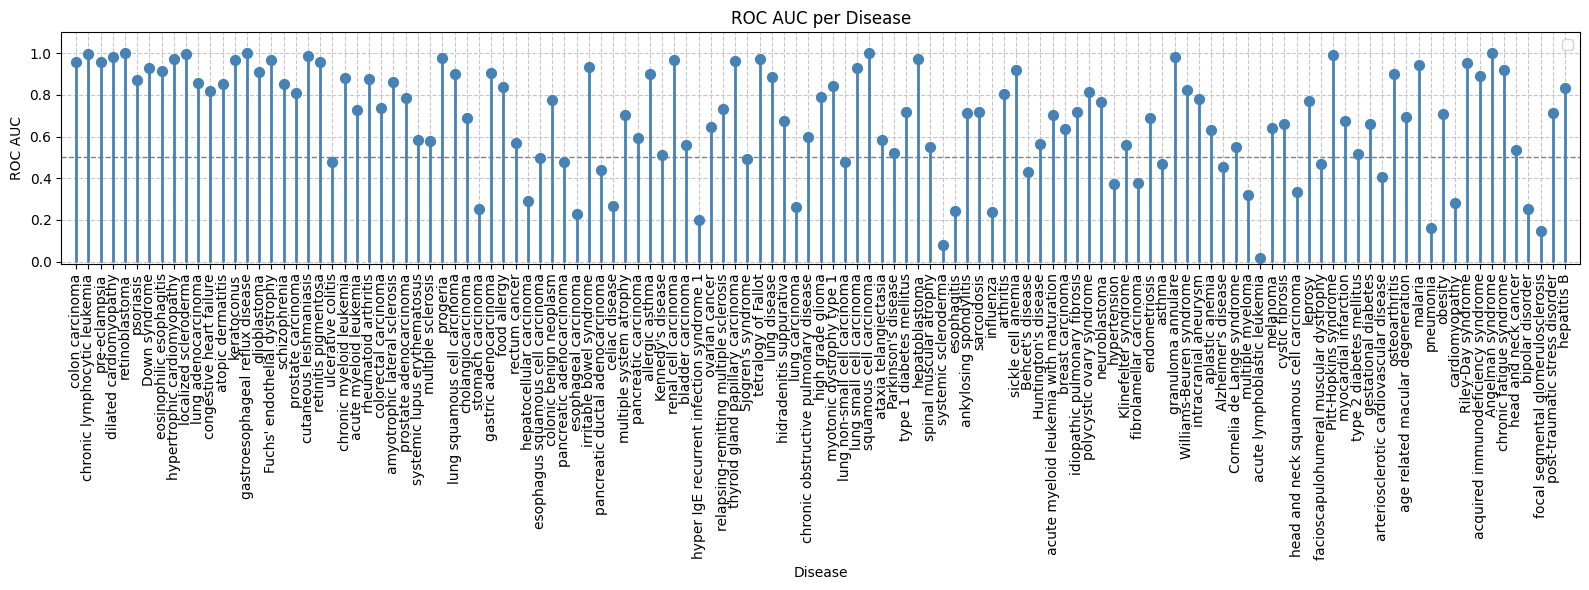

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plot values
plot_data = df_test_per_dis.groupby("disease")["roc_auc"].mean().to_dict()
x_vals = [plot_data.get(d, np.nan) for d in dis_order]

# random values
random_vals = df_test_per_dis.groupby("disease")["random"].mean().to_dict()
random_x_vals = [random_vals.get(d, np.nan) for d in dis_order]

# numeric positions for categories
xpos = np.arange(len(dis_order))

plt.figure(figsize=(16, 6))
plt.scatter(xpos, x_vals, color="steelblue", s=50, zorder=3)  # dots

# small horizontal red lines centered at each x
plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, zorder=-1)

# stems first (so dots appear on top)
plt.vlines(np.arange(len(dis_order)), 0.0, x_vals, color="steelblue", alpha=1, linewidth=2, zorder=2)

# cosmetics
plt.xticks(xpos, dis_order, rotation=90)
plt.margins(x=0.01, y=0.1)
plt.ylim(-0.01, 1.1)
plt.grid(linestyle='--', alpha=0.7, zorder=-3)

# labels / title (note: you're plotting average_precision, not AUROC)
plt.xlabel("Disease")
plt.ylabel("ROC AUC")
plt.title("ROC AUC per Disease")

# legend entries for point and red segments
plt.legend(loc='best')

plt.tight_layout()
plt.show()


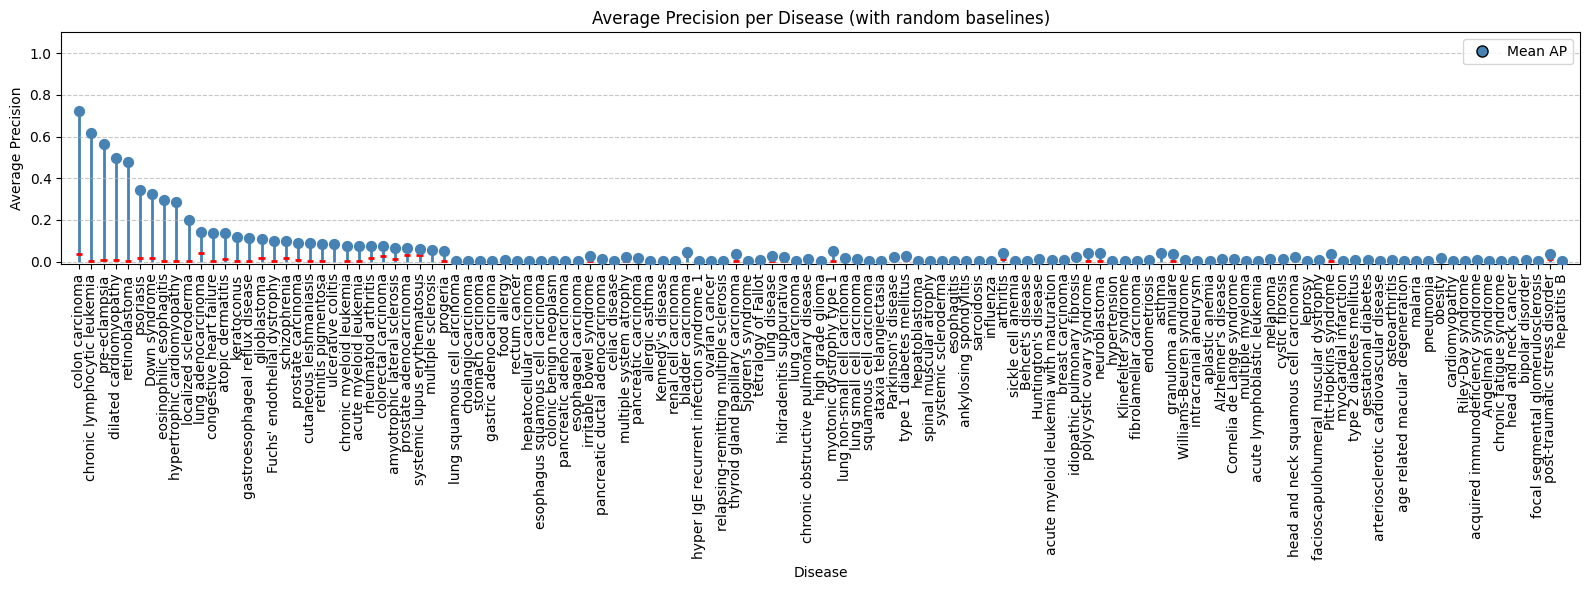

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plot values
plot_data = df_test_per_dis.groupby("disease")["average_precision"].mean().to_dict()
x_vals = [plot_data.get(d, np.nan) for d in dis_order]

# random values
random_vals = df_test_per_dis.groupby("disease")["random"].mean().to_dict()
random_x_vals = [random_vals.get(d, np.nan) for d in dis_order]

# numeric positions for categories
xpos = np.arange(len(dis_order))

plt.figure(figsize=(16, 6))
plt.scatter(xpos, x_vals, color="steelblue", s=50, zorder=3)  # dots

# small horizontal red lines centered at each x
half_len = 0.25  # half-length of the red segment
for i, y in enumerate(random_x_vals):
    if np.isfinite(y):
        plt.hlines(y, i - half_len, i + half_len, color="red", linewidth=2, zorder=2)

# stems first (so dots appear on top)
plt.vlines(np.arange(len(dis_order)), 0.0, x_vals, color="steelblue", alpha=1, linewidth=2, zorder=1)

# cosmetics
plt.xticks(xpos, dis_order, rotation=90)
plt.margins(x=0.01, y=0.1)
plt.ylim(-0.01, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=2)

# labels / title (note: you're plotting average_precision, not AUROC)
plt.xlabel("Disease")
plt.ylabel("Average Precision")
plt.title("Average Precision per Disease (with random baselines)")

# legend entries for point and red segments
legend_elems = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='steelblue', markersize=8, label='Mean AP'),
]
plt.legend(handles=legend_elems, loc='best')

plt.tight_layout()
plt.show()


/tmp/ipykernel_63390/1909864561.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _same_counts = df_test_per_smp.groupby("disease")["n_same_top100"].mean().to_dict()
/tmp/ipykernel_63390/1909864561.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _related_counts = df_test_per_smp.groupby("disease")["n_related_top100"].mean().to_dict()
/tmp/ipykernel_63390/1909864561.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

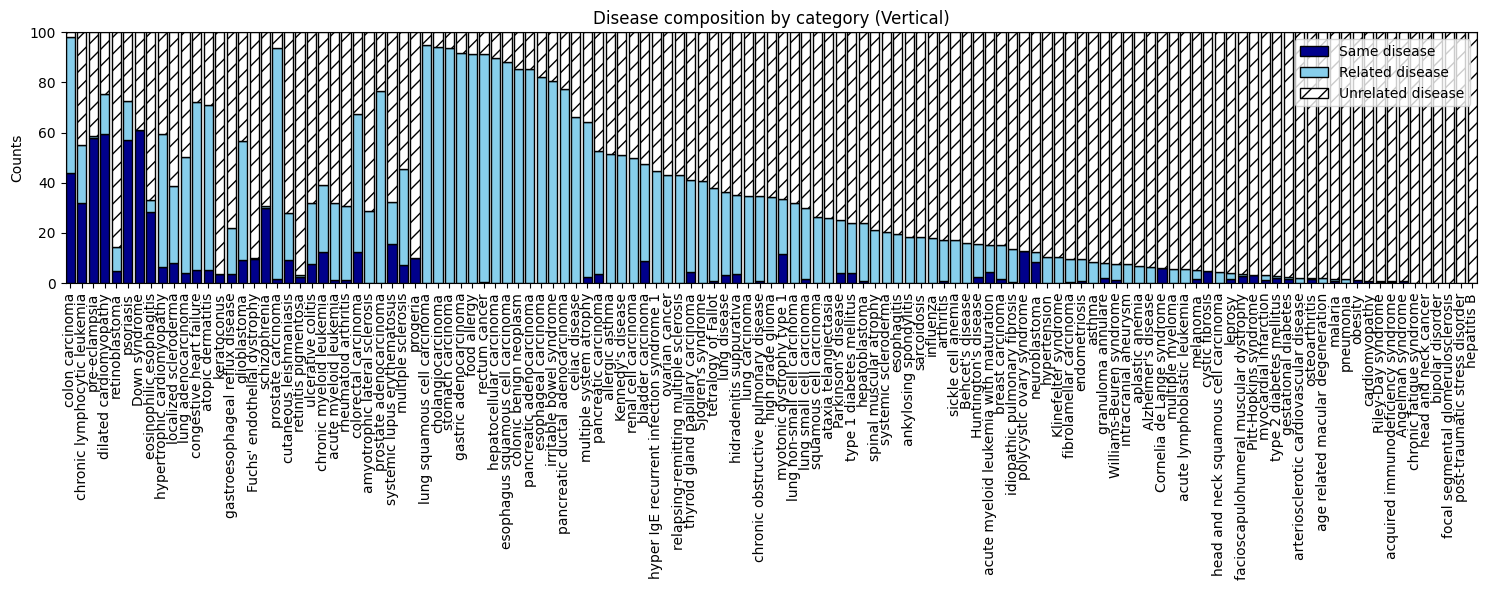

In [66]:

# Example data
# _dis_sorted = list(df_test_per_smp.groupby("disease")["n_same_top100"].mean().sort_values(ascending=False).index.to_list())[::-1]
# _dis_sorted = plot_data.index.to_list()[::-1]

df_test_per_smp["disease"] = pd.Categorical(df_test_per_smp["disease"], categories=dis_order, ordered=True)
df_test_per_smp.sort_values("disease", inplace=True)

_same_counts = df_test_per_smp.groupby("disease")["n_same_top100"].mean().to_dict()
_related_counts = df_test_per_smp.groupby("disease")["n_related_top100"].mean().to_dict()
_unrelated_counts = df_test_per_smp.groupby("disease")["n_unrelated_top100"].mean().to_dict()


# get ordered counts
_same_counts = [_same_counts[d] for d in dis_order]
_related_counts = [_related_counts[d] for d in dis_order]
_unrelated_counts = [_unrelated_counts[d] for d in dis_order]


x = np.arange(len(dis_order))

fig, ax = plt.subplots(figsize=(15, 6))

# Stacked vertical bars
bars_same = ax.bar(x, _same_counts, color="darkblue", label="Same disease", edgecolor="black")
bars_related = ax.bar(x, _related_counts, bottom=_same_counts,
                      color="skyblue", label="Related disease", edgecolor="black")
bars_unrelated = ax.bar(
    x, _unrelated_counts,
    bottom=np.array(_same_counts) + np.array(_related_counts),
    color="white", edgecolor="black", hatch="//", label="Unrelated disease"
)

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(dis_order, rotation=90)
ax.set_ylabel("Counts")
ax.set_title("Disease composition by category (Vertical)")
ax.legend()

plt.margins(x=0.0, y=0.0)
plt.ylim(-0, 100)  # adjust if your totals differ
plt.tight_layout()
plt.show()


# 3. Benchmark Disease Related Disease Similarity

## 3.1 Plot KDE & AUROC

In [67]:
"""Benchmark Disease Related Disease Similarity

Structure:
    1. Imports, Variables, Functions
    2. Plot Similarity
"""
# 1. Imports, Variables, Functions
# imports
import random

# variables
sample_size = 100000

# functions
def get_bins(vals, bins):

    """
    Get the bin for each value in vals based on the provided bins.
    """
    bin_list = list()
    for val in vals:
        for i in range(len(bins) - 1):
            if bins[i] <= val < bins[i + 1]:
                bin_list.append((f"{bins[i]}-{bins[i + 1]}"))
                break
    return bin_list


# 2. Plot Similarity

# Type 1: Plot similarity based on semantic similarity
# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

# bin data based on similarity
_bins = get_bins(do_df_ic_query["lin"].values,[0,0.2,0.4,0.6,0.8,1])
_bin_labels = ["'0.8-1'","'0.6-0.8'","'0.4-0.6'"]

# add new label to dataframe
df_related = df_related.copy()
df_related["shortest_path_length"] = _bins

# train
tr_s_all_1, tr_w_all_1, tr_l_all_1 = vz.get_related_dis_sim(
    adata_train, c_matrix_train, df_related, df_unrelated, labels=_bin_labels, sample=sample_size,
)

# valid
vl_s_all_1, vl_w_all_1, vl_l_all_1 = vz.get_related_dis_sim_splits(
    adata_valid, adata_train, c_matrix_valid_vs_train, df_related, df_unrelated, labels=_bin_labels, sample=sample_size)

# test
ts_s_all_1, ts_w_all_1, ts_l_all_1 = vz.get_related_dis_sim_splits(
    adata_test, adata_train, c_matrix_test_vs_train, df_related, df_unrelated, labels=_bin_labels, sample=sample_size)




# Type 2: Plot similarity based on DO graph distance
# define related & unrelated groups
df_related = do_df_ic_query.copy()
df_unrelated = do_df_negative_ic.copy()

# convert to tuple for compatibility w/ unique
df_related["pair_sorted"] = df_related["pair_sorted"].apply(tuple)
df_unrelated["pair_sorted"] = df_unrelated["pair_sorted"].apply(tuple)

labels = [2, 3, 5]  # define labels

# train
tr_s_all_2, tr_w_all_2, tr_l_all_2 = vz.get_related_dis_sim(
    adata_train, c_matrix_train, df_related, df_unrelated, labels, sample=sample_size,
)

# valid
vl_s_all_2, vl_w_all_2, vl_l_all_2 = vz.get_related_dis_sim_splits(
    adata_valid, adata_train, c_matrix_valid_vs_train, df_related, df_unrelated, labels, sample=sample_size)

# test
ts_s_all_2, ts_w_all_2, ts_l_all_2 = vz.get_related_dis_sim_splits(
    adata_test, adata_train, c_matrix_test_vs_train, df_related, df_unrelated, labels, sample=sample_size)


100%|██████████| 6586/6586 [00:01<00:00, 3322.47it/s]


Nº of unrelated disease pairs: 54147313
[SP '0.8-1'] Nº of related disease pairs: 48


100%|██████████| 48/48 [00:00<00:00, 61.58it/s]


Nº of related disease pairs for '0.8-1': 343652
[SP '0.6-0.8'] Nº of related disease pairs: 157


100%|██████████| 157/157 [00:05<00:00, 26.67it/s]


...

Nº of related disease pairs for 3: 2358085
[SP 5] Nº of related disease pairs: 135


100%|██████████| 135/135 [00:02<00:00, 65.05it/s]


Nº of related disease pairs for 5: 883370
Nº of diseases: 123


100%|██████████| 123/123 [00:00<00:00, 202.46it/s]


Nº of unrelated disease pairs: 2358085


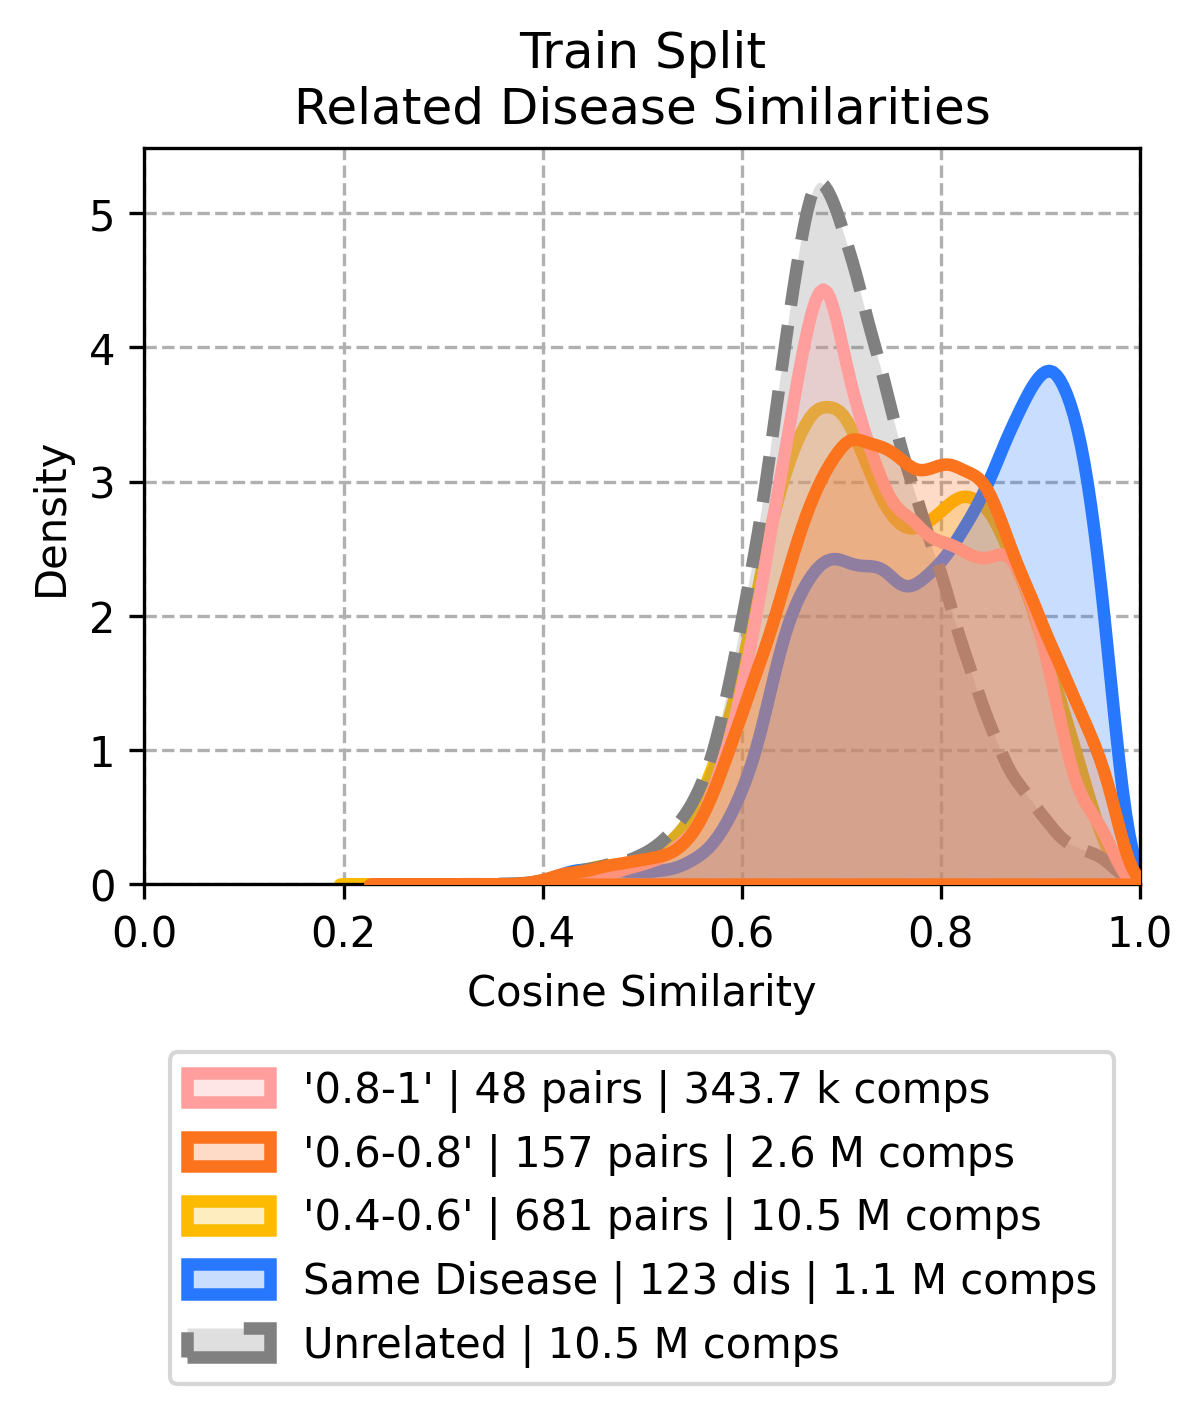

Nº of positive disease pairs: 343652
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 2635019
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 10454837
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 1058984
Nº of positive disease pairs: 100000


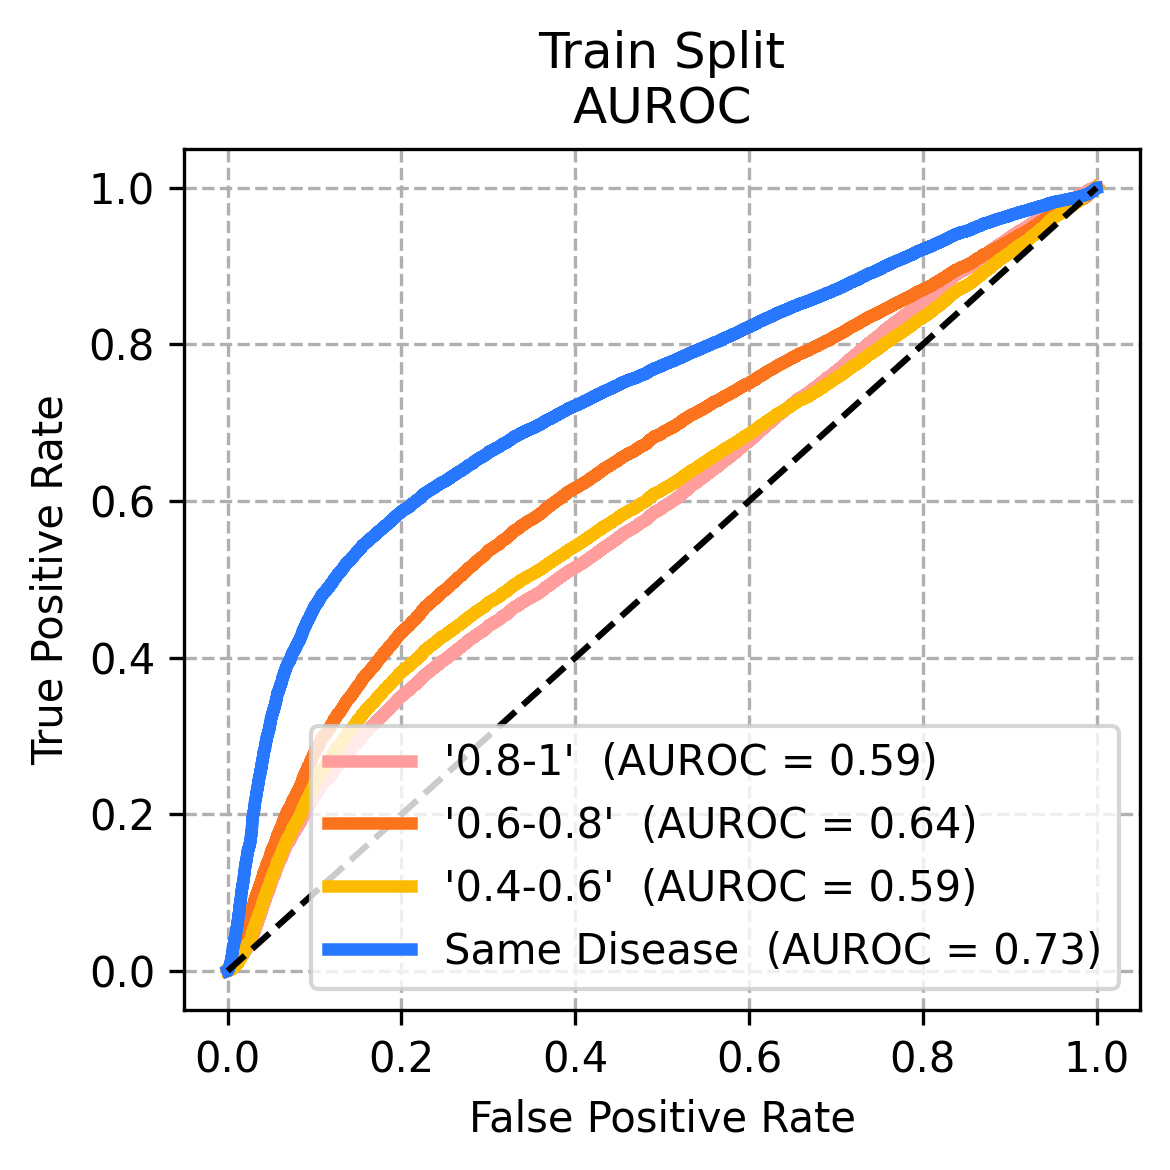

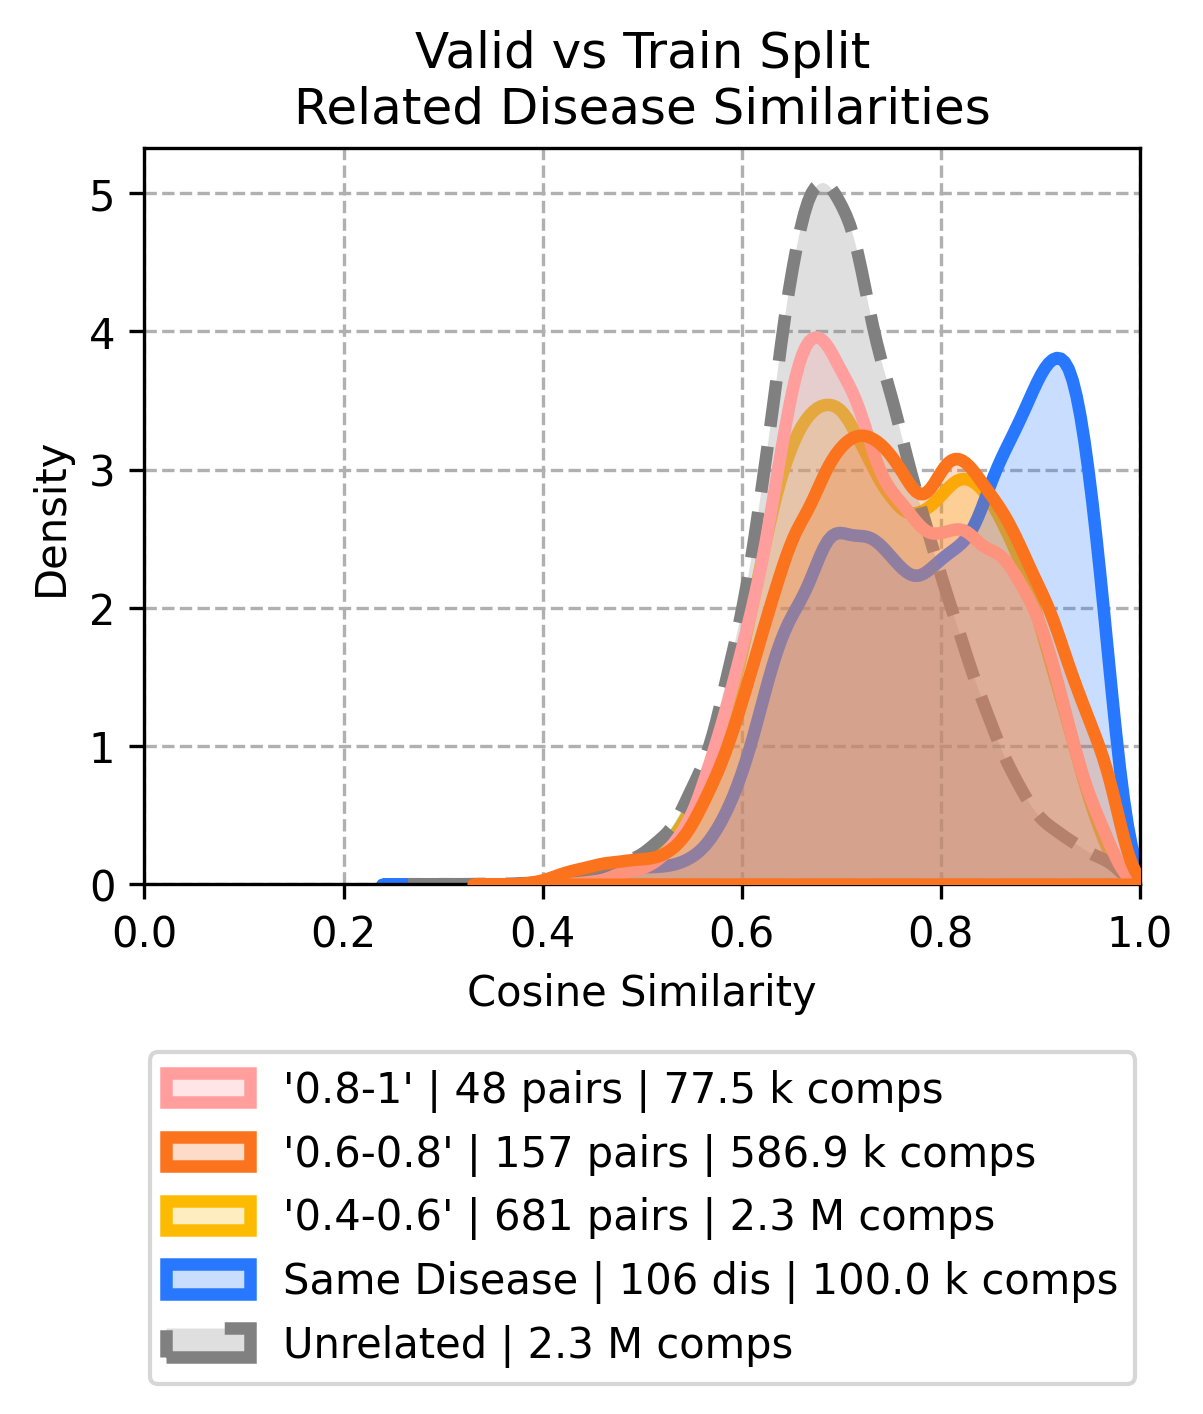

Nº of positive disease pairs: 77535
Nº of positive disease pairs: 77535
Nº of positive disease pairs: 586910
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 2328516
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000


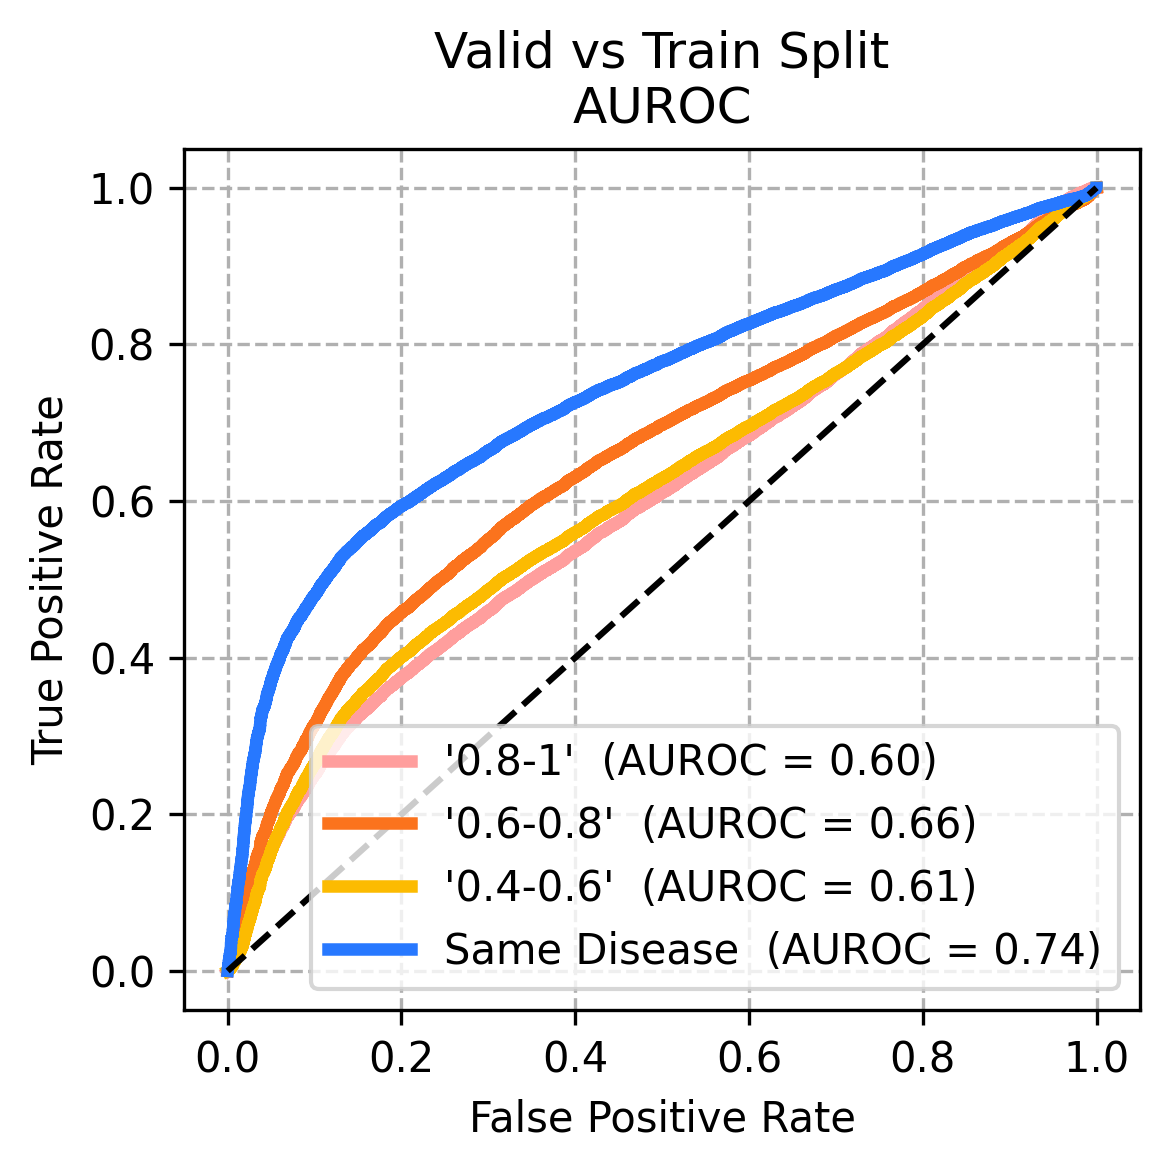

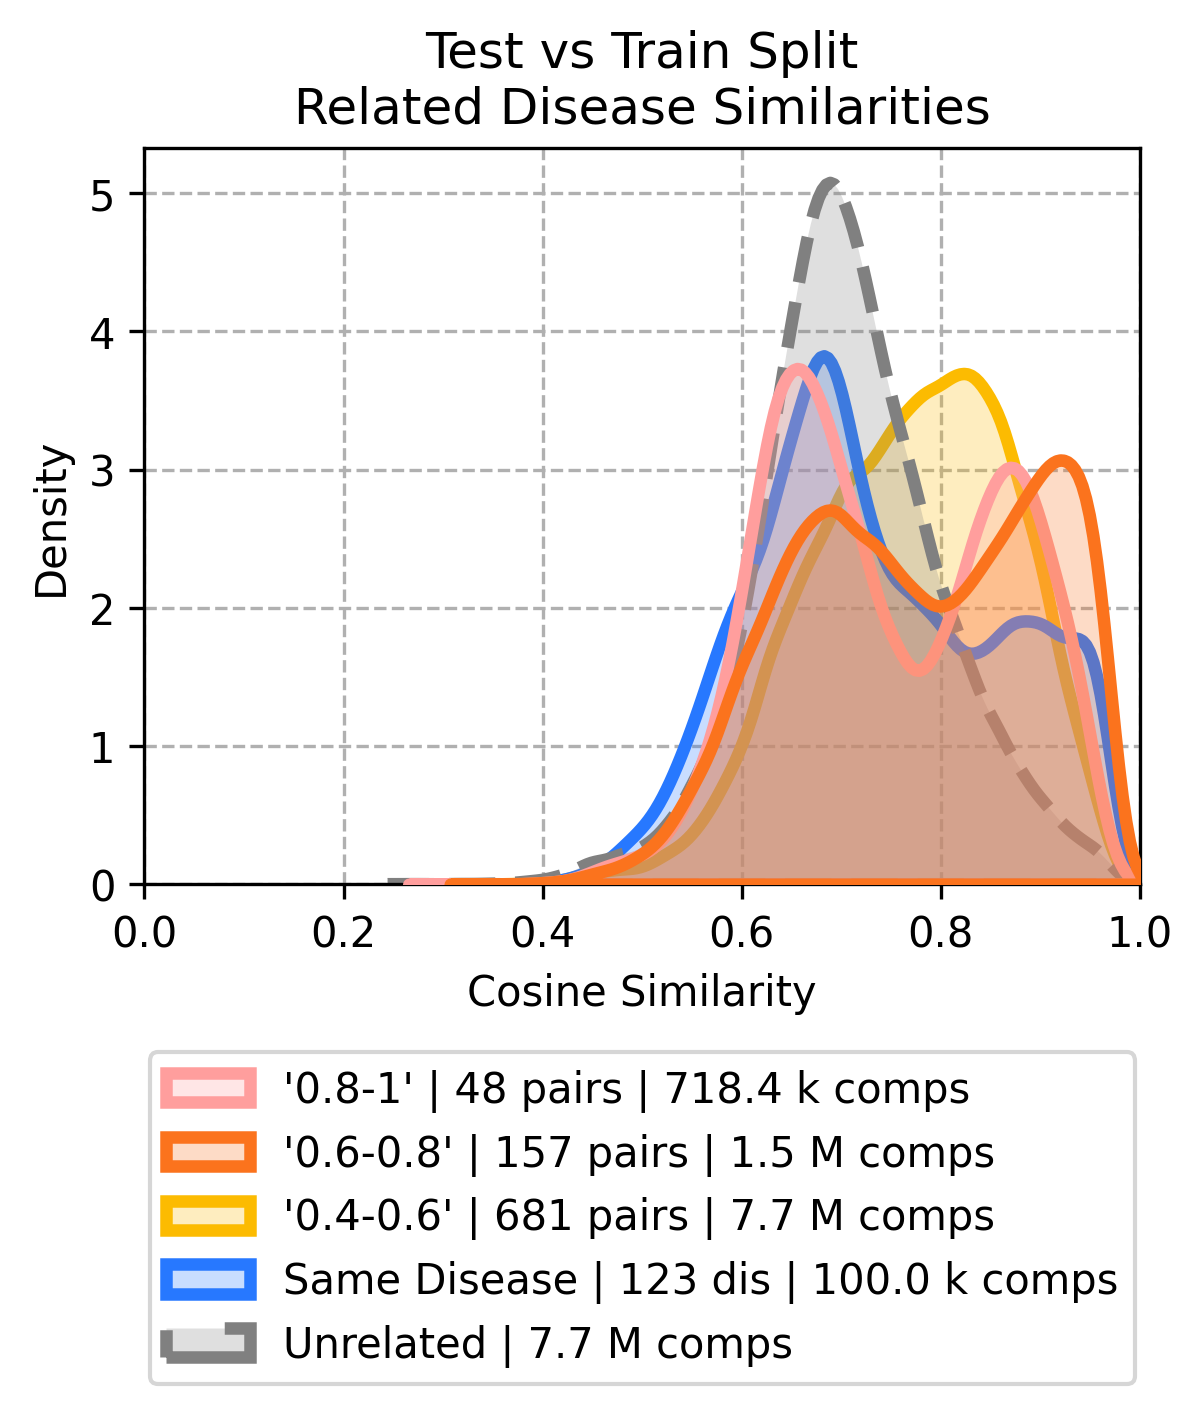

Nº of positive disease pairs: 718441
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 1495784
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 7693981
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000


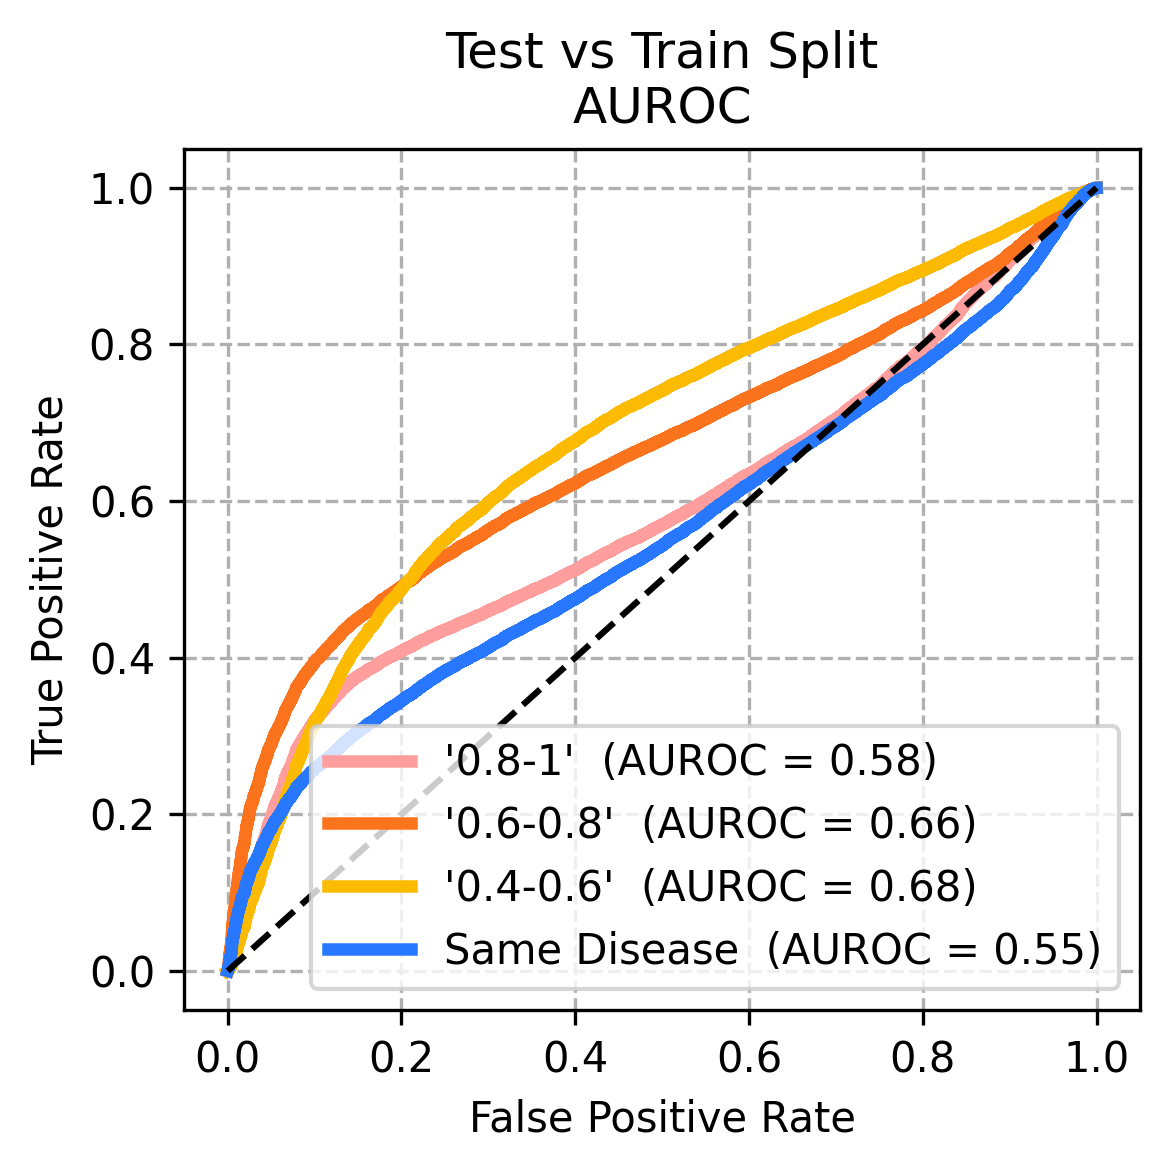

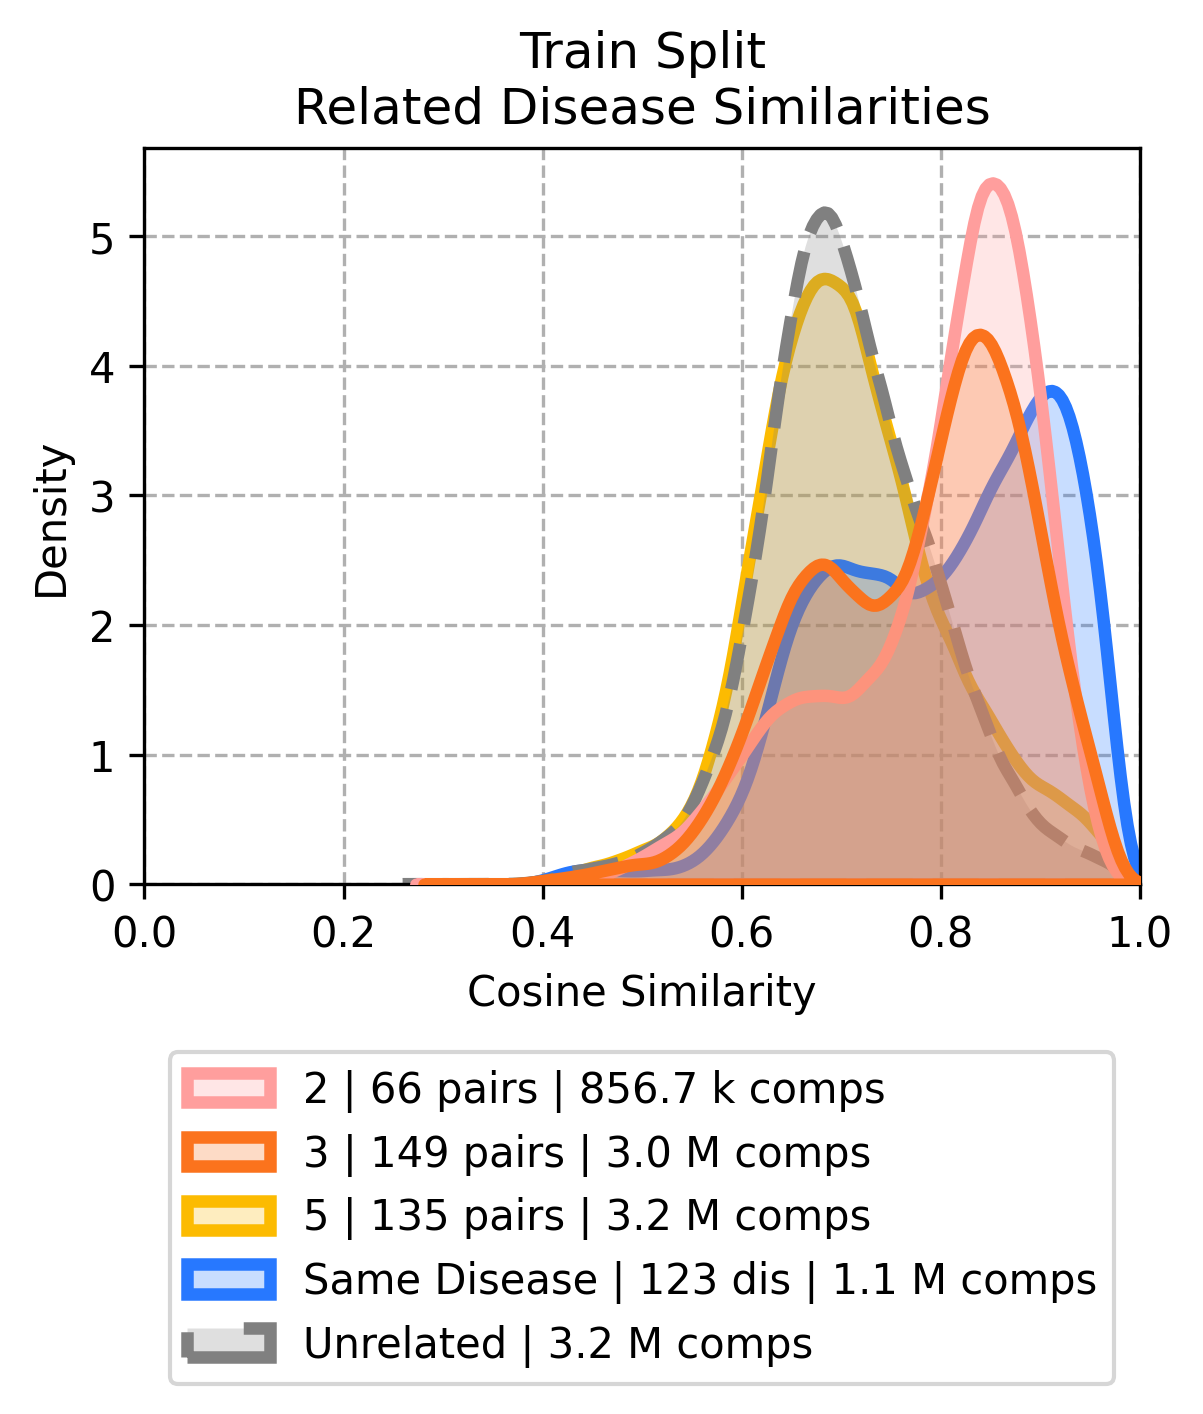

Nº of positive disease pairs: 856721
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 3020662
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 3181675
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 1058984
Nº of positive disease pairs: 100000


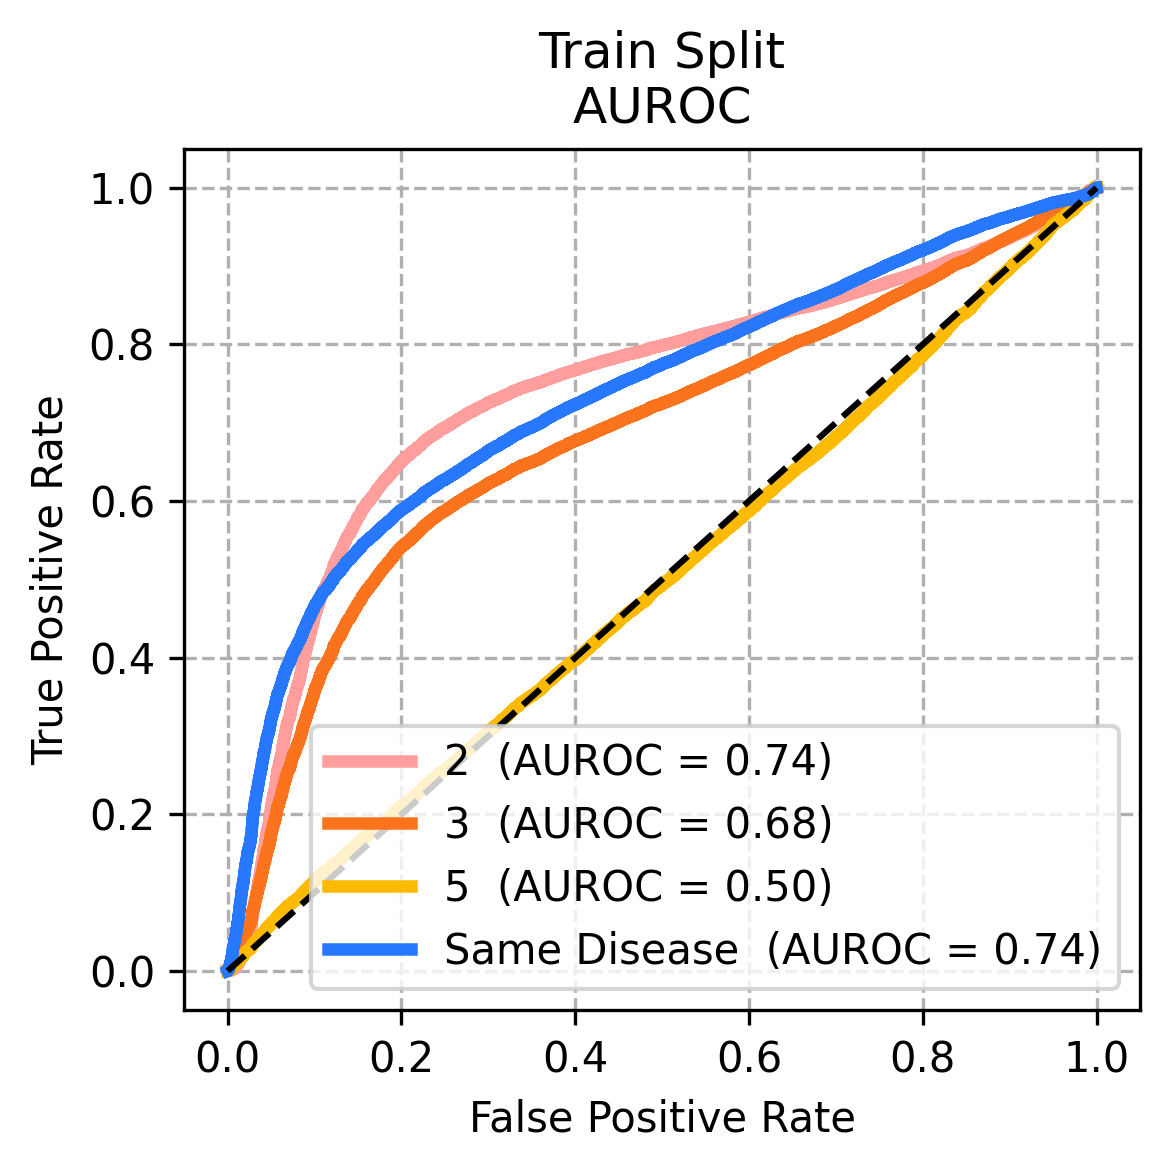

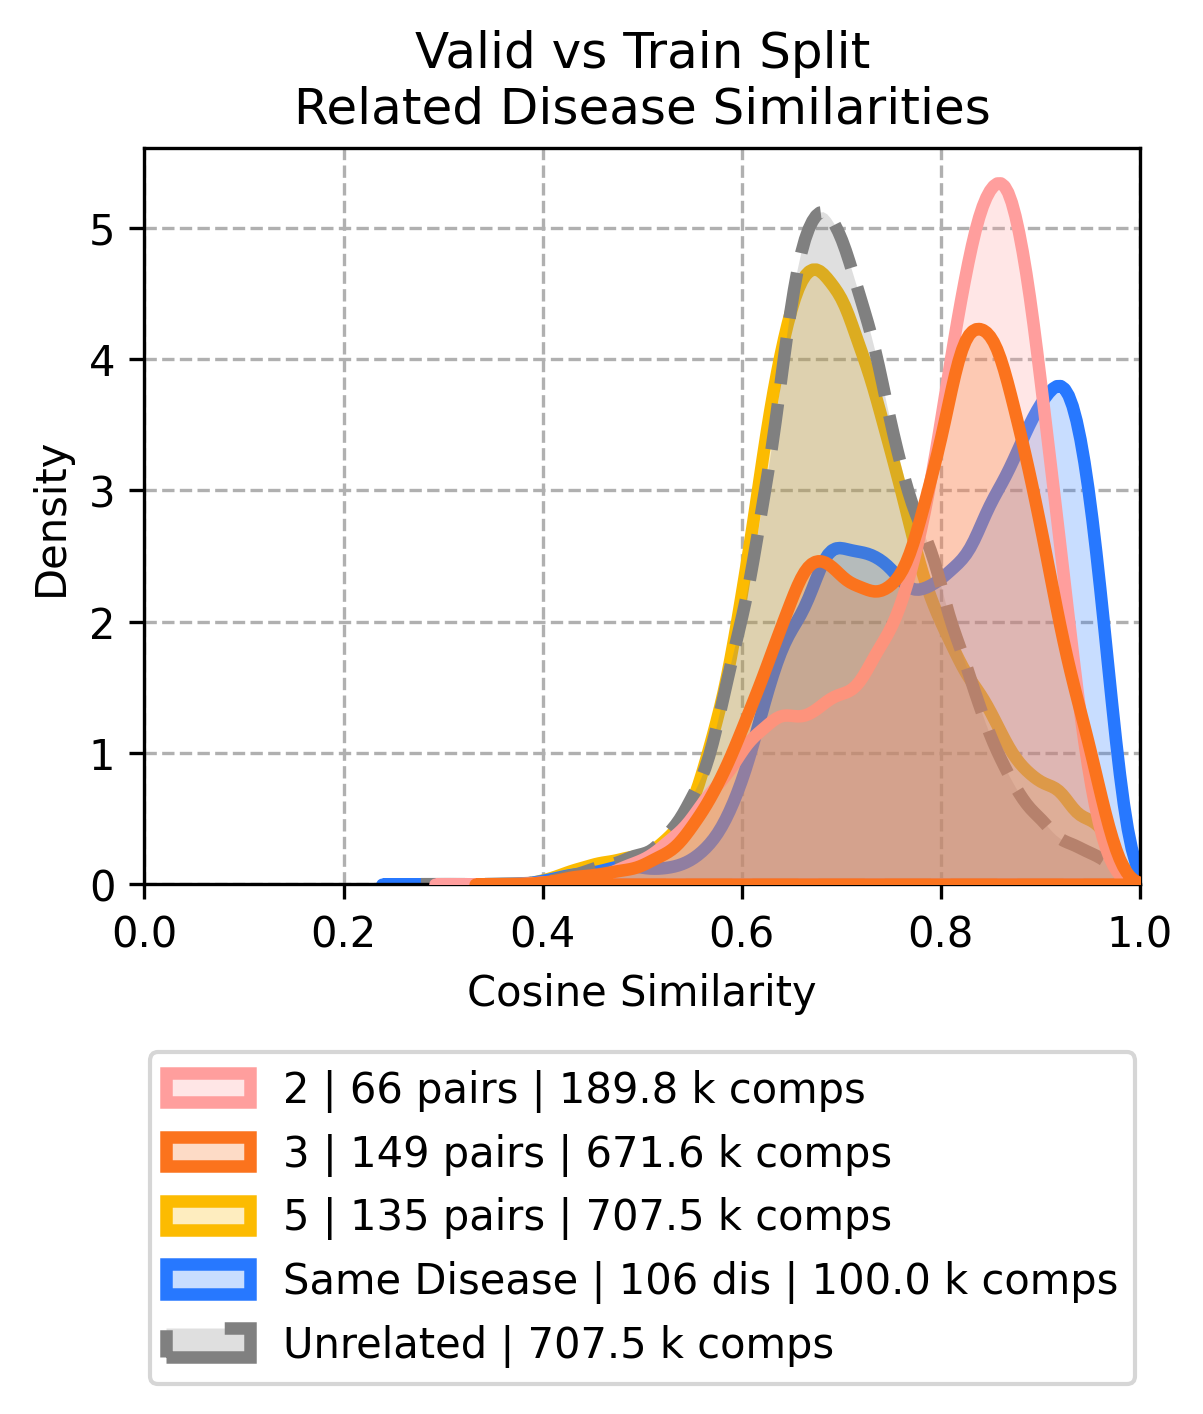

Nº of positive disease pairs: 189794
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 671561
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 707461
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000


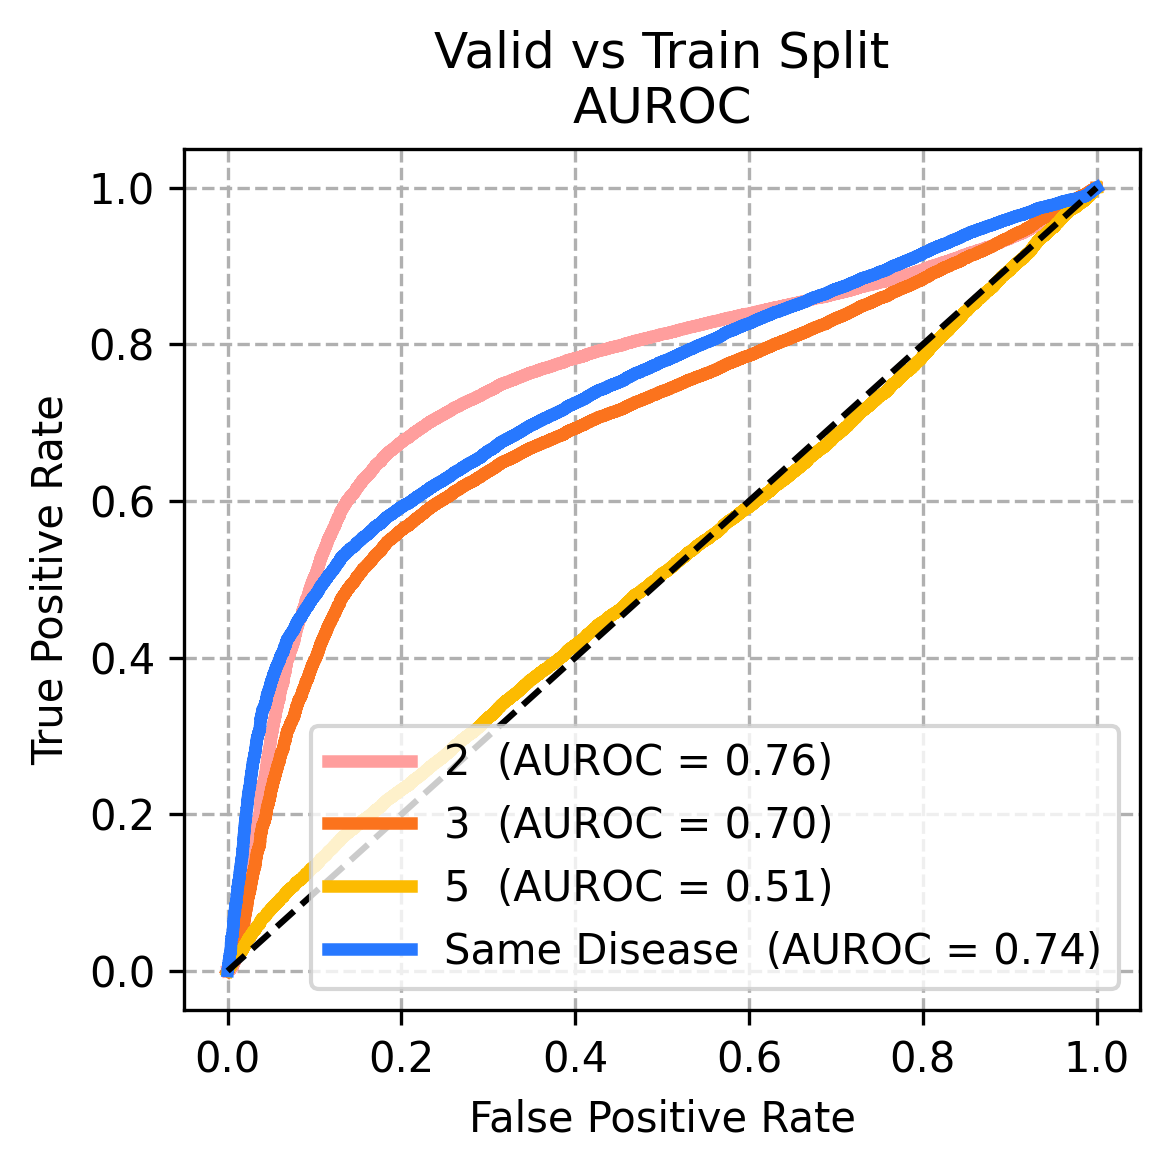

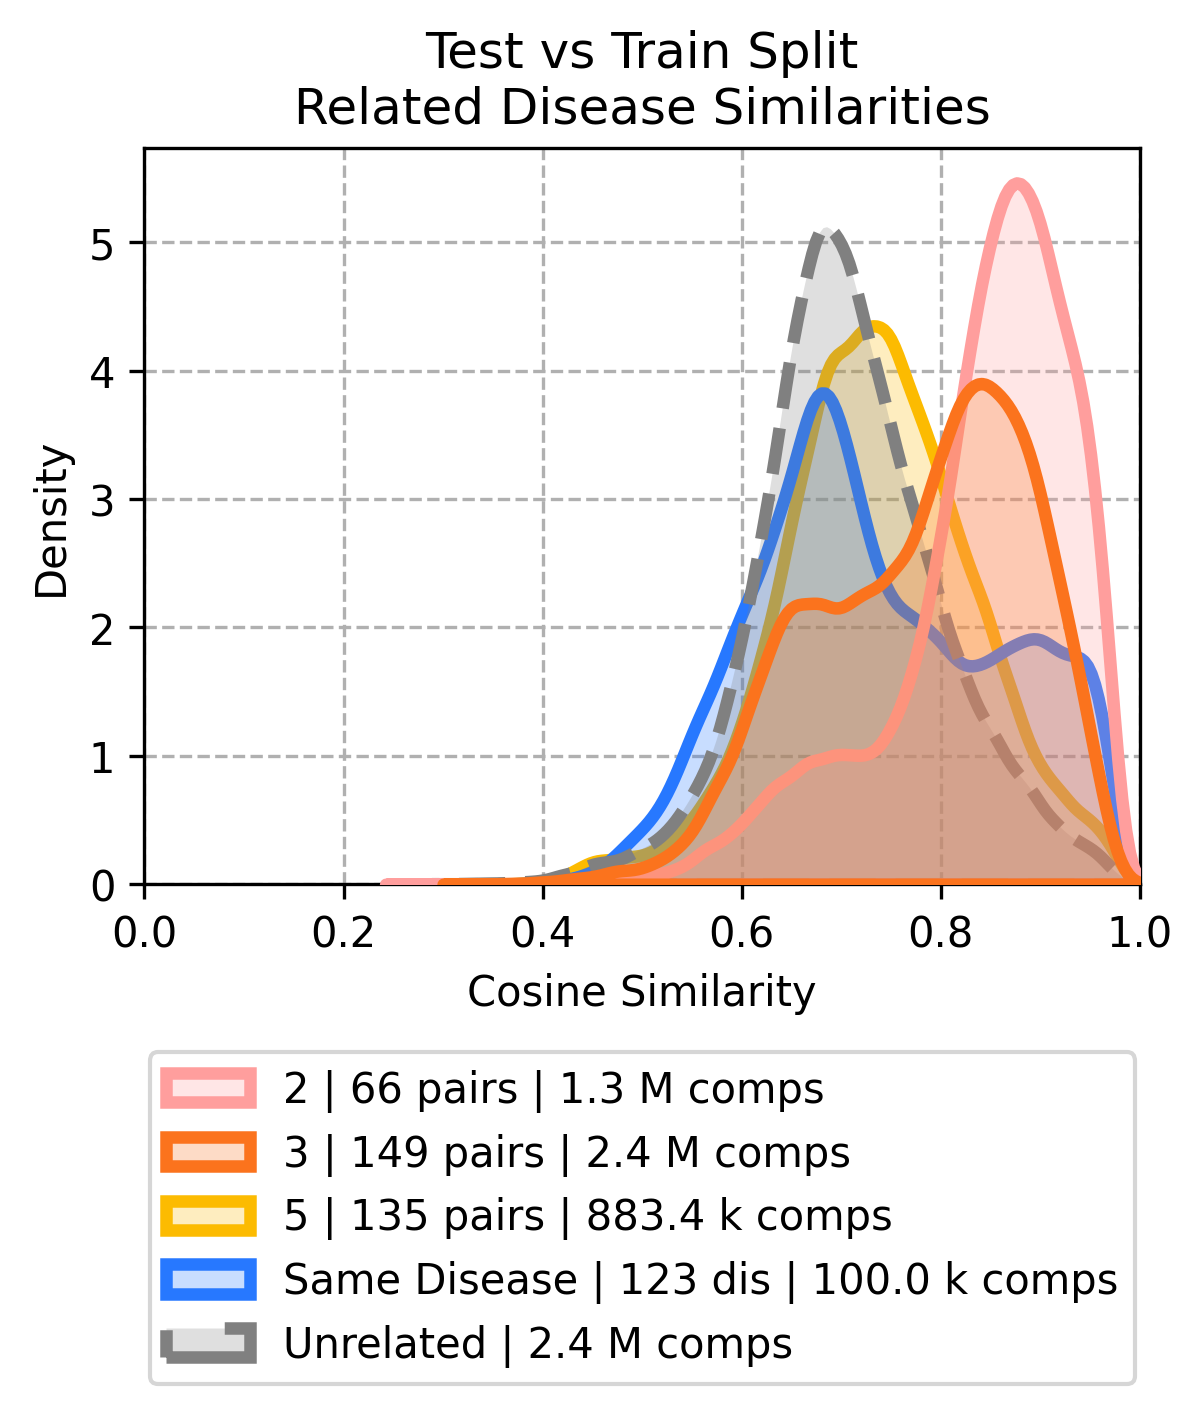

Nº of positive disease pairs: 1337222
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 2358085
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 883370
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000


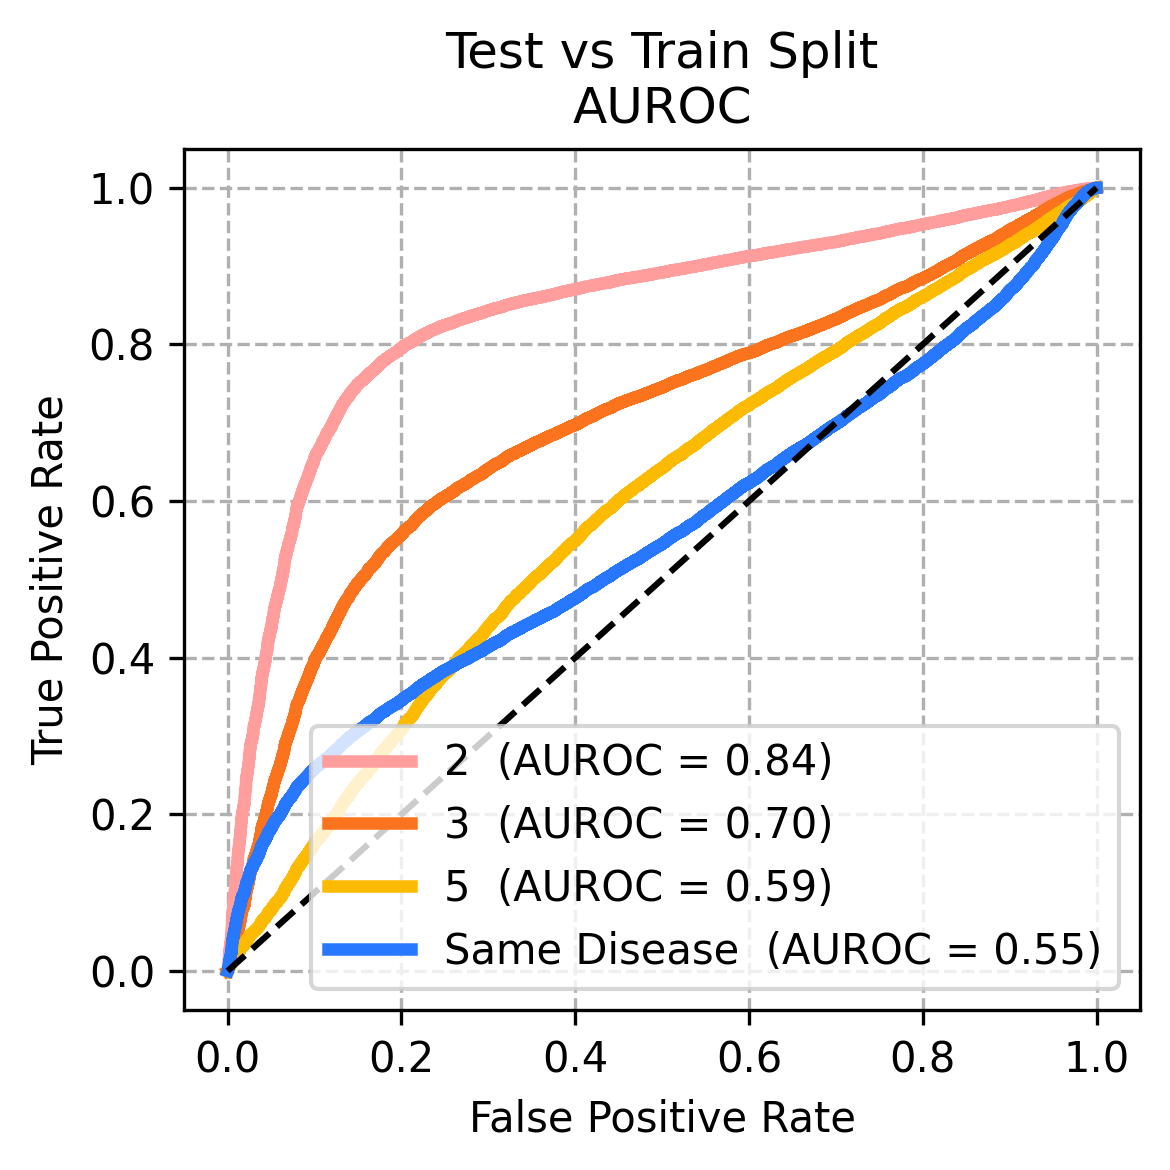

In [68]:
dpi_val = 300
colors_val=["#ff9e9d", "#fb731d", "#fcbb01","#2778ff","grey"]
# plot
# Type 1
# train
vz.plot_kde(tr_s_all_1, labels=tr_l_all_1, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_train_1.png"))
vz.plot_roc(tr_s_all_1[:-1], tr_s_unr, labels=tr_l_all_1, title="Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-roc_train_1.png"))


# validation
vz.plot_kde(vl_s_all_1, labels=vl_l_all_1, colors=colors_val, title="Valid vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_valid_1.png"))
vz.plot_roc(vl_s_all_1[:-1], vl_s_unr, labels=vl_l_all_1, title="Valid vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-roc_valid_1.png"))

# test
vz.plot_kde(ts_s_all_1, labels=ts_l_all_1, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_test_1.png"))
vz.plot_roc(ts_s_all_1[:-1], ts_s_unr, labels=ts_l_all_1, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-roc_test_1.png"))


# Type 2
# train
vz.plot_kde(tr_s_all_2, labels=tr_l_all_2, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_train_2.png"))
vz.plot_roc(tr_s_all_2[:-1], tr_s_unr, labels=tr_l_all_2, title="Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-roc_train_2.png"))

# validation
vz.plot_kde(vl_s_all_2, labels=vl_l_all_2, colors=colors_val, title="Valid vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_valid_2.png"))
vz.plot_roc(vl_s_all_2[:-1], vl_s_unr, labels=vl_l_all_2, title="Valid vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-roc_valid_2.png"))

# test
vz.plot_kde(ts_s_all_2, labels=ts_l_all_2, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-kde_test_2.png"))
vz.plot_roc(ts_s_all_2[:-1], ts_s_unr, labels=ts_l_all_2, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, f"{embedding_type}-roc_test_2.png"))

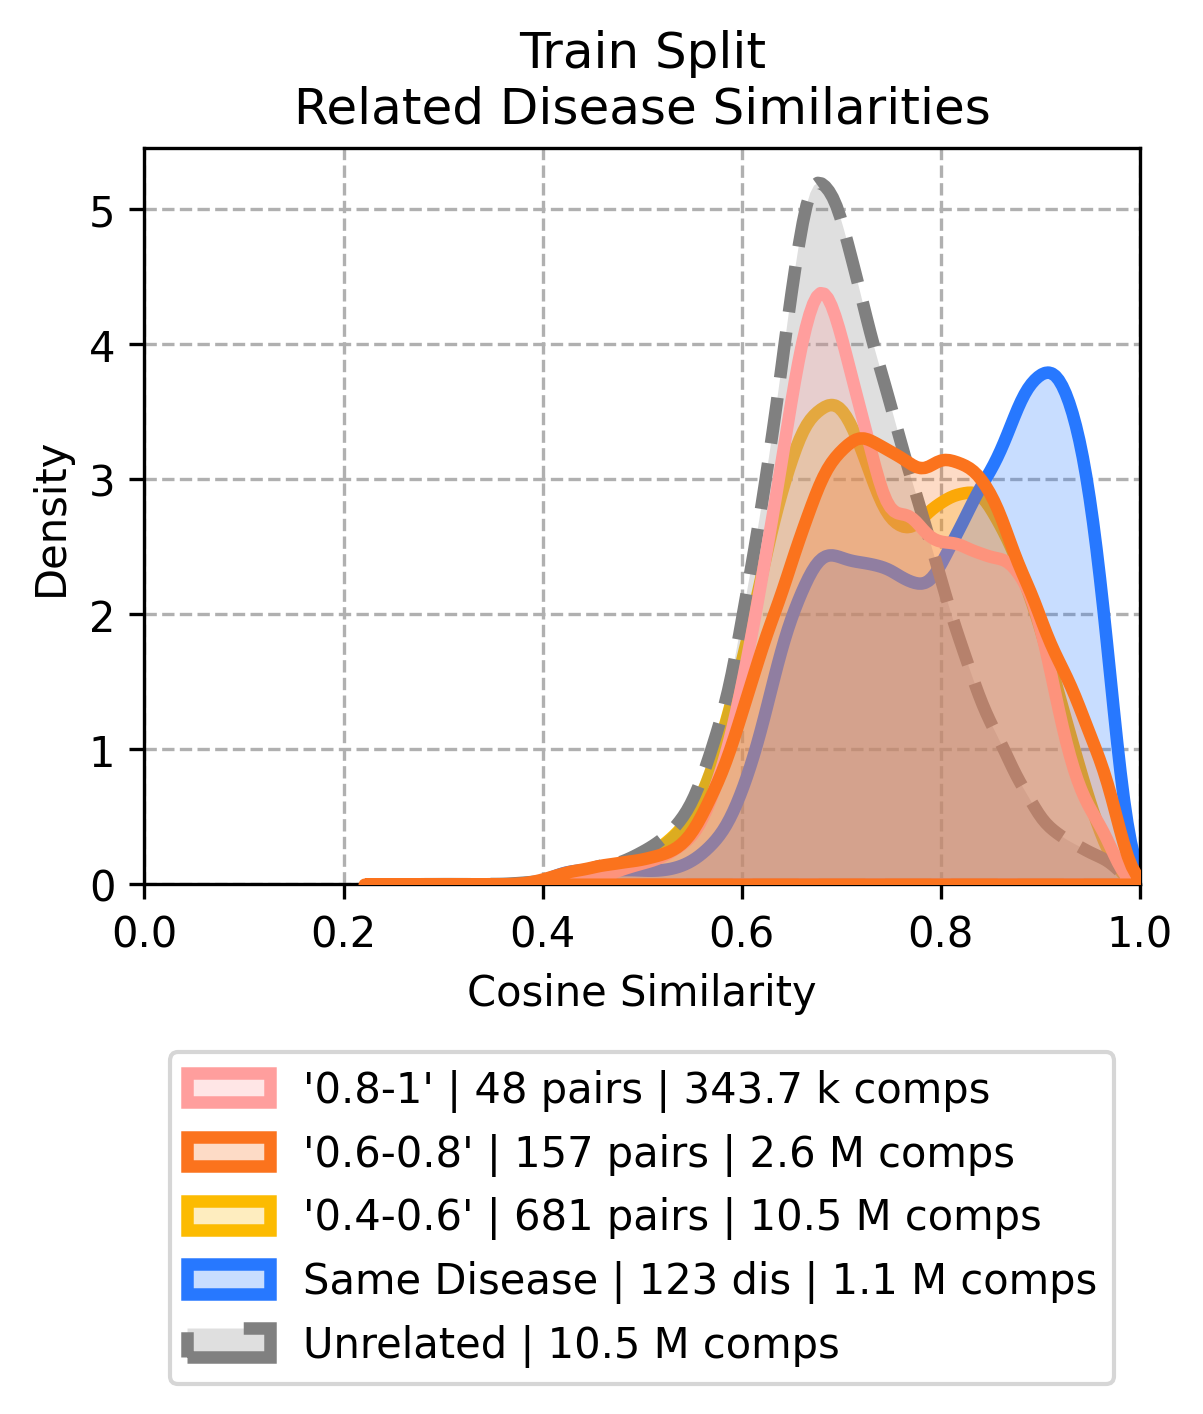

Nº of positive disease pairs: 343652
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 2635019
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 10454837
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 1058984
Nº of positive disease pairs: 100000


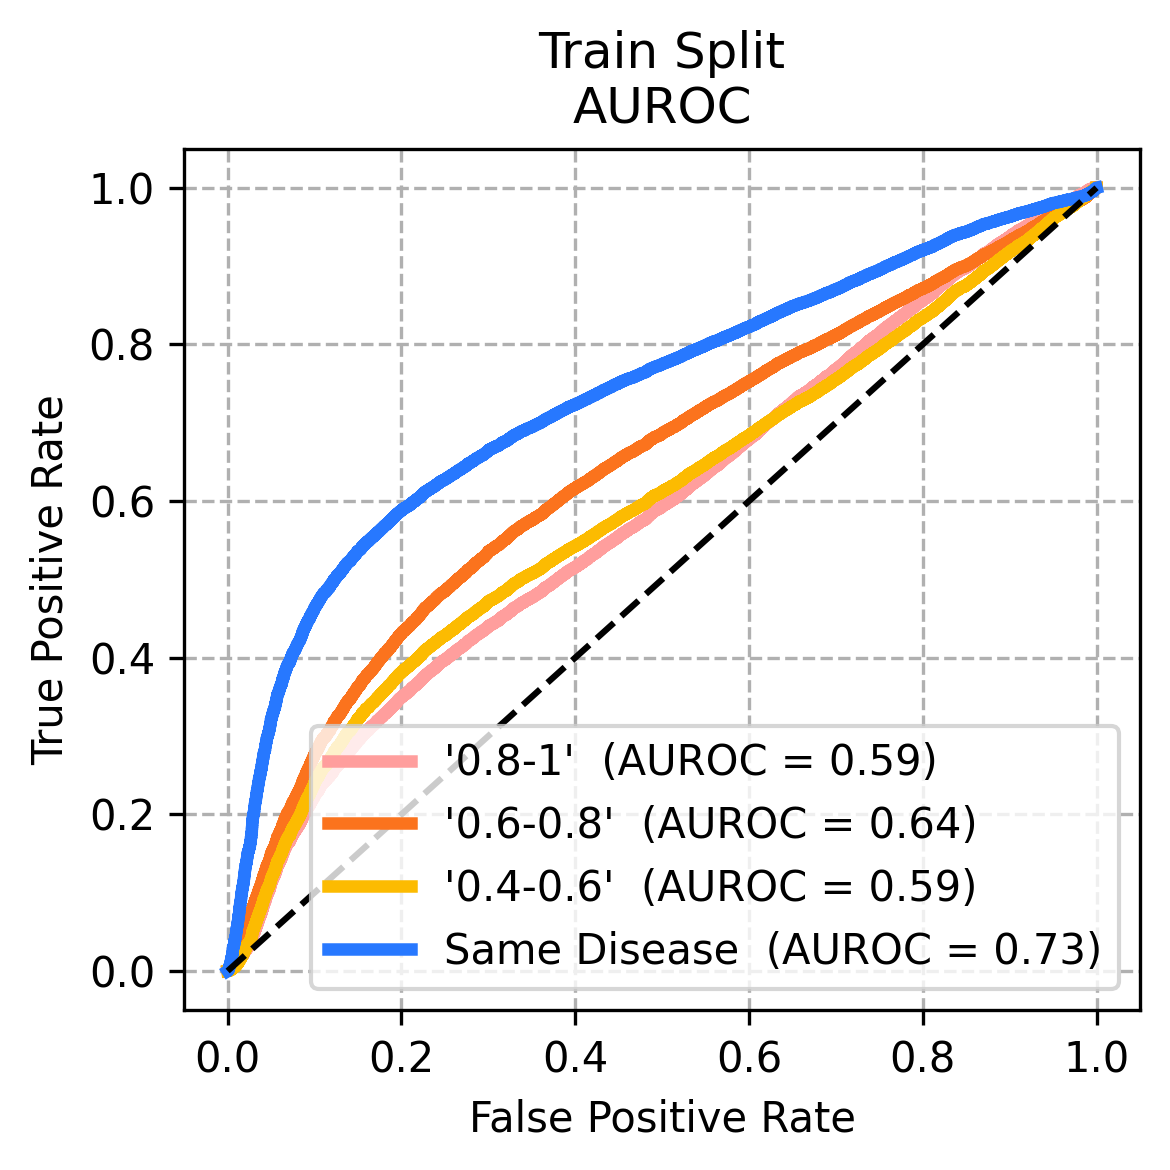

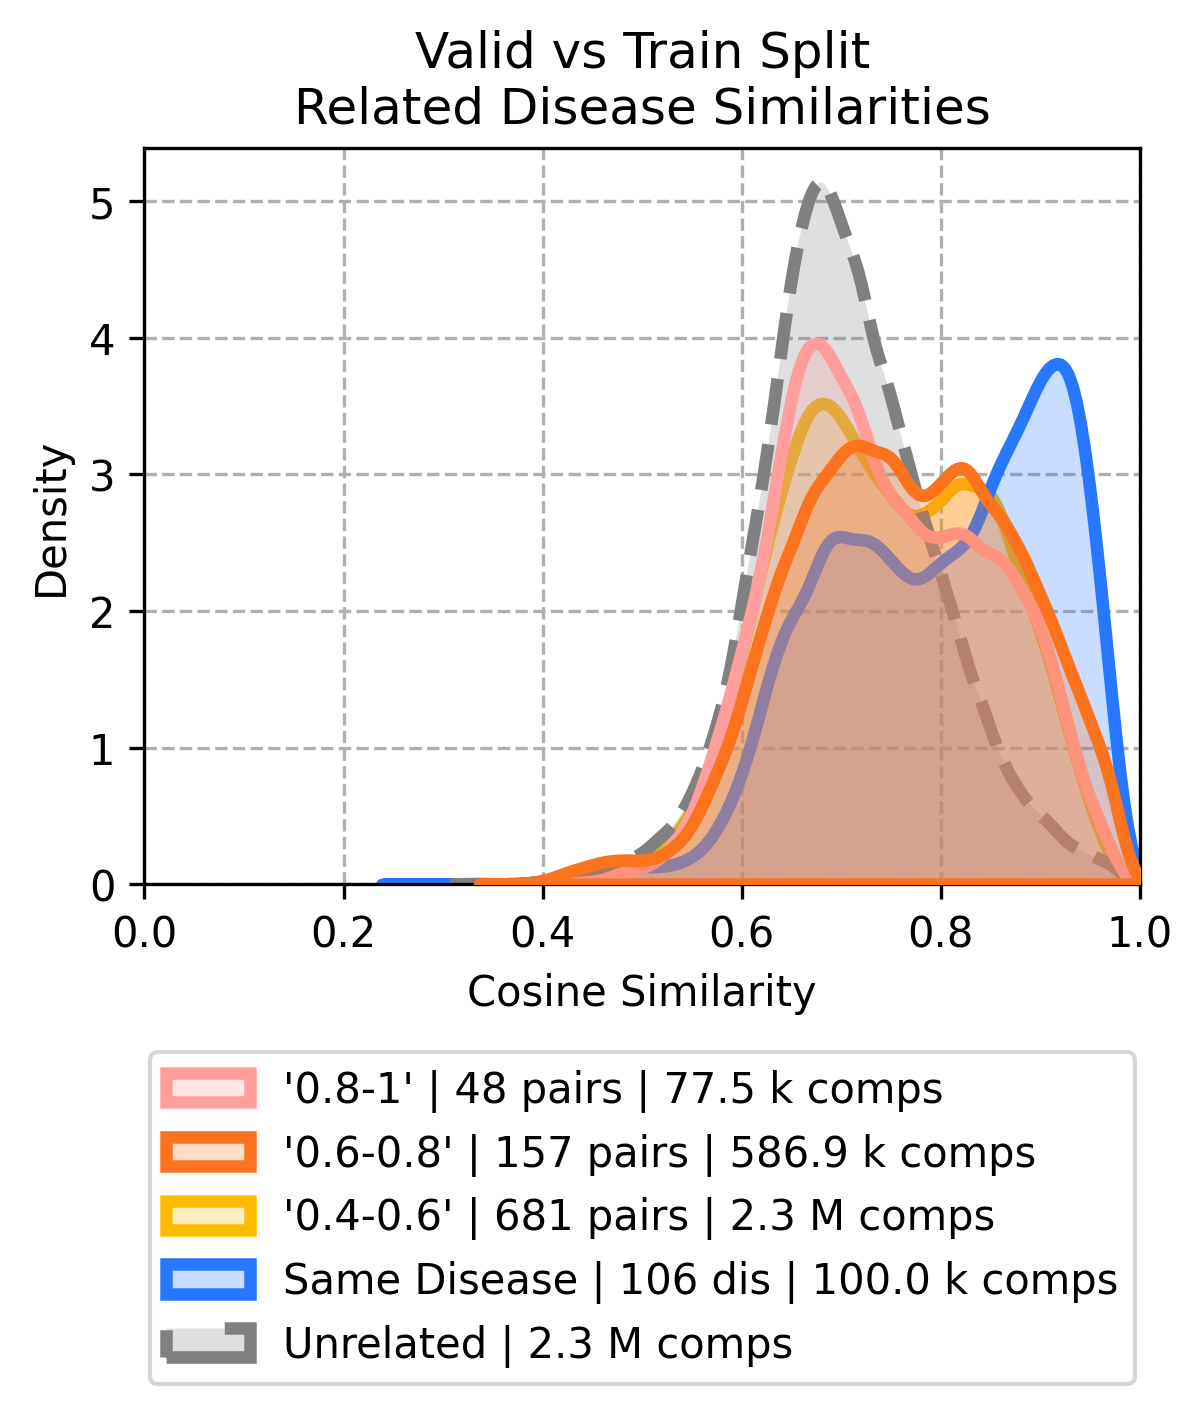

Nº of positive disease pairs: 77535
Nº of positive disease pairs: 77535
Nº of positive disease pairs: 586910
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 2328516
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000


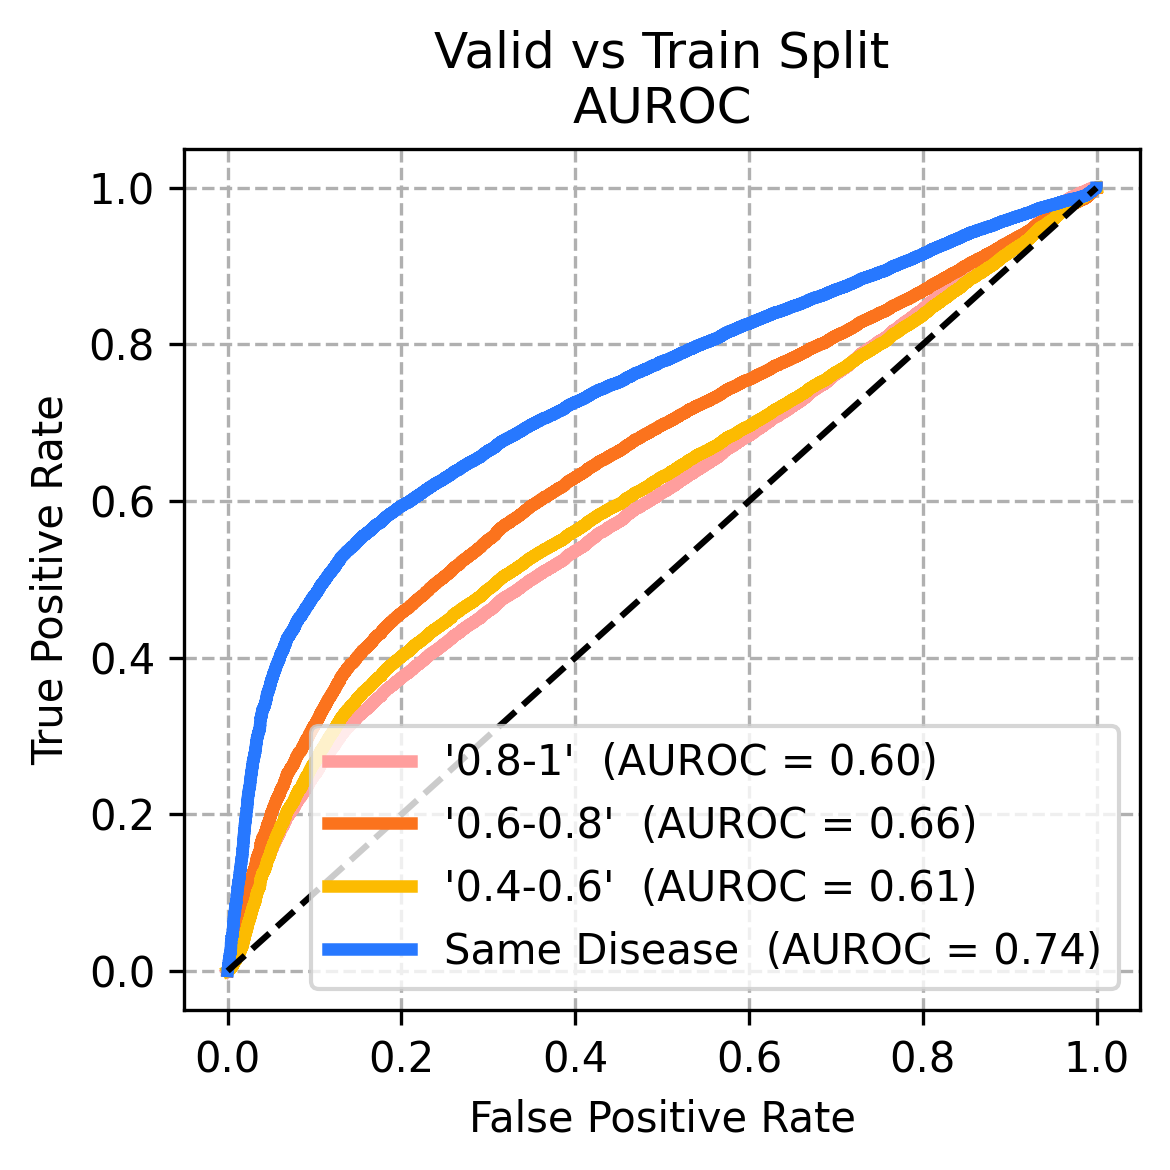

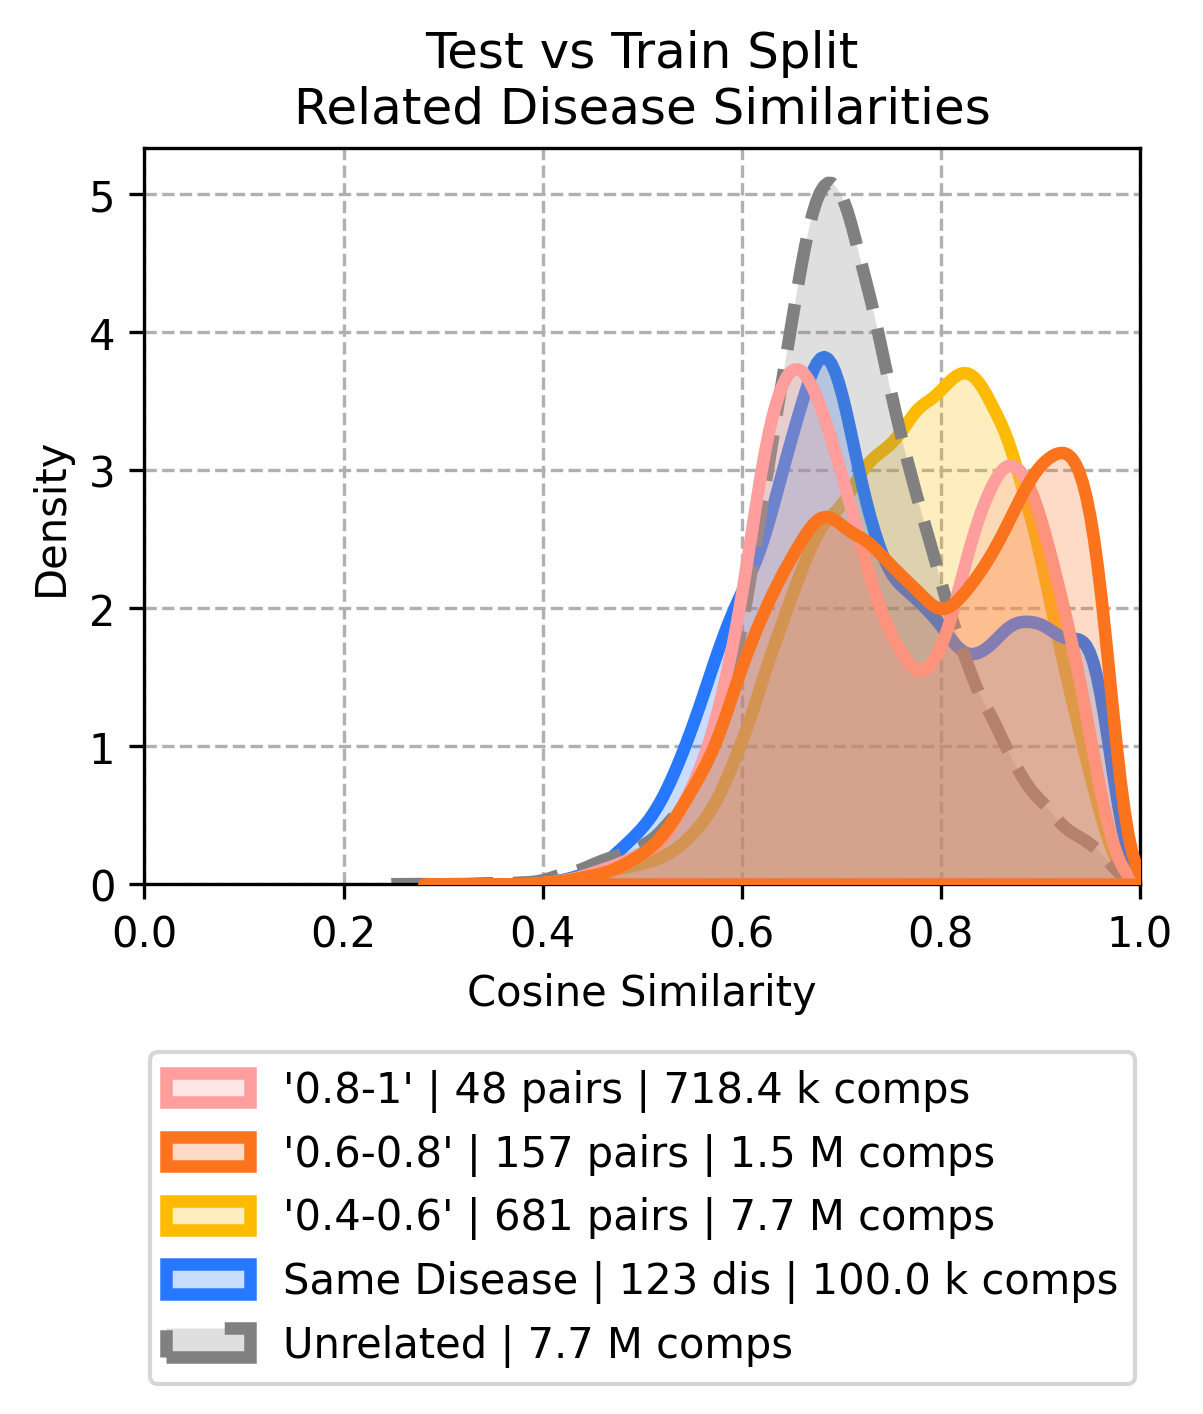

Nº of positive disease pairs: 718441
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 1495784
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 7693981
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000


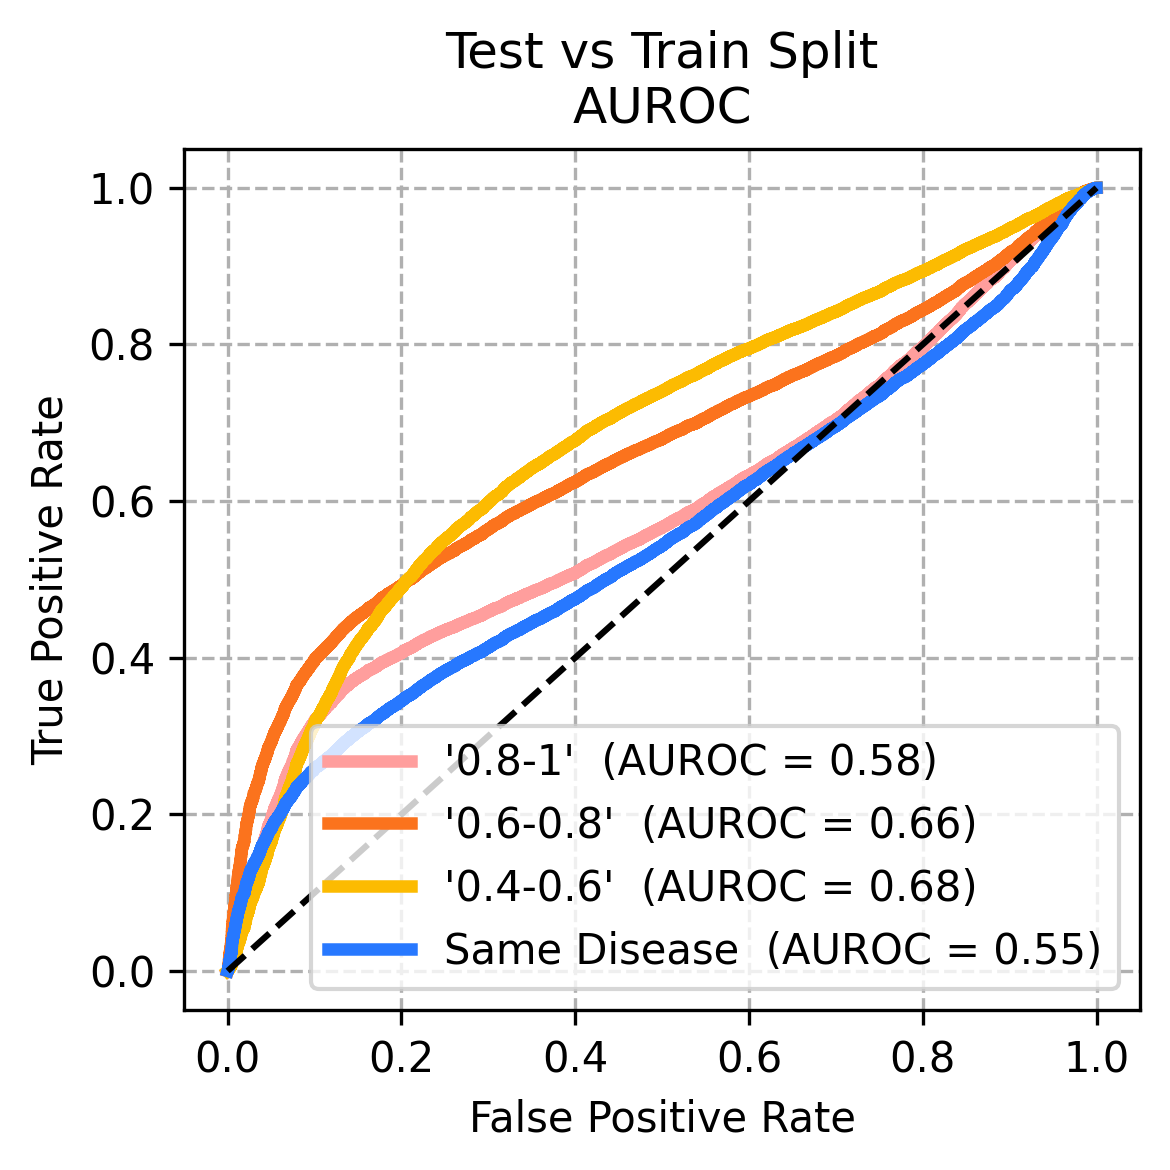

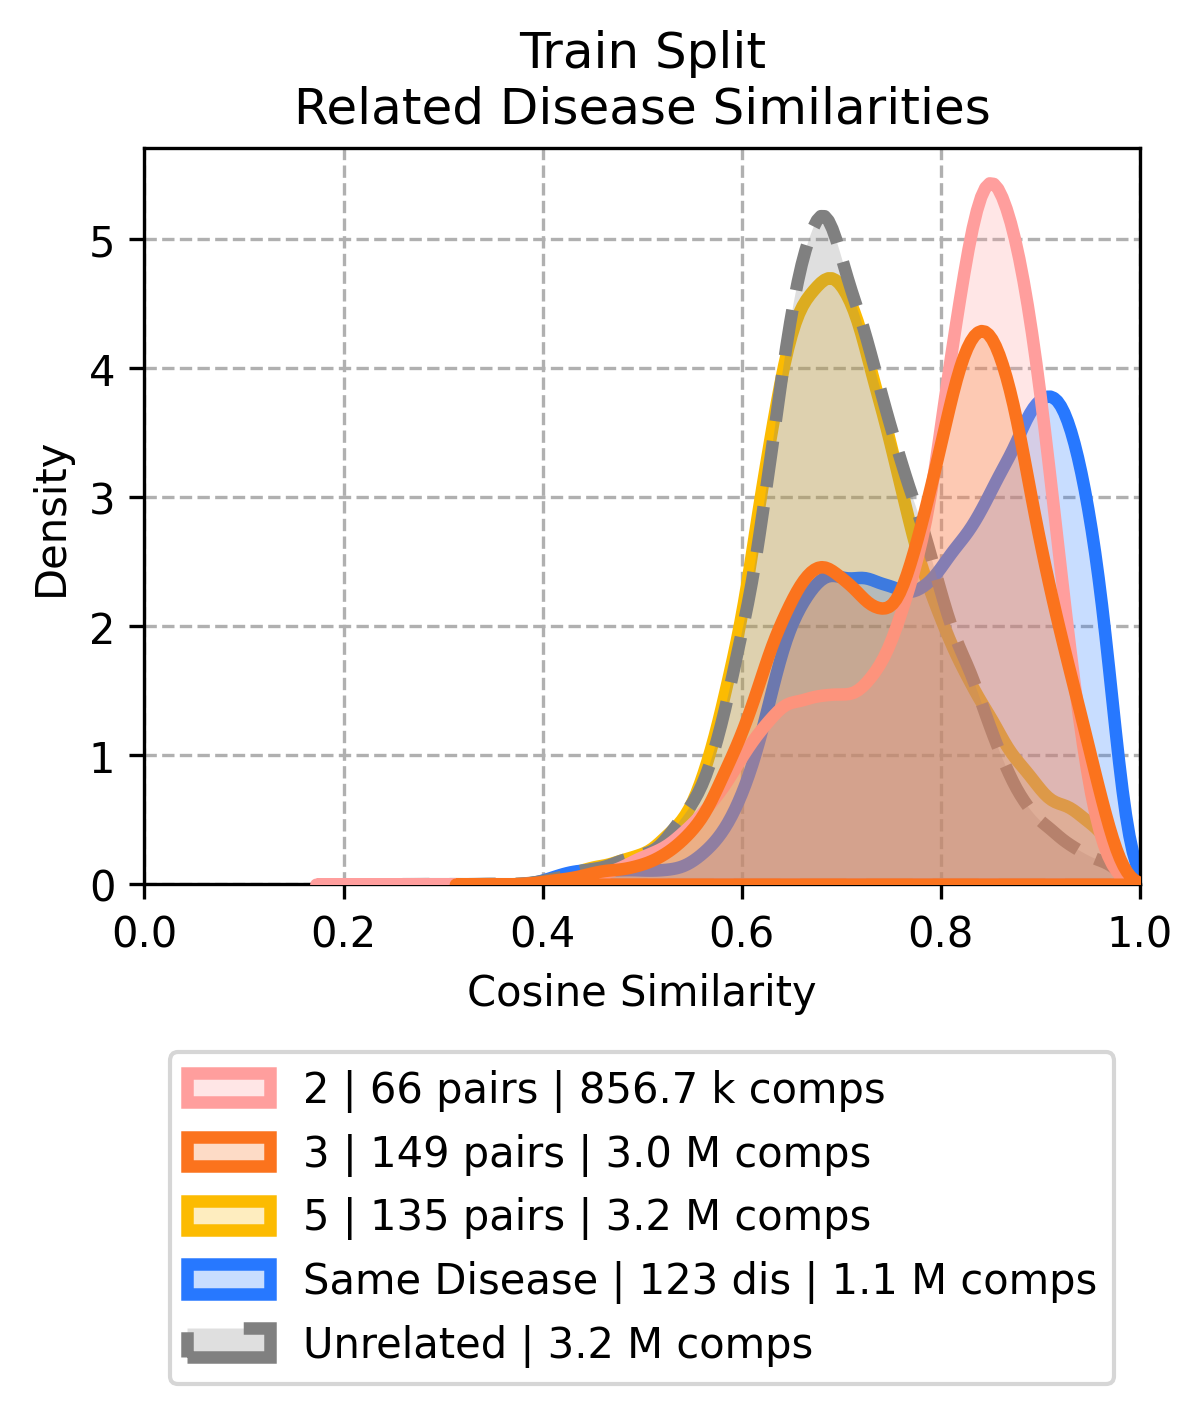

Nº of positive disease pairs: 856721
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 3020662
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 3181675
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 1058984
Nº of positive disease pairs: 100000


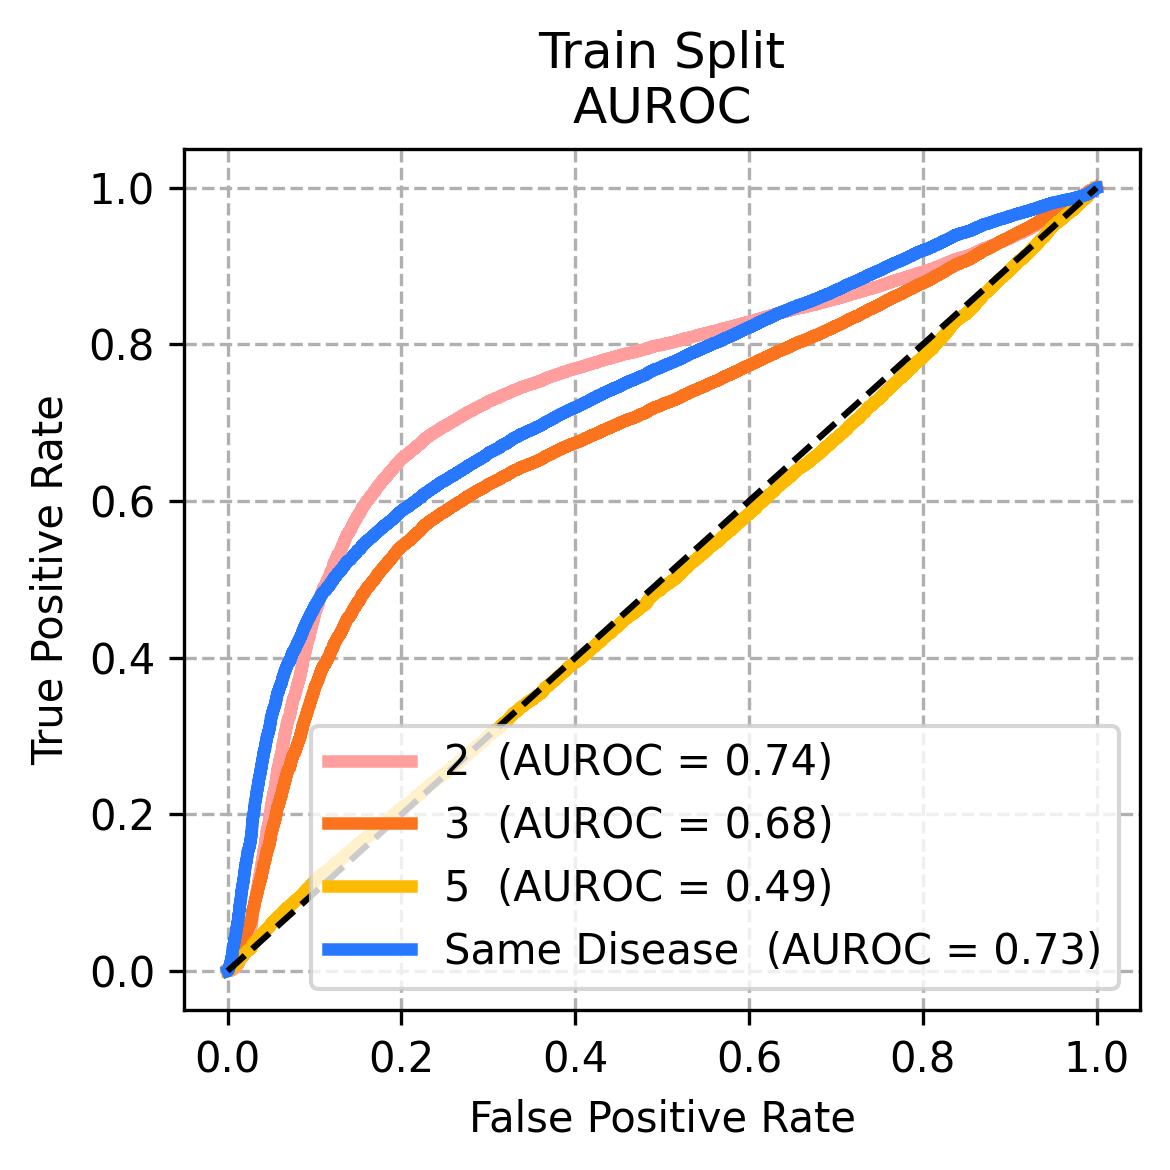

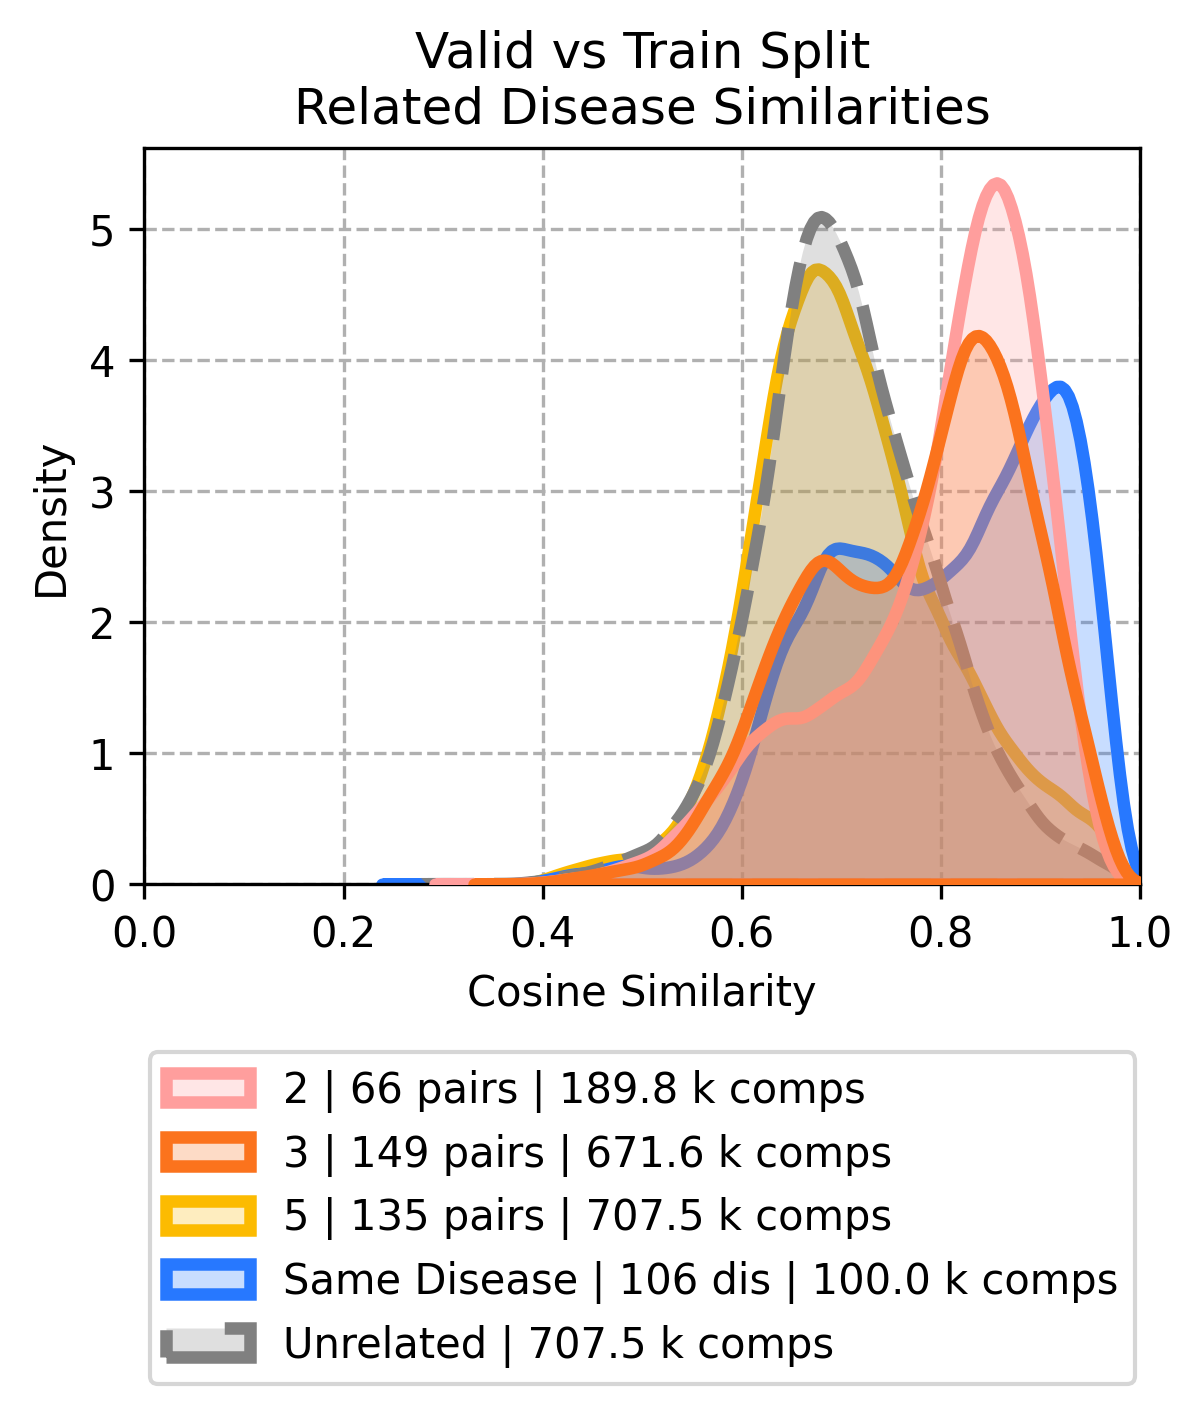

Nº of positive disease pairs: 189794
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 671561
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 707461
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000


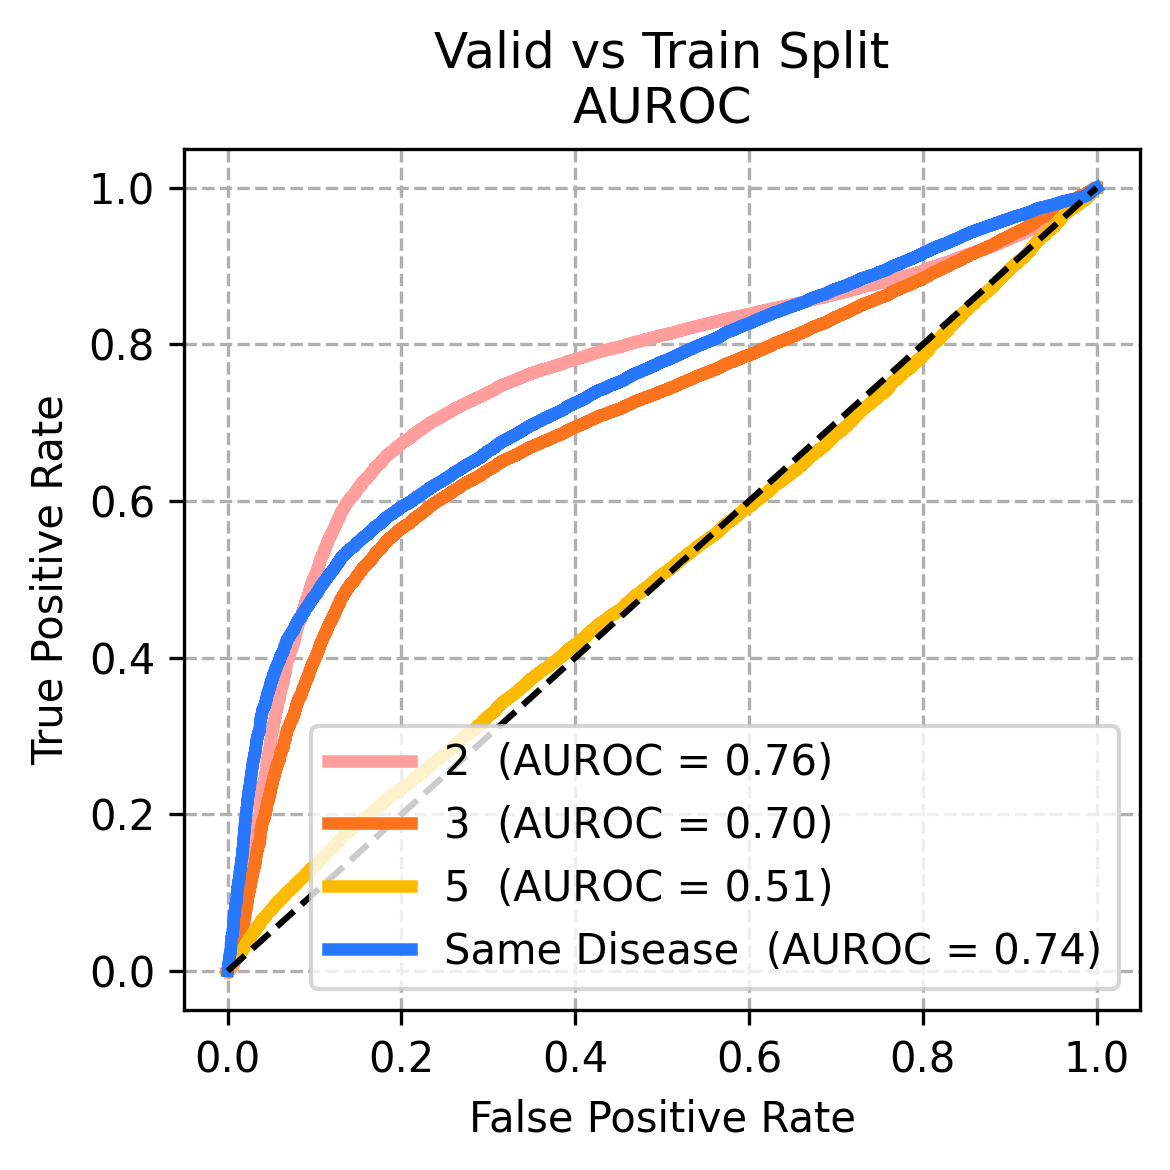

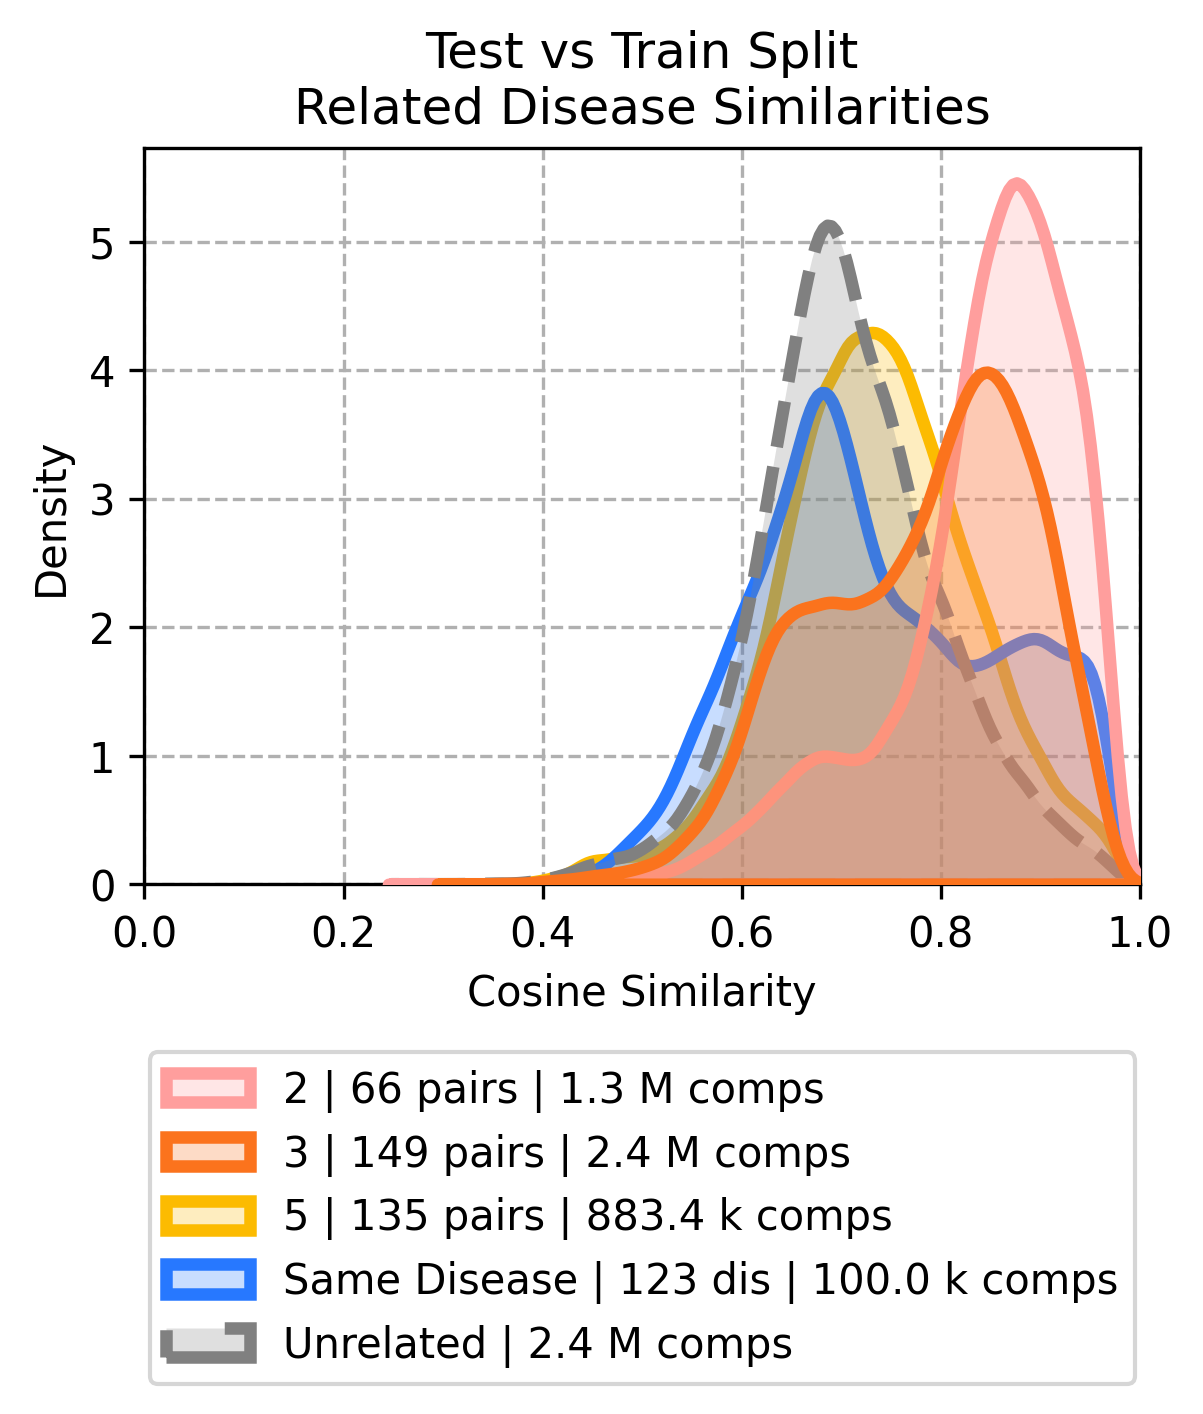

Nº of positive disease pairs: 1337222
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 2358085
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 883370
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000


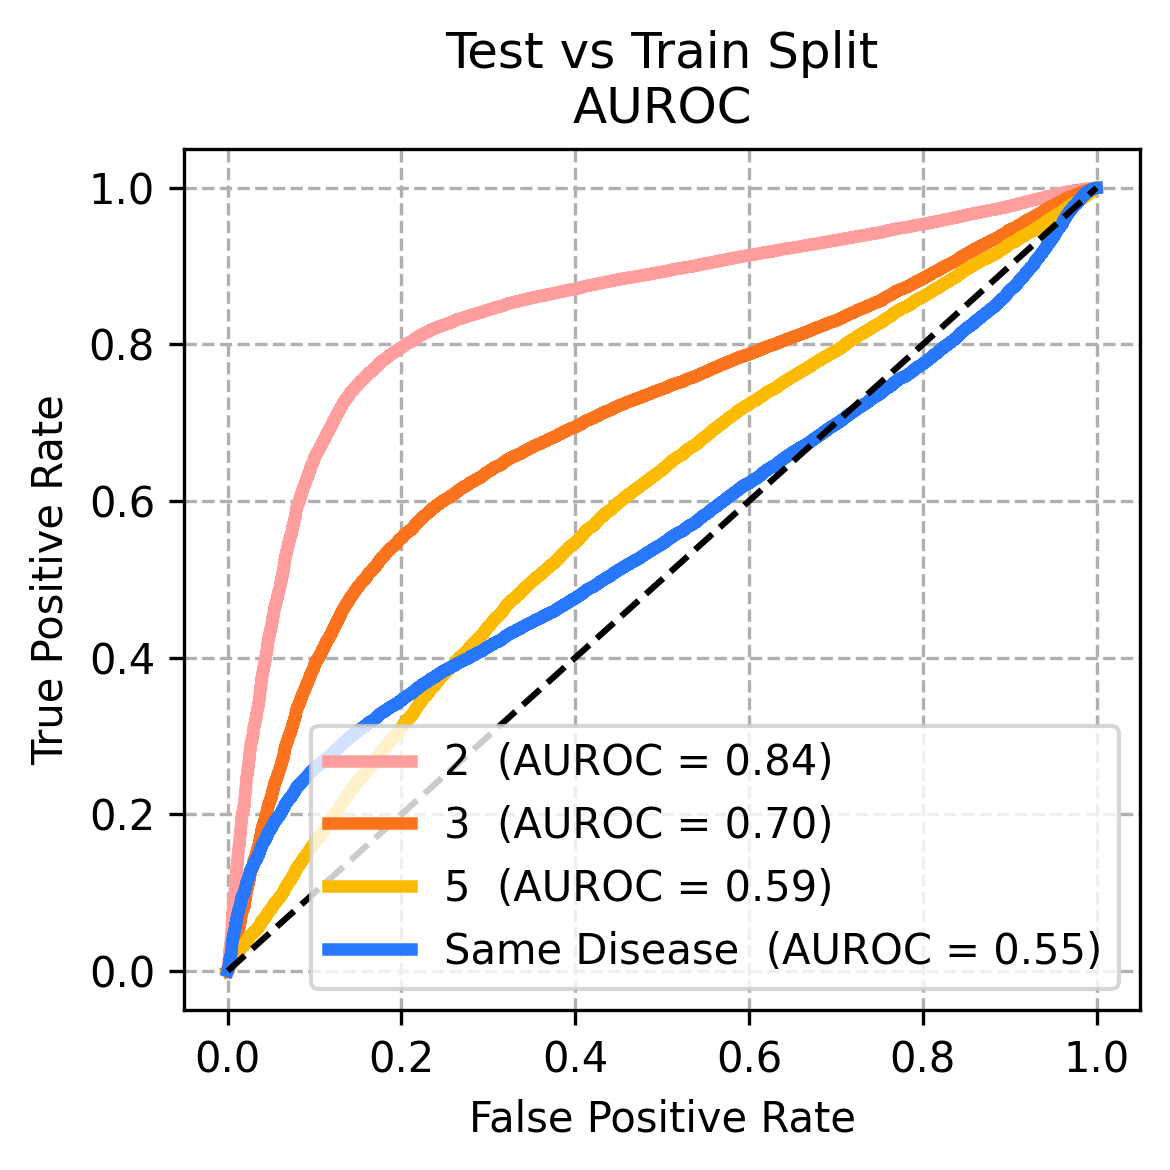

In [69]:
# weighted
#! WEIGHTED ADD

dpi_val = 300
colors_val=["#ff9e9d", "#fb731d", "#fcbb01","#2778ff","grey"]
# plot
# Type 1
# train
vz.plot_kde(tr_s_all_1, labels=tr_l_all_1, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "kde_train_1.png"))
vz.plot_roc(tr_s_all_1[:-1], tr_s_unr, labels=tr_l_all_1, title="Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "roc_train_1.png"))


# validation
vz.plot_kde(vl_s_all_1, labels=vl_l_all_1, colors=colors_val, title="Valid vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "kde_valid_1.png"))
vz.plot_roc(vl_s_all_1[:-1], vl_s_unr, labels=vl_l_all_1, title="Valid vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "roc_valid_1.png"))

# test
vz.plot_kde(ts_s_all_1, labels=ts_l_all_1, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "kde_test_1.png"))
vz.plot_roc(ts_s_all_1[:-1], ts_s_unr, labels=ts_l_all_1, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "roc_test_1.png"))

# Type 2
# train
vz.plot_kde(tr_s_all_2, labels=tr_l_all_2, colors=colors_val, title="Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "kde_train_2.png"))
vz.plot_roc(tr_s_all_2[:-1], tr_s_unr, labels=tr_l_all_2, title="Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "roc_train_2.png"))

# validation
vz.plot_kde(vl_s_all_2, labels=vl_l_all_2, colors=colors_val, title="Valid vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "kde_valid_2.png"))
vz.plot_roc(vl_s_all_2[:-1], vl_s_unr, labels=vl_l_all_2, title="Valid vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "roc_valid_2.png"))

# test
vz.plot_kde(ts_s_all_2, labels=ts_l_all_2, colors=colors_val, title="Test vs Train Split\nRelated Disease Similarities", metric="Cosine", weights=None, sample=sample_size, dpi=dpi_val, output_dir=os.path.join(output_dir, "kde_test_2.png"))
vz.plot_roc(ts_s_all_2[:-1], ts_s_unr, labels=ts_l_all_2, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=None,sample=sample_size,dpi=dpi_val, output_dir=os.path.join(output_dir, "roc_test_2.png"))

Nº of positive disease pairs: 1337222
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 2358085
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 883370
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000
Nº of positive disease pairs: 100000


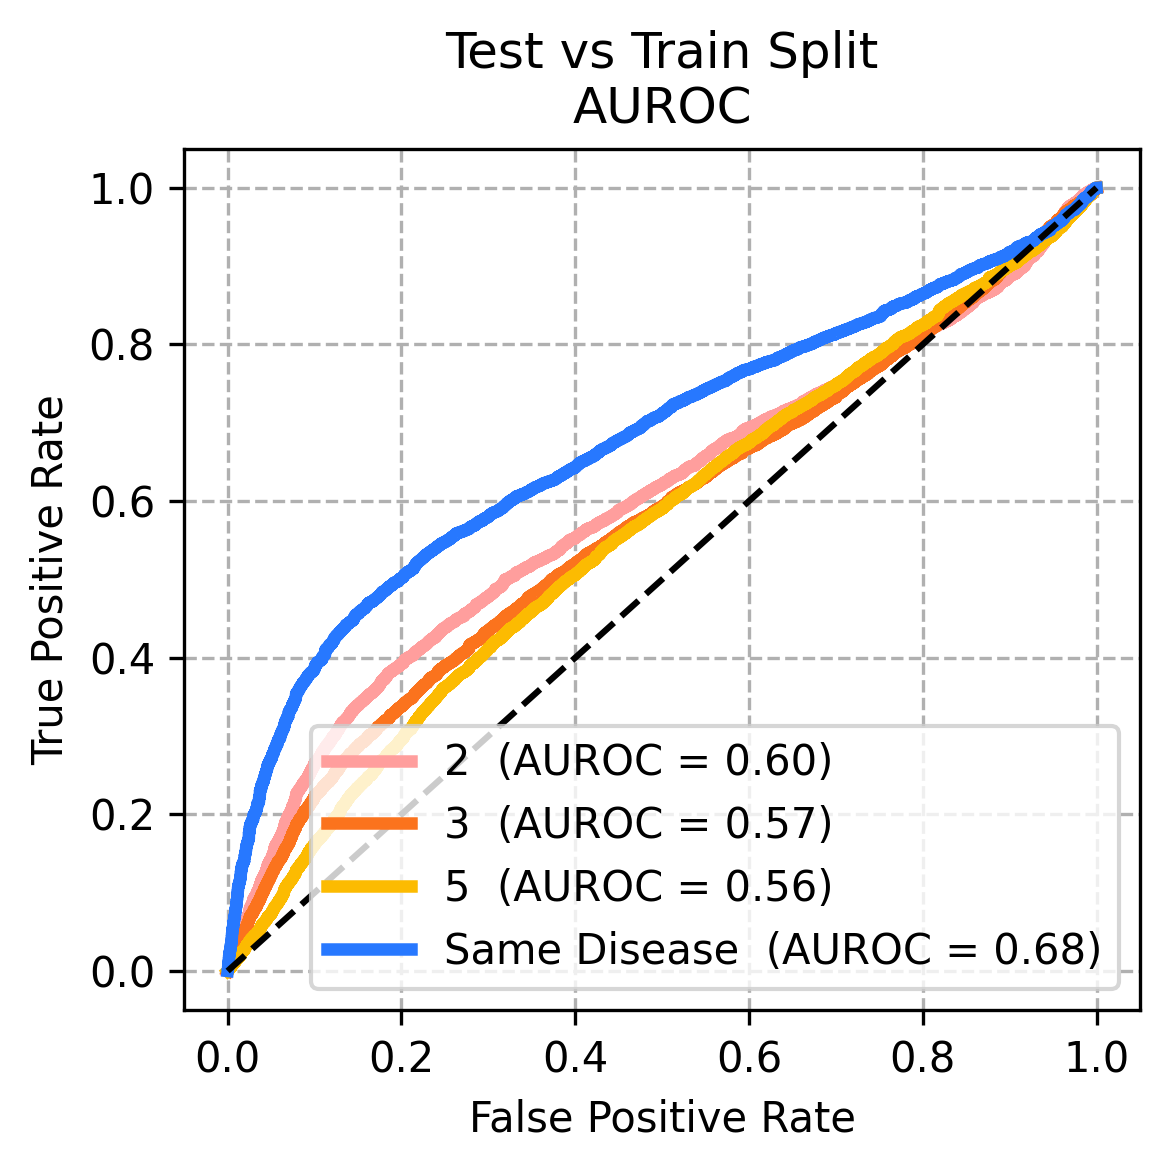

In [70]:
vz.plot_roc(ts_s_all_2[:-1], ts_s_unr, labels=ts_l_all_2, title="Test vs Train Split\nAUROC", colors=colors_val, w_pos=ts_w_all_2[:-1],sample=sample_size,dpi=dpi_val, output_dir=None)

## 3.2 AUROC tables

In [71]:
import pandas as pd

def _auroc(pos, neg):
    """Return only the AUROC from vz.get_roc(pos, neg)."""
    # both most be same size!
    # min_size = min(len(pos), len(neg))
    pos = np.array(pos)
    neg = np.array(neg)
    if len(pos)==0:
        return np.nan
    auroc, _, _ = vz.get_roc(pos, neg)
    return auroc

def make_auroc_row(split_name:str, s_same_diff:np.array, s_all_2:List, s_all_1:List,s_ctrl:np.array, s_unr:np.array, ndigits:int=3):
    """
    s_all_2: list/tuple length 3 (e.g., Related 2/3/4)
    s_all_1: list/tuple length 3 (e.g., bins 0.8–1, 0.6–0.8, 0.4–0.6)
    """
    return pd.DataFrame({
        "Split": [split_name],
        "Same Disease Diff Dataset": [round(_auroc(s_same_diff, s_unr),ndigits=ndigits)],
        "Related 2": [round(_auroc(s_all_2[0], s_unr),ndigits=ndigits)],
        "Related 3": [round(_auroc(s_all_2[1], s_unr),ndigits=ndigits)],
        "Related 5": [round(_auroc(s_all_2[2], s_unr),ndigits=ndigits)],
        "Related 0.8–1": [round(_auroc(s_all_1[0], s_unr),ndigits=ndigits)],
        "Related 0.6–0.8": [round(_auroc(s_all_1[1], s_unr),ndigits=ndigits)],
        "Related 0.4–0.6": [round(_auroc(s_all_1[2], s_unr),ndigits=ndigits)],
        "Control" : [round(_auroc(s_ctrl, s_unr),ndigits=ndigits)],
    })


#! IMPORTANT - HERE THE RANDOMS ARE BUILT USING UNRELATED DISEASES & THEIR CONTROLS
# Build each split row
df_auroc_train = make_auroc_row(
    "Train",
    tr_s_same_diff,
    tr_s_all_2,            # expects [bin2, bin3, bin4]
    tr_s_all_1,            # expects [0.8–1, 0.6–0.8, 0.4–0.6]
    tr_s_ctrl_diff,
    tr_s_unr
)

df_auroc_valid = make_auroc_row(
    "Valid",
    vl_s_same_diff,
    vl_s_all_2,
    vl_s_all_1,
    vl_s_ctrl_diff,
    vl_s_unr
)

df_auroc_test = make_auroc_row(
    "Test",
    ts_s_same_diff,
    ts_s_all_2,
    ts_s_all_1,
    ts_s_ctrl_diff,
    ts_s_unr
)

# Optional: one tidy table
df_auroc = pd.concat([df_auroc_train, df_auroc_valid, df_auroc_test], ignore_index=True)

# save 
df_auroc.to_csv(os.path.join(output_dir, "auroc_random_all.csv"), index=False)

df_auroc

Nº of positive disease pairs: 1058984
Nº of positive disease pairs: 856721
Nº of positive disease pairs: 3020662
Nº of positive disease pairs: 3181675
Nº of positive disease pairs: 343652
Nº of positive disease pairs: 2635019
Nº of positive disease pairs: 10454837
Nº of positive disease pairs: 838581
Nº of positive disease pairs: 234560
Nº of positive disease pairs: 189794
Nº of positive disease pairs: 671561
Nº of positive disease pairs: 707461
Nº of positive disease pairs: 77535
Nº of positive disease pairs: 586910
Nº of positive disease pairs: 2328516
Nº of positive disease pairs: 134249
Nº of positive disease pairs: 265740
Nº of positive disease pairs: 1337222
Nº of positive disease pairs: 2358085
Nº of positive disease pairs: 883370
Nº of positive disease pairs: 718441
Nº of positive disease pairs: 1495784
Nº of positive disease pairs: 7693981
Nº of positive disease pairs: 167762


,Split,Same Disease Diff Dataset,Related 2,Related 3,Related 5,Related 0.8–1,Related 0.6–0.8,Related 0.4–0.6,Control
0,Train,0.735,0.741,0.684,0.497,0.586,0.642,0.594,0.694
1,Valid,0.741,0.758,0.701,0.508,0.597,0.654,0.608,0.731
2,Test,0.554,0.843,0.701,0.591,0.585,0.661,0.683,0.567


In [72]:

#! IMPORTANT - HERE THE RANDOMS ARE BUILT USING ONLY UNRELATED DISEASES
# Build each split row
df_auroc_dis_train = make_auroc_row(
    "Train",
    tr_s_same_diff,
    tr_s_all_2,            # expects [bin2, bin3, bin4]
    tr_s_all_1,            # expects [0.8–1, 0.6–0.8, 0.4–0.6]
    tr_s_ctrl_diff,
    tr_s_all_1[-1]  
)

df_auroc_dis_valid = make_auroc_row(
    "Valid",
    vl_s_same_diff,
    vl_s_all_2,
    vl_s_all_1,
    vl_s_ctrl_diff,
    vl_s_all_1[-1]
)

df_auroc_dis_test = make_auroc_row(
    "Test",
    ts_s_same_diff,
    ts_s_all_2,
    ts_s_all_1,
    ts_s_ctrl_diff,
    ts_s_all_1[-1]
)

# Optional: one tidy table
df_auroc_dis = pd.concat([df_auroc_dis_train, df_auroc_dis_valid, df_auroc_dis_test], ignore_index=True)

# save 
df_auroc_dis.to_csv(os.path.join(output_dir, "auroc_random_dis.csv"), index=False)

df_auroc_dis

Nº of positive disease pairs: 1058984
Nº of positive disease pairs: 856721
Nº of positive disease pairs: 3020662
Nº of positive disease pairs: 3181675
Nº of positive disease pairs: 343652
Nº of positive disease pairs: 2635019
Nº of positive disease pairs: 10454837
Nº of positive disease pairs: 838581
Nº of positive disease pairs: 234560
Nº of positive disease pairs: 189794
Nº of positive disease pairs: 671561
Nº of positive disease pairs: 707461
Nº of positive disease pairs: 77535
Nº of positive disease pairs: 586910
Nº of positive disease pairs: 2328516
Nº of positive disease pairs: 134249
Nº of positive disease pairs: 265740
Nº of positive disease pairs: 1337222
Nº of positive disease pairs: 2358085
Nº of positive disease pairs: 883370
Nº of positive disease pairs: 718441
Nº of positive disease pairs: 1495784
Nº of positive disease pairs: 7693981
Nº of positive disease pairs: 167762


,Split,Same Disease Diff Dataset,Related 2,Related 3,Related 5,Related 0.8–1,Related 0.6–0.8,Related 0.4–0.6,Control
0,Train,0.745,0.752,0.694,0.504,0.595,0.651,0.603,0.703
1,Valid,0.739,0.757,0.698,0.503,0.594,0.651,0.604,0.729
2,Test,0.551,0.842,0.698,0.587,0.582,0.658,0.681,0.564


# 4. tSNE Embeddiding plots

In [73]:
# mask_train = adata_train.obs["library"] == "RNA-Seq"
# mask_valid = adata_valid.obs["library"] == "RNA-Seq"
# mask_test = adata_test.obs["library"] == "RNA-Seq"

# adata_valid_rnaseq = adata_valid.to_memory().copy()
# adata_valid_rnaseq = adata_valid[~mask_valid]
# adata_train_rnaseq = adata_train.to_memory().copy()
# adata_train_rnaseq = adata_train[~mask_train]


# adata_valid_rnaseq.obs.reset_index(drop=True, inplace=True)
# adata_train_rnaseq.obs.reset_index(drop=True, inplace=True)


# (vl_s_same_diff, vl_s_ctrl_diff), ( vl_w_same_diff, vl_w_ctrl_diff) = vz.get_same_dis_similarity_splits(adata_valid_rnaseq, adata_train_rnaseq, c_matrix_valid_vs_train[~mask_valid][:,~mask_train],dsaid_2_dis)

# vz.plot_kde([vl_s_same_diff, vl_s_ctrl_diff, vl_s_unr], 
#             ["Same Disease Diff DT", "Ctrl Diff DT", "Unrelated"], 
#             title="Validation vs Train Split\nWeighted Cos. Sim.: Same Disease Diff DT vs Control", 
#             colors=["#6baed6", "lightcoral", "gray"],
#              weights=[vl_w_same_diff, vl_w_ctrl_diff, None],dpi=dpi_val)

<Axes: ylabel='Density'>

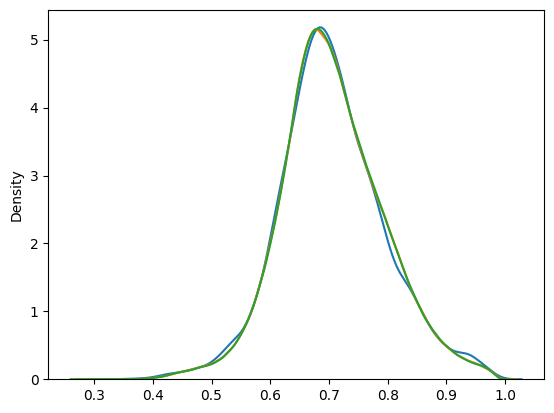

In [74]:
# commparison of different randoms ! 
sns.kdeplot(vl_s_unr)
sns.kdeplot(vl_s_all_2[-1])
sns.kdeplot(vl_s_all_1[-1])

In [75]:
# t-SNE
from sklearn.manifold import TSNE

# Lets color by disease families
_d_masks = list()
for i in adata_train.obs["do_id"].unique():
    _d_masks.append((i, np.array((adata_train.obs["do_id"] == i) & (adata_train.obs["is_control"] == "D"))))

# let's run t-SN
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(embeddings_train)

# scatter plot 
plt.figure(figsize=(5, 5), dpi=300)
for i in range(len(_d_masks)):
    _doid, _d_mask = _d_masks[i]
    plt.scatter(
        X_embedded[_d_mask][:, 0], X_embedded[_d_mask][:, 1], label=doid_to_term.get(_doid), alpha=0.9, s=5
    )
plt.title("t-SNE of Disease and Control Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Disease Families")

KeyError: 'is_control'

In [ ]:

def plot_kde_for_shortest_path_relatedness(
    c_matrix, adata_obs, df_query, s_p, colors=None
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import itertools

    if isinstance(s_p, int):
        s_p = [s_p]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "#2778ff", "#d6f3ff"]  # default palette

    unrelated_keys = set(tuple(sorted(p)) for p in df_query["pair_sorted"])
    print(len(unrelated_keys), "unrelated disease pairs")
    do_ids = adata_obs["do_id"].values

    plt.figure(figsize=(4, 4), dpi=300)

    for i, sp_val in enumerate(s_p):
        _df_query = df_query.query(f"shortest_path_length == {sp_val}")
        print(f"[SP {sp_val}] Nº of related disease pairs: {len(_df_query)}")

        _c_related = []
        _w_related = []

        for _, row in _df_query.iterrows():
            do1, do2 = row["do1"], row["do2"]
            idx1 = np.where(do_ids == do1)[0]
            idx2 = np.where(do_ids == do2)[0]
            if len(idx1) == 0 or len(idx2) == 0:
                continue
            idx_pairs = np.array(list(itertools.product(idx1, idx2)))
            _c_related.extend(c_matrix[idx_pairs[:, 0], idx_pairs[:, 1]])
            _w_related.extend([len(idx_pairs)] * len(idx_pairs))

        _c_related = np.array(_c_related)
        _w_related = np.array(_w_related) / len(_c_related)

        sns.kdeplot(
            x=_c_related,
            weights=_w_related,
            label=f"{sp_val} (n={len(_c_related)})",
            fill=True,
            color=colors[i % len(colors)],
            zorder=3,
            linewidth=3,
        )

    # Add shared random baseline
    n_needed = len(_c_related) // 10
    print("n_needed", n_needed)
    print("len(c_relate)", len(_c_related))

    rand_pairs = set()
    while len(rand_pairs) < n_needed:
        a, b = np.random.choice(len(do_ids), 2, replace=False)
        do1, do2 = do_ids[a], do_ids[b]
        if do1 == do2:
            continue
        if tuple(sorted([do1, do2])) in unrelated_keys:
            continue
        rand_pairs.add((a, b))

    rand_pairs = np.array(list(rand_pairs))
    print(len(rand_pairs))
    _c_rand = c_matrix[rand_pairs[:, 0], rand_pairs[:, 1]]
    sns.kdeplot(_c_rand, label="Unrelated", fill=True, color="gray", linewidth=3,  zorder=2)

    plt.title("Cosine Similarity: Related Diseases")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Density")

    # plot legend title
    plt.legend(title="DO disease distance")

    plt.tight_layout()
    plt.xlim(0, 1)
    plt.grid(zorder=-3, linestyle="--")
    plt.show()

def plot_roc_for_shortest_path_relatedness(
    c_matrix, adata_obs, df_query, s_p, colors=None, weights_bool=True
):
    import matplotlib.pyplot as plt
    import numpy as np
    import itertools

    if isinstance(s_p, int):
        s_p = [s_p]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "grey","#2778ff", ]

    unrelated_keys = set(tuple(sorted(p)) for p in df_query["pair_sorted"])
    do_ids = adata_obs["do_id"].values

    plt.figure(figsize=(4, 4), dpi=300)

    for i, sp_val in enumerate(s_p):
        _df_query = df_query.query(f"shortest_path_length == {sp_val}")
        _c_related = []
        _w_related = []

        for _, row in _df_query.iterrows():
            do1, do2 = row["do1"], row["do2"]
            idx1 = np.where(do_ids == do1)[0]
            idx2 = np.where(do_ids == do2)[0]
            if len(idx1) == 0 or len(idx2) == 0:
                continue
            idx_pairs = np.array(list(itertools.product(idx1, idx2)))
            _c_related.extend(c_matrix[idx_pairs[:, 0], idx_pairs[:, 1]])
            _w_related.extend([len(idx_pairs)] * len(idx_pairs))

        _c_related = np.array(_c_related)
        _w_related = np.array(_w_related)

        # Negative sampling
        rand_pairs = set()
        while len(rand_pairs) < len(_c_related):
            a, b = np.random.choice(len(do_ids), 2, replace=False)
            do1, do2 = do_ids[a], do_ids[b]
            if do1 == do2:
                continue
            if tuple(sorted([do1, do2])) in unrelated_keys:
                continue
            rand_pairs.add((a, b))
        rand_pairs = np.array(list(rand_pairs))
        _c_rand = c_matrix[rand_pairs[:, 0], rand_pairs[:, 1]]
        _w_rand = np.ones(len(_c_rand))

        # ROC computation
        y_true = np.concatenate([np.ones(len(_c_related)), np.zeros(len(_c_rand))])
        scores = np.concatenate([_c_related, _c_rand])
        weights = np.concatenate([_w_related, _w_rand])

        if weights_bool:
            fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=weights)
        else:
            fpr, tpr, _ = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{sp_val} (AUROC = {roc_auc:.2f})",
            color=colors[i],
            linewidth=3,
        )

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC")
    plt.legend()
    plt.tight_layout()
    plt.grid(linestyle="--", zorder=-1)
    plt.show()



In [ ]:
[x for x in adata_train.obs["disease"].to_list() if x.lower().startswith("re")][:10]

['Renal Cell Carcinoma',
 'Renal Cell Carcinoma',
 'Renal Cell Carcinoma',
 'Renal Cell Carcinoma',
 'Renal Cell Carcinoma',
 'Renal Cell Carcinoma',
 'Renal Cell Carcinoma',
 'Renal Cell Carcinoma',
 'Renal Cell Carcinoma',
 'Renal Cell Carcinoma']

In [ ]:
adata_train[adata_train.obs["doid_id"] == "DOID:1273"]

View of AnnData object with n_obs × n_vars = 0 × 3494 backed at '../../outputs/run-25-09-17-01/adata_train_1.h5ad'
    obs: 'ids', 'dataset', 'dataset_id', 'batch', 'batch_id', 'dsaid', 'tissue', 'n_genes', 'disease', 'celltype', 'disease_study', 'library', 'doid_study', 'doid_id', 'do_id', 'doid_disease', 'celltype_id', 'sample_id', 'test_split_1'
    var: 'gene_symbols', 'gene_name', 'index', 'id_in_vocab'
    uns: 'log1p'
    obsm: 'bin_edges'
    layers: 'X_binned', 'X_log1p', 'X_normed'

In [ ]:
df_info = ut.load_dsa_info()

In [ ]:
df_info.query("diseaseid == 'C0035235'")

,dsaid,accession,platform,deg_count,disease,diseaseid,tissue,data_source,library_strategy,organism,control_case_sample_count,definition
2207,DSA02208,GSE77087,GPL10558,1000,Respiratory Syncytial Virus Infectious Disease,C0035235,Blood,GEO,Microarray,Homo sapiens,23|61,DO:A viral infectious disease that results_in ...
2208,DSA02209,GSE77087,GPL10558,1000,Respiratory Syncytial Virus Infectious Disease,C0035235,Blood,GEO,Microarray,Homo sapiens,23|20,DO:A viral infectious disease that results_in ...


## Garbage

In [ ]:
ids = [x.split(".")[1] for x in adata_orig.obs["ids"].values]

In [ ]:
# get all duplicate IDs
from collections import Counter
id_counts = Counter(ids)
duplicate_ids = {id_ for id_, count in id_counts.items() if count > 1}

In [ ]:
adata_orig.obs["ids"] = ids

In [ ]:
df_query = adata_orig.obs.query("ids in @duplicate_ids")

In [ ]:
adata_orig.obs.query("ids == 'ERR6212495'")

,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,doid_study,doid_id,do_id,doid_disease,celltype_id,test_split_1
8114,ERR6212495,E-MTAB-10703,E-MTAB-10703,619,619,DSA01733,Blood plasma,19402,Acquired Immunodeficiency Syndrome,DOID:635,Acquired Immunodeficiency Syndrome,RNA-Seq,D,DOID:635,DOID:635,acquired immunodeficiency syndrome,6,1
8174,ERR6212495,E-MTAB-10703,E-MTAB-10703,619,619,DSA01736,Blood plasma,19402,Hepatitis C,DOID:1883,Hepatitis C,RNA-Seq,D,DOID:1883,DOID:1883,hepatitis C,21,1


In [ ]:
adata_orig.obs.query("ids == 'GSM4586124'")

,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,doid_study,doid_id,do_id,doid_disease,celltype_id,test_split_1
24453,GSM4586124,GSE151580,GSE151580,202,202,DSA07726,Pancreas,18250,Pancreatic Ductal Adenocarcinoma,DOID:3498,Pancreatic Ductal Adenocarcinoma,RNA-Seq,D,DOID:3498,DOID:3498,pancreatic ductal adenocarcinoma,46,0
24486,GSM4586124,GSE151580,GSE151580,202,202,DSA07728,Pancreas,18250,Control,Control,Metastatic Pancreatic Ductal Adenocarcinoma,RNA-Seq,D,Control,Control,Control,0,0


In [ ]:
adata_orig.obs.query("ids == 'GSM2668072'")


,ids,dataset,dataset_id,batch,batch_id,dsaid,tissue,n_genes,disease,celltype,disease_study,library,doid_study,doid_id,do_id,doid_disease,celltype_id,test_split_1
464,GSM2668072,GSE100026,GSE100026,261,261,DSA00219,Peripheral blood,19402,Chronic Myeloid Leukemia,DOID:8552,Chronic Myeloid Leukemia,RNA-Seq,D,DOID:8552,DOID:8552,chronic myeloid leukemia,80,0
479,GSM2668072,GSE100026,GSE100026,261,261,DSA00221,Peripheral blood,19402,Control,Control,Progressive Chronic Myeloid Leukemia,RNA-Seq,D,Control,Control,Control,0,0


In [ ]:
df_query.groupby("ids")["disease"].nunique().sort_values(ascending=False).head(200)

ids
TCGA-D6-A74Q-01A    2
TCGA-D6-A6ES-01A    2
TCGA-D6-A6EQ-01A    2
TCGA-D6-A6EP-01A    2
TCGA-D6-A6EO-01A    2
                   ..
TCGA-CN-4733-01A    2
GSM4586124          2
TCGA-CR-7402-01A    2
TCGA-CR-7401-01A    2
TCGA-CR-7399-01A    2
Name: disease, Length: 200, dtype: int64

In [ ]:
def get_doid_idxs_pairs(pairs:List[Tuple], do_ids:List, datasets:List=None, return_weights:bool = False)-> Tuple[List[Tuple[int, int]], List[int]]:

    universe_pairs = list()
    l_weights = list()  # label weights
    for doid_a, doid_b in tqdm(pairs):
        
        # retrieve disease idxs pairs
        idx1 = np.where(do_ids == doid_a)[0]
        idx2 = np.where(do_ids == doid_b)[0]

        # compute idx combinations
        idx_pairs = list(itertools.product(idx1, idx2))

        # if ONLY take into account diseases DIFFERENT datasets
        if datasets is not None:
            # filter by datasets
            idx_pairs = [p for p in idx_pairs if datasets[p[0]] != datasets[p[1]]]

        universe_pairs.extend(idx_pairs)

        if return_weights:
            l_weights.extend([f"{doid_a} - {doid_b}"] * len(idx_pairs)) # joint label

    universe_pairs = np.array(universe_pairs).reshape(-1, 2)
    if return_weights:
        return universe_pairs, l_weights
    else:
        return universe_pairs

def _convert_labels_to_weights(labels: List[str]) -> List[float]:
    """Convert labels to weights"""
    counts = Counter(labels)
    w = np.array([1.0 / counts[d] for d in labels], dtype=float)
    w /= w.sum()                               # normalize to sum to 1
    return w

def get_unrelated_pairs(
    adata_obs: pd.DataFrame,
    df_related: pd.DataFrame,
    s_matrix: np.ndarray,
    n_samples: int = 1000,
    seed: int = 42,
) -> List[Tuple[int, int]]:
    """Get unrelated pairs of samples"""

    np.random.seed(seed)

    adata_obs = adata_obs.copy()
    adata_obs.reset_index(drop=True, inplace=True)
    adata_obs["is_control"] = ["C" if i.startswith("Control") else "D" for i in adata_obs["doid_id"]]

    # Precompute DOID-to-sample indices
    doid_to_indices = dict()
    for idx, doid in adata_obs["doid_id"].items():
        if doid not in doid_to_indices:
            doid_to_indices[doid] = []
        doid_to_indices[doid].append(idx)

    # Build unrelated pairs
    unrelated_pairs = []
    pair_key_set = set(tuple(sorted(p)) for p in df_related["pair_sorted"])
    doids = list(doid_to_indices.keys())
    print(len(doids), "diseases in dataset")
    for d1, d2 in tqdm(itertools.combinations(doids, 2)):

        # skip related diseases
        if d1 == d2 or tuple(sorted([d1, d2])) in pair_key_set:
            continue    
        
        #! WARNING - THIS WOULD ALSO INCLUDE CONTROLS
        # idxs1 = adata_obs.query("doid_id == @d1").index
        # idxs2 = adata_obs.query("doid_id == @d2").index
        idxs1 = adata_obs.query("doid_id == @d1").index
        idxs2 = adata_obs.query("doid_id == @d2").index

        unrelated_pairs.extend(itertools.product(idxs1, idxs2))


    # Sample unrelated pairs
    print(len(unrelated_pairs), "unrelated pairs found")
    k = min(n_samples, len(unrelated_pairs))
    print(k)
    selected_idxs = np.random.choice(len(unrelated_pairs), size=k, replace=False)
    print("Selected", len(selected_idxs), "unrelated pairs")
    _rand_sample_pairs = [unrelated_pairs[i] for i in selected_idxs]
    print("Sampled pairs:", len(_rand_sample_pairs))
    c_rand = [s_matrix[i, j] for i, j in _rand_sample_pairs]
    
    
    return c_rand


In [ ]:
def plot_roc_for_shortest_path_relatedness(
    c_matrix, do_ids, df_related, df_unrelated,  labels, colors=None, use_weights=True, sample:int=None
):
    if isinstance(labels, int):
        labels = [labels]
    if colors is None:
        colors = ["#ff9e9d", "#fb731d", "#fcbb01", "grey","#2778ff", ]


    # get pairs    
    unrelated_pairs = list(df_unrelated["pair_sorted"].unique())
    unrelated_universe = get_doid_idxs_pairs(unrelated_pairs, do_ids, return_weights=False)
    print(f"Nº of unrelated disease pairs: {len(unrelated_universe)}")
    plt.figure(figsize=(4, 4), dpi=300)

    for i, label_i in enumerate(labels):

        # get all related pairs for given label / shortest_path
        _df_query = df_related.query(f"shortest_path_length == {label_i}")

        # get related pairs
        related_idxs, _w_related = get_doid_idxs_pairs(list(_df_query["pair_sorted"]), do_ids, return_weights=True)
        print(f"Nº of related disease pairs for {label_i}: {len(related_idxs)}")

        if sample:
            _sample_i = random.sample(range(len(related_idxs)), sample)
            related_idxs = related_idxs[_sample_i]
            _w_related = _w_related[_sample_i]

        _c_related = c_matrix[related_idxs[:, 0], related_idxs[:, 1]]

        # get sample of unrelated pairs
        _sample_i = random.sample(range(len(unrelated_universe)), len(_c_related))
        _unrelated_sample = unrelated_universe[_sample_i]

        # get similarities between unrelated pairs
        _s_unrelated = c_matrix[_unrelated_sample[:, 0], _unrelated_sample[:, 1]]
        _w_unrelated = np.ones(len(_s_unrelated))   # do not weight - they are random - no groupings

        # ROC computation
        y_true = np.concatenate([np.ones(len(_c_related)), np.zeros(len(_s_unrelated))])
        scores = np.concatenate([_c_related, _s_unrelated])
        weights = np.concatenate([_w_related, _w_unrelated])

        if use_weights:
            fpr, tpr, _ = roc_curve(y_true, scores, sample_weight=weights)
        else:
            fpr, tpr, _ = roc_curve(y_true, scores)
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{label_i} (AUROC = {roc_auc:.2f})",
            color=colors[i],
            linewidth=3,
        )

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("AUROC")
    plt.legend()
    plt.tight_layout()
    plt.grid(linestyle="--", zorder=-1)
    plt.show()


In [ ]:
# print(embeddings_test.shape, embeddings_train.shape)
# _cosine_sim = c_matrix_test_vs_train = 1 - cdist(embeddings_test, embeddings_train, "cosine")

# i = 0
# _all_sims = list()
# for do_id in adata_test.obs["doid_id"].unique():
#     if do_id == "Control": # skip
#         continue
#     idxs1 = adata_test.obs.query("doid_id == @do_id").index
#     idxs2 = adata_train.obs.query("doid_id == @do_id").index

#     idxs_pairs =np.array(list(itertools.product(idxs1, idxs2)))
#     if len(idxs_pairs) > 0:

#         _sim = _cosine_sim[idxs_pairs[:,0], idxs_pairs[:,1]]
#         print(do_id, len(idxs_pairs), np.mean(_sim), np.std(_sim))
#         sns.kdeplot(_sim, label=do_id)

#         _all_sims.extend(_sim)
#     # if i == 20:
#     #     # break
#     # # i += 1

# sns.kdeplot(_all_sims, label="All", color="black", linestyle="--")
# plt.grid(linestyle="--", zorder=-1)